In [21]:
import uproot
import pandas as pd
import numpy as np
import awkward as ak
import os
import json
import ROOT

In [22]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.lines as lines
from matplotlib.collections import PatchCollection
plt.rcParams.update({'font.size': 15})

In [3]:
os.environ['ttH_yy_DIR'] = '/eos/user/e/elmazzeo/ttH@FCC-hh/results/2025-03-10'

In [9]:
basedir = os.path.join(os.environ.get('ttH_yy_DIR'), 'final')
outdir = os.path.join(os.environ.get('ttH_yy_DIR'), 'plots')
color_sequence = ["#3f90da","#ffa90e","#bd1f01","#94a4a2","#832db6","#a96b59","#e76300","#b9ac70","#717581","#92dadd"]
process = {
#    'HHbbyy' : { 'sample_list' : ['pwp8_pp_hh_lambda100_5f_hhbbaa'], 
#               'label' : r'$HH \rightarrow bb\gamma\gamma$',
#               'color' : color_sequence[1]},
    'ttHyy' : { 'sample_list' : ['mgp8_pp_tth01j_5f_84TeV_haaexcl'], 
               'label' : r'$ttH \rightarrow \gamma\gamma$',
               'color' : color_sequence[0]}
}


selection = {
    'nocuts' : "All events"
}

process_infos = ["/eos/experiment/fcc/hh/utils/FCCDicts/FCChh_procDict_fcc_v07_II.json",
                 "/eos/experiment/fcc/hh/utils/FCCDicts/FCChh_procDict_fcc_v06_II.json"]

lumi = 3e7 # 3 * 10^7 pb-1 = 3 ab-1

In [10]:
def error_boxes (ax,x,y,x_err,y_err,fc='lightgrey',ec='None',alpha=0.5, hatch=None):

    # Create list for all the error patches
    errorboxes = []

    # Loop over data points; create box from errors at each point
    for xc,yc,xe,ye in zip(x,y,x_err.T,y_err.T):
        rect = patches.Rectangle((xc-xe,yc-ye),2*xe,2*ye)
        errorboxes.append(rect)

    # Create patch collection with specified colour/alpha
    pc = PatchCollection(errorboxes,facecolor=fc,alpha=alpha,edgecolor=ec, hatch=hatch)

    # Add collection to axes
    ax.add_collection(pc)

In [11]:
process_dicts = []
for inputname in process_infos :
    with open(inputname, 'r') as f :
        process_dicts.append(json.load(f))

In [12]:
from importlib import import_module
import sys
sys.path.insert(1, "../")

In [13]:
selection = {
    "nocuts" : "All events",
#    "lep_channel" : "Photon and $b$-jet sel., $\geq$ 1 lepton",
#    "pT_yy_bin1" : "0$\leq p_{T}(\gamma\gamma)$< 60 GeV",
#    "pT_yy_bin2" : "60$\leq p_{T}(\gamma\gamma)$< 120 GeV",
#    "pT_yy_bin3" : "120$\leq p_{T}(\gamma\gamma)$< 200 GeV",
#    "pT_yy_bin4" : "200$\leq p_{T}(\gamma\gamma)$< 300 GeV",
#    "pT_yy_bin5" : "$p_{T}(\gamma\gamma)\geq$ 300 GeV",
}
analysis_final = import_module("analysis_final")
variables_dict = analysis_final.histoList
variables_list = [#'E_y1', 'pT_y1', 'eta_y1', 'true_E_y1', 'true_pT_y1', 'true_eta_y1', 
                  #'E_y2', 'pT_y2', 'eta_y2', 'true_E_y2', 'true_pT_y2', 'true_eta_y2',
                  #'has_higgs_parent_y1', 'has_higgs_parent_y2',
                 # 'DR_y_y',
                  #'pT_yy', 'm_yy', 'true_pT_yy', 
                  'theta_y_y', #'cos_theta_y_y',
                  'true_theta_y_y', #'true_cos_theta_y_y',
                  #'m_yy', 'true_m_yy', 
                  'weight', 'pT_higgs']
selection_string = '(higgs_decay_type==7)'

In [14]:
df = {}
sow = {}

In [15]:
for p in process.keys() :
    if p in list(df.keys()) :
        pass
    else :
        df[p] = {}
    print(p)
    for s in selection.keys() :
        if s in list(df[p].keys()) :
            pass
        else :
            print("\t\t"+s)
            df1 = []
            sow[p] = []
            for sample in process[p]['sample_list'] :
                inputfile = os.path.join(basedir, sample+"_"+s+".root")
                # get sum of weights
                #f = ROOT.TFile.Open(inputfile)
                #sow[p].append(f.Get("SumOfWeights").GetVal())
                #f.Close()
                # get sample dict
                for d in process_dicts :
                    if sample in list(d.keys()) :
                        process_dict = d.copy()
                        break
                # get sample
                with uproot.open(inputfile) as f :
                    df1.append(ak.to_dataframe(f['events'].arrays(expressions=variables_list, cut=selection_string, library='ak')))
                    df1[-1]["weight"] = df1[-1]["weight"]#/sow[p][-1]*process_dict[sample]['crossSection']*process_dict[sample]['kfactor']*process_dict[sample]['matchingEfficiency']
            df[p][s] = pd.concat(df1, copy=True, ignore_index=True)
            print("N events before truth-level cut", len(df[p][s]))
            df[p][s] = df[p][s].query("(has_higgs_parent_y1==1) & (has_higgs_parent_y2==1)")
            print("N events after truth-level cut", len(df[p][s]))

ttHyy
		nocuts
N events before truth-level cut 9299212


UndefinedVariableError: name 'has_higgs_parent_y1' is not defined

In [16]:
process_key = list(process.keys())[0]
process_label = process[process_key]['label']
process_color = process[process_key]['color']
sel_key = list(selection.keys())[0]
sel_label = selection[sel_key]
df1 = df[process_key][sel_key].copy()

In [17]:
df1["eta_y1"].hist(bins=120, range=(-6.,6.))

KeyError: 'eta_y1'

/tmp/elmazzeo/ipykernel_496224/2687516043.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['energy_bin'] = np.digitize(np.abs(df1['true_pT_yy']), ENERGY_BINS)


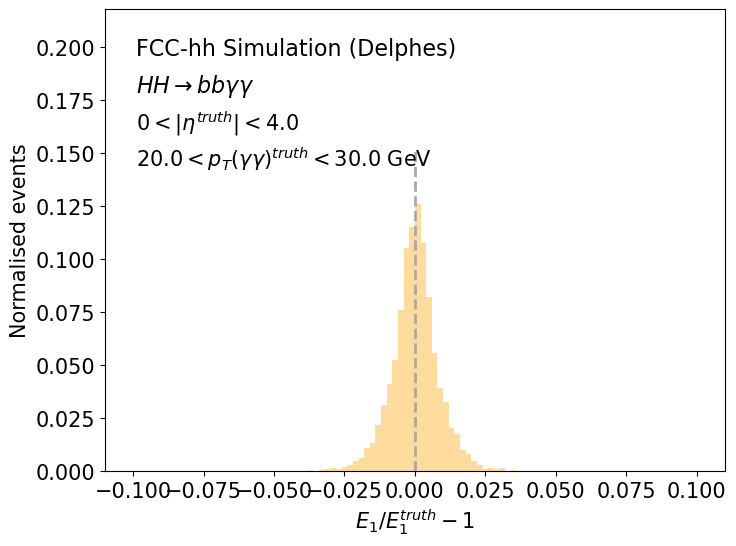

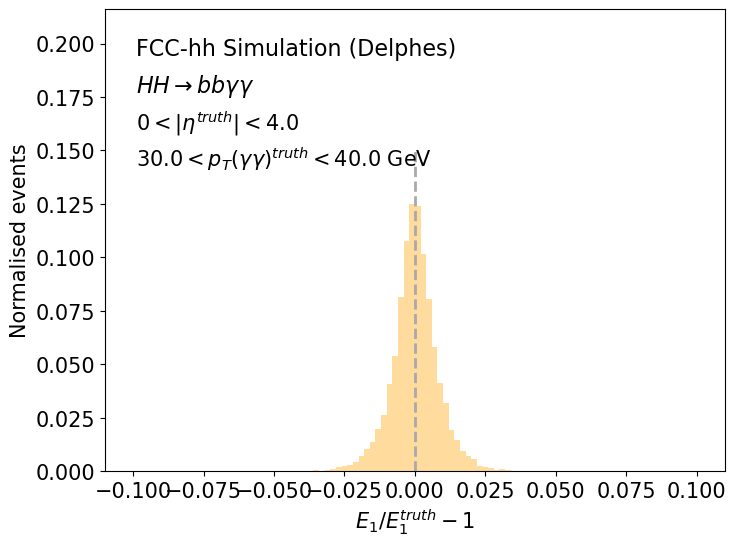

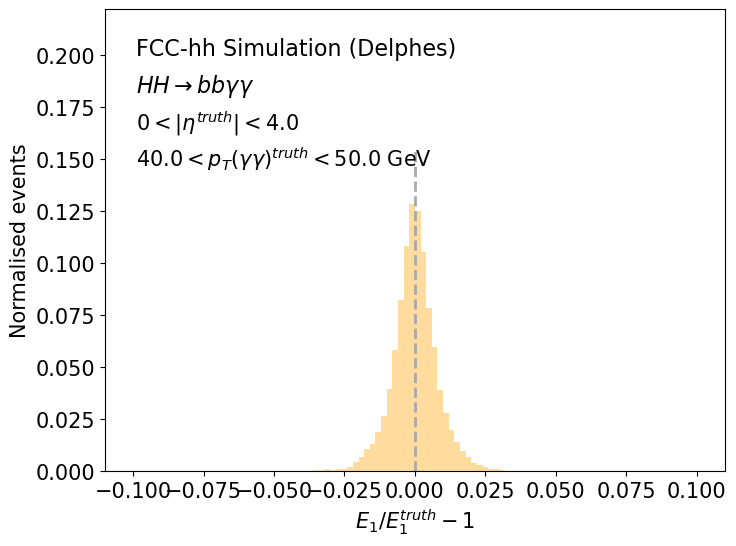

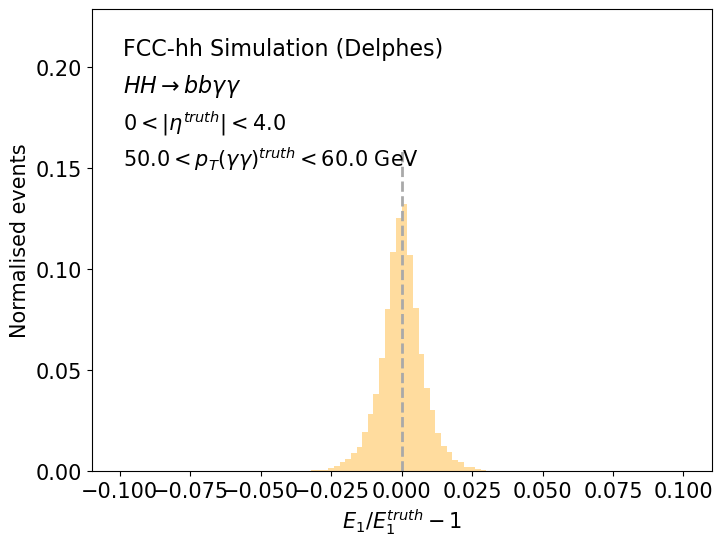

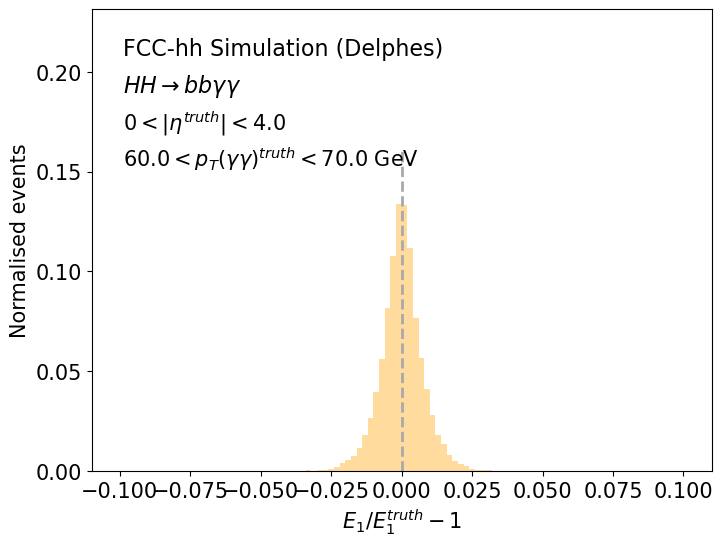

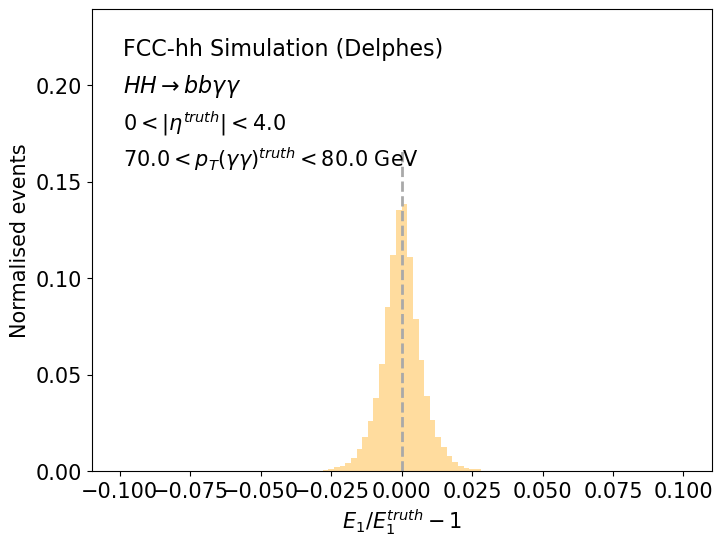

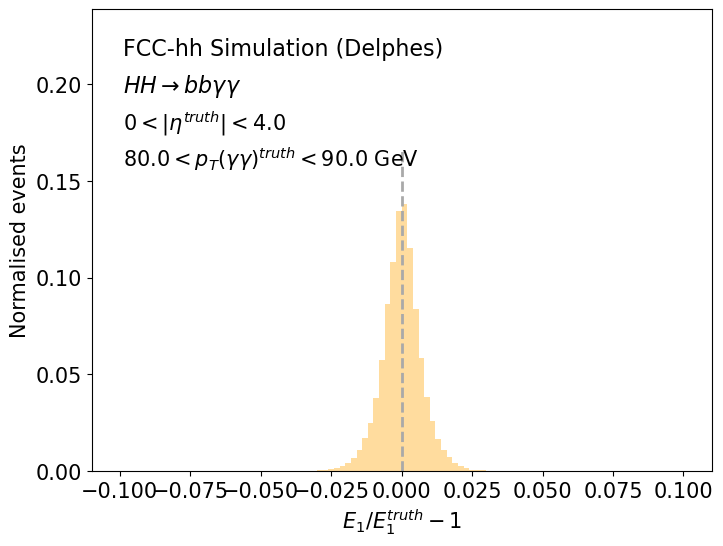

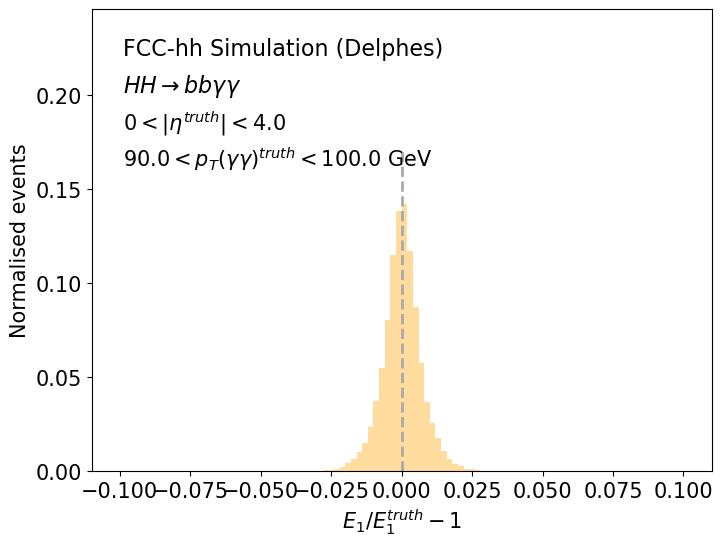

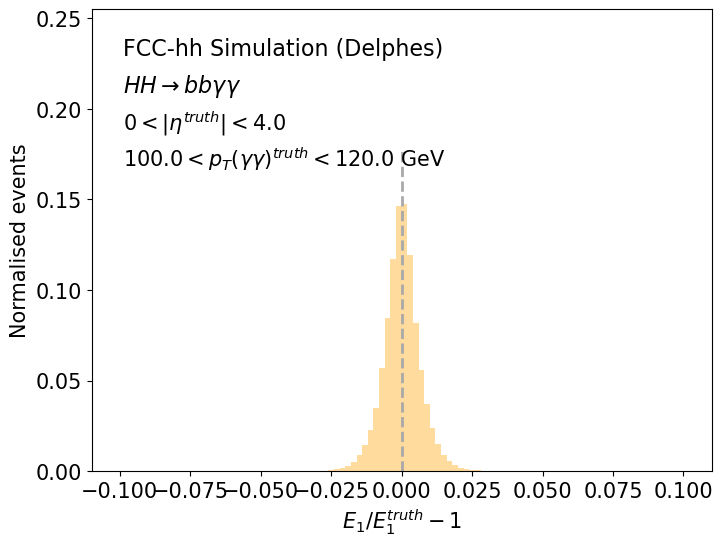

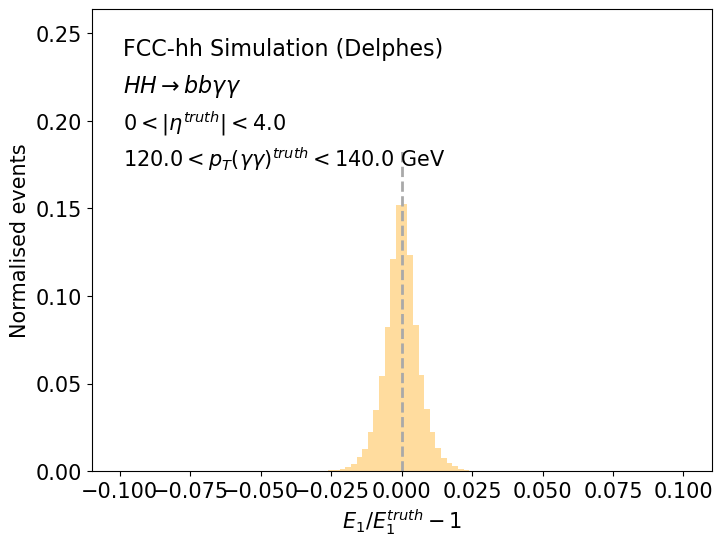

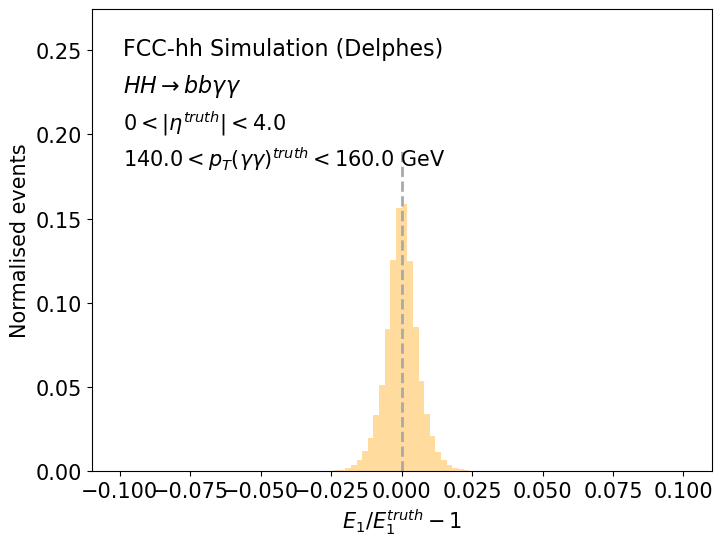

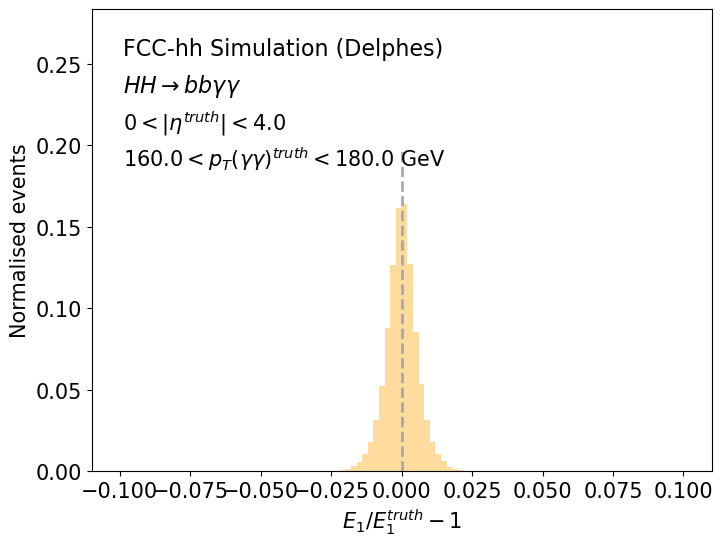

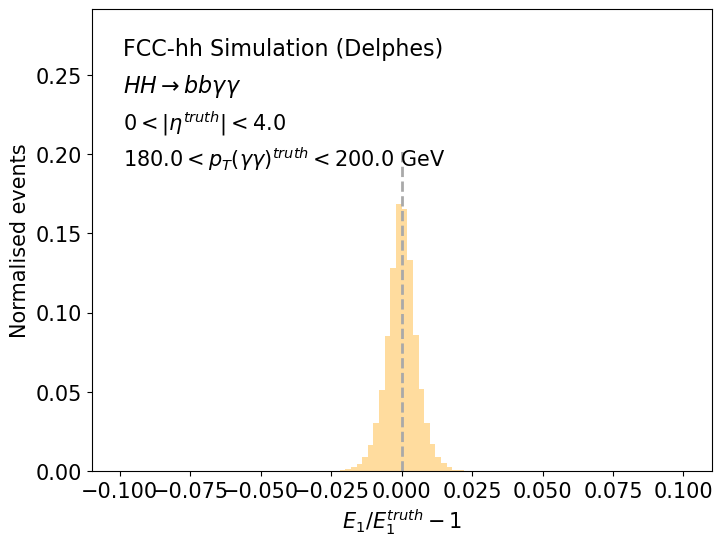

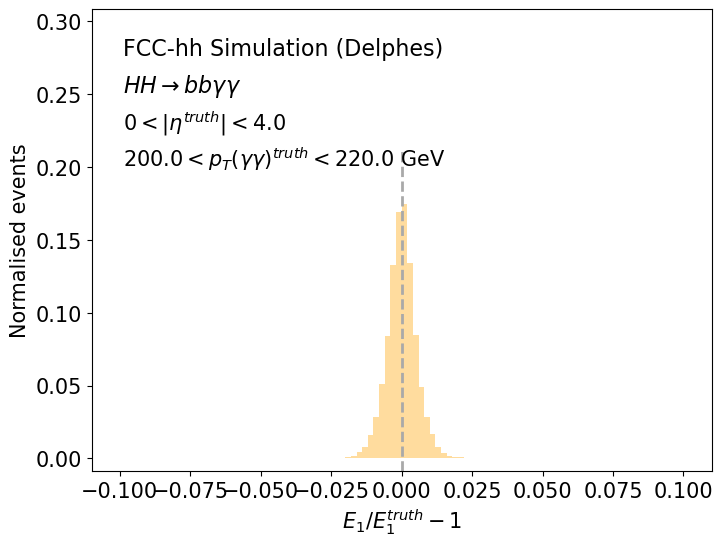

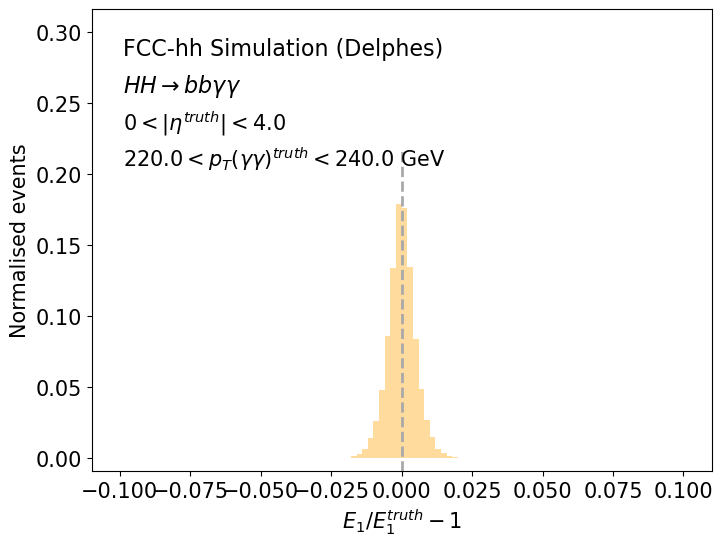

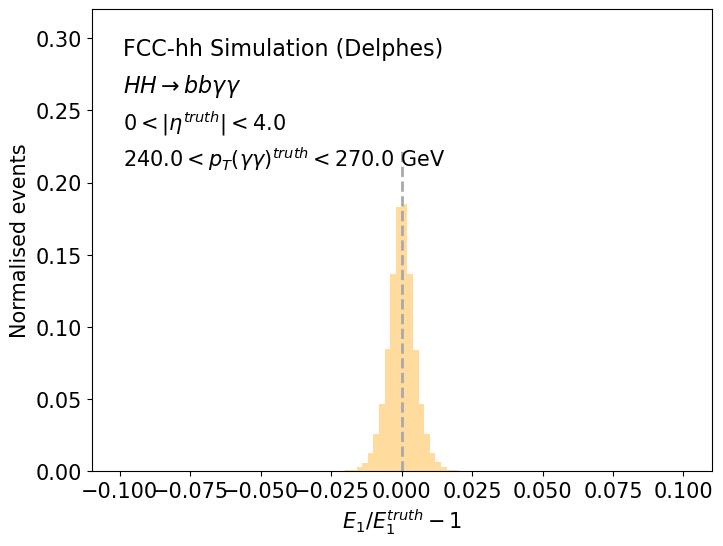

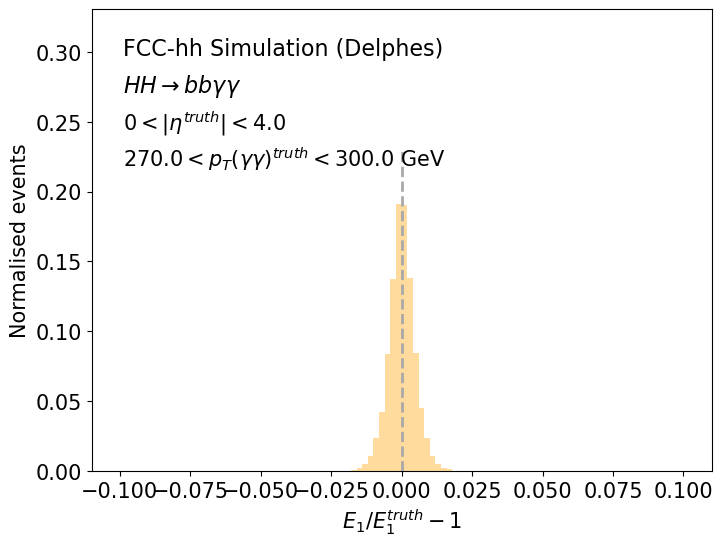

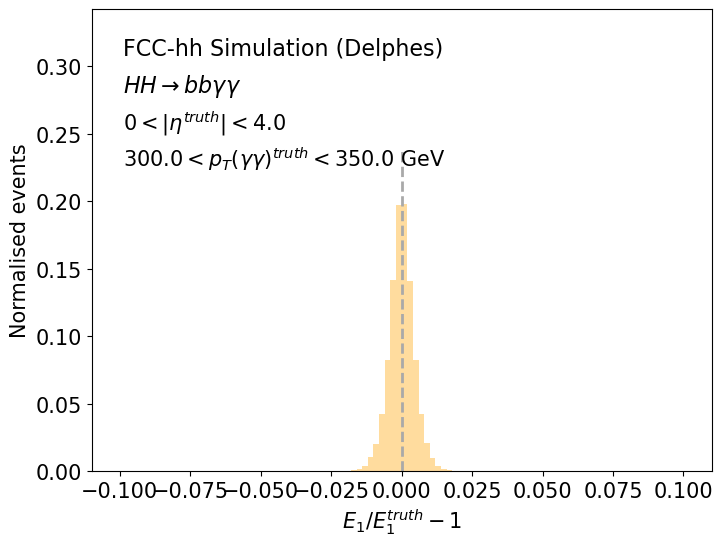

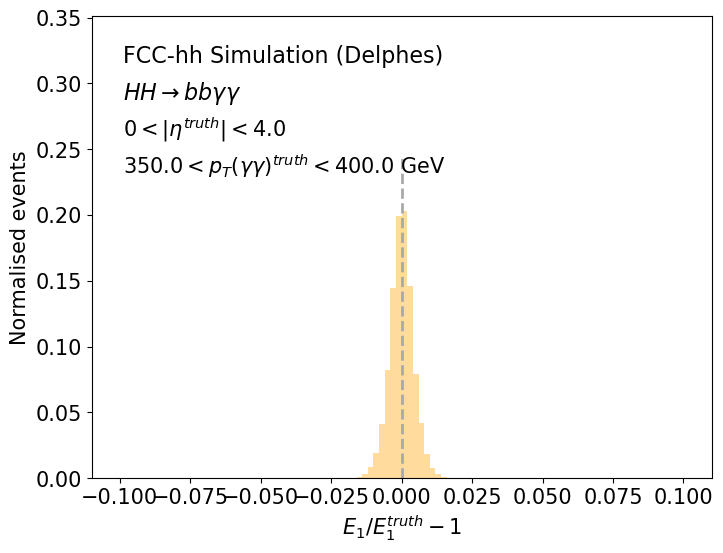

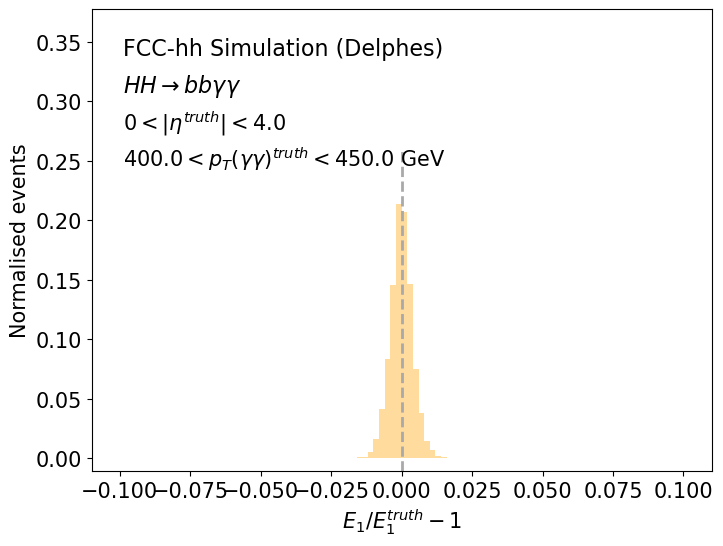

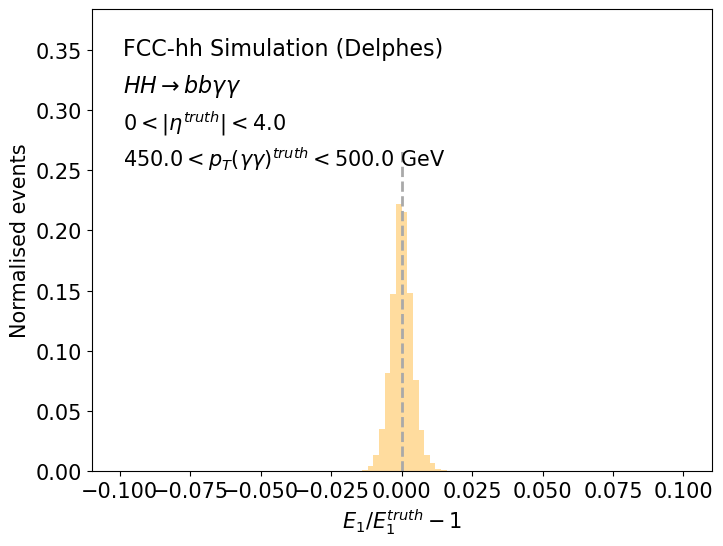

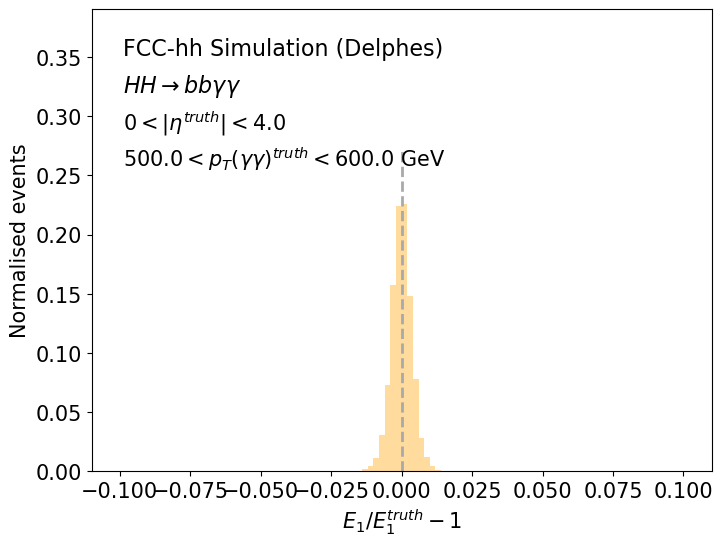

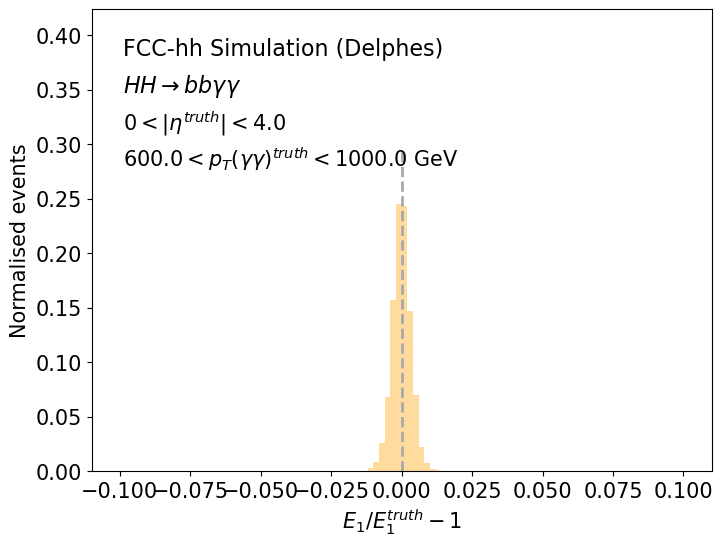

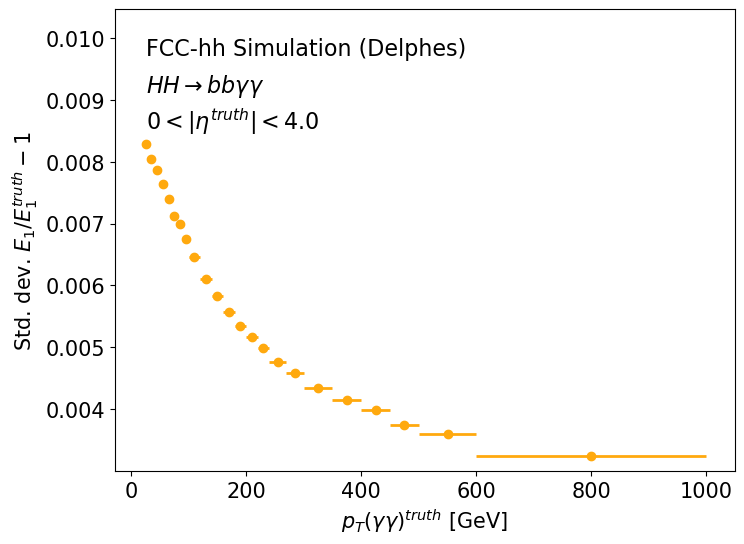

In [48]:
ENERGY_BINS = np.array([20, 30, 40, 50, 60, 70, 80, 90, 100,
                       120, 140, 160, 180, 200,
                       220, 240, 270, 300,
                       350, 400, 450, 500, 600, 1000], dtype=np.float64)
x = 0.5*(ENERGY_BINS[:-1] + ENERGY_BINS[1:])
xerr = 0.5*(ENERGY_BINS[1:] - ENERGY_BINS[:-1])

df1 = df[process_key][sel_key].query("(abs(true_eta_y1)<4.0) & (abs(true_eta_y2)<4.0)")

df1['energy_bin'] = np.digitize(np.abs(df1['true_pT_yy']), ENERGY_BINS)

y = np.zeros(len(ENERGY_BINS)-1)
for jbin in range(1, len(ENERGY_BINS)) :
    i_low = 0
    i_up = 4.0
    j_low = ENERGY_BINS[jbin-1]
    j_up = ENERGY_BINS[jbin] 
        
    df_all = df1[(df1['energy_bin']==jbin)]
    observable = df_all['E_y1']/df_all['true_E_y1']-np.ones(len(df_all))
    resolution = np.std(observable)
    y[jbin-1] = resolution
    
    # E / Etrue -1
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(8,6)
    )
    ax.hist(observable, weights=df_all['weight']/df_all['weight'].sum(),
            bins=100, range=(-0.1,0.1), histtype='stepfilled', color=process_color, alpha=0.4)
    ax.axvline(0, ymin=0, ymax=0.7, color='darkgrey', ls='--', lw=2.)

    ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.82, process_label, transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.74, str(i_low)+"$<|\eta^{truth}|<$"+str(i_up), transform=ax.transAxes, fontsize=15)
    ax.text(0.05, 0.66, str(j_low)+"$<p_T(\gamma\gamma)^{truth}<$"+str(j_up)+" GeV", transform=ax.transAxes, fontsize=15)
    xlabel = "$E_1/E_1^{truth}-1$"
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'Normalised events')

    ymin,ymax = ax.get_ylim() 
    ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.65)
    
    plotname = "e1reco_over_e1true_very_central_photons_true_pT_yy_bin"+str(jbin)
    plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
    plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
    plt.show()        

fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

ax.errorbar(x, y, xerr=xerr, color=process_color, marker='o', lw=2, ls='none')

ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, process_label, transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.74, str(i_low)+"$<|\eta^{truth}|<$"+str(i_up), transform=ax.transAxes, fontsize=16)
xlabel = "$p_T(\gamma\gamma)^{truth}$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Std. dev. $E_1/E_1^{truth}-1$')

ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.35)
    
plotname = "e1reco_over_e1true_hhbbyy_true_pT_yy_bins"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()   

/tmp/elmazzeo/ipykernel_496224/513861296.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['energy_bin'] = np.digitize(np.abs(df1['true_pT_yy']), ENERGY_BINS)
/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


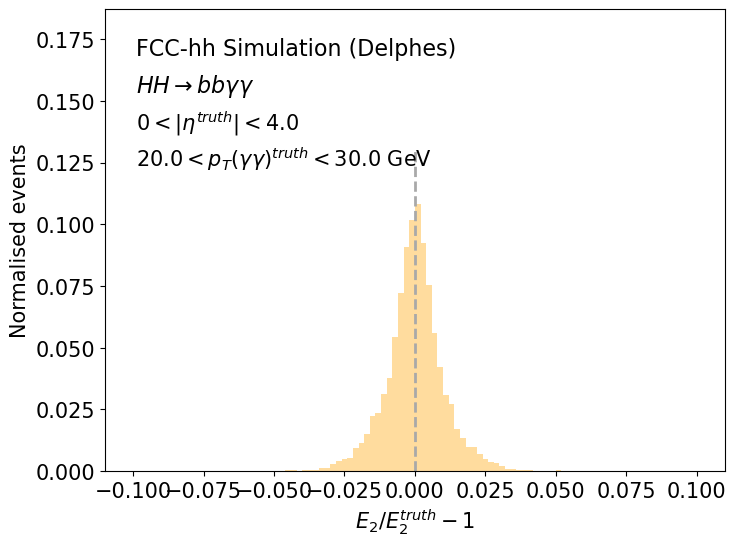

/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


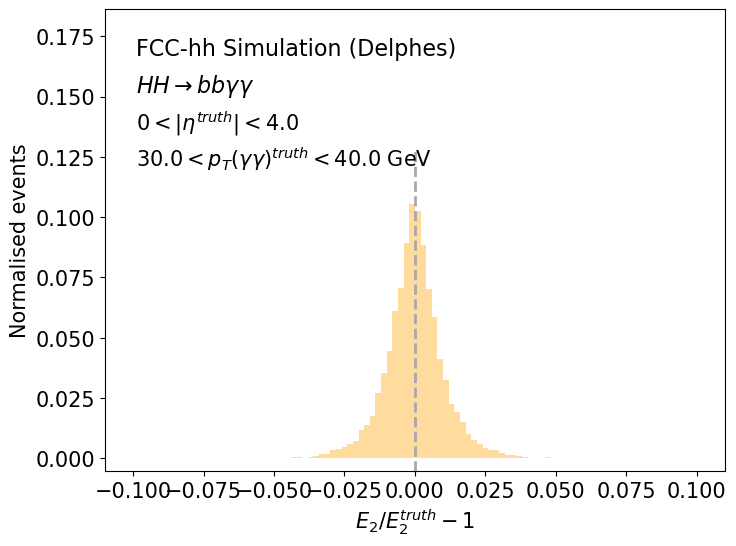

/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


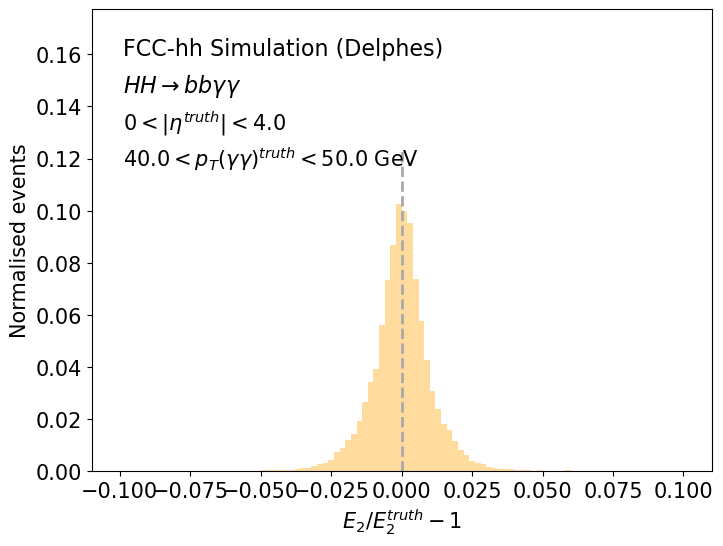

/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


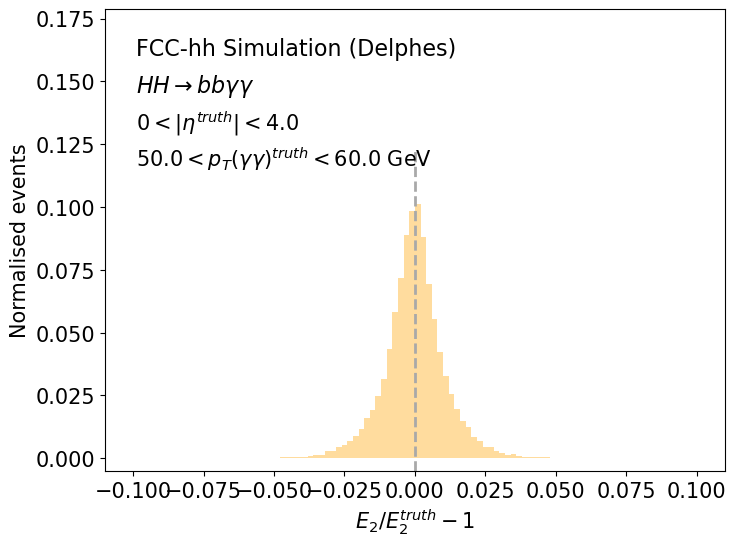

/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


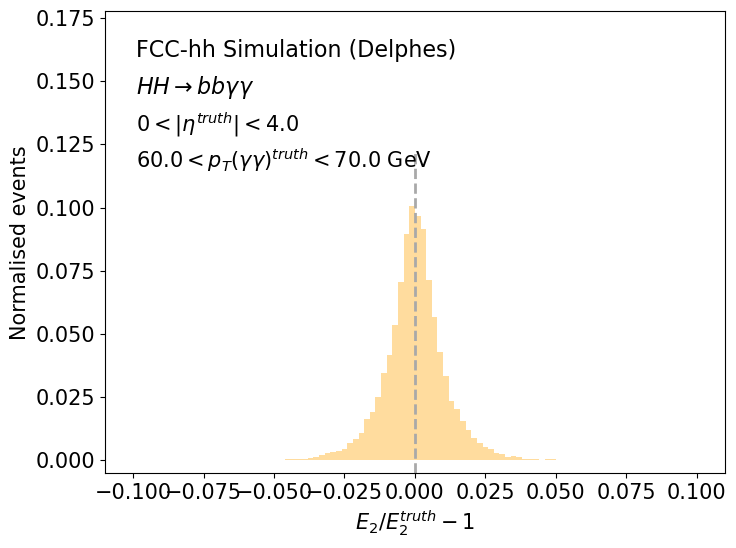

/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


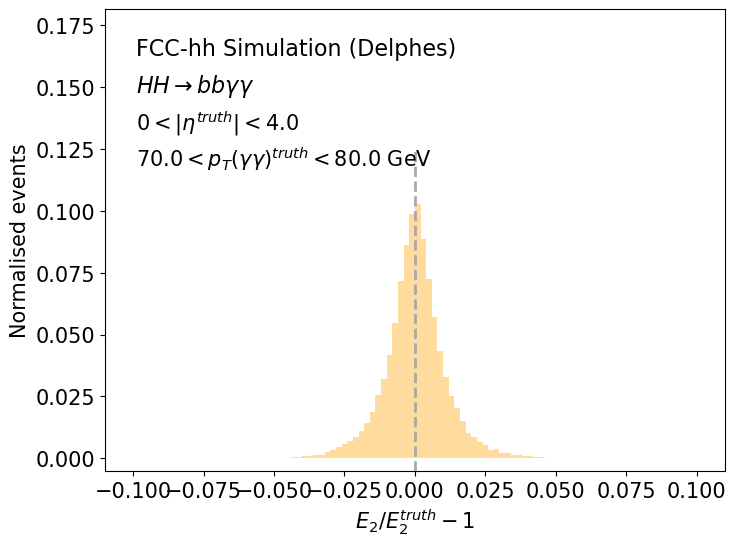

/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


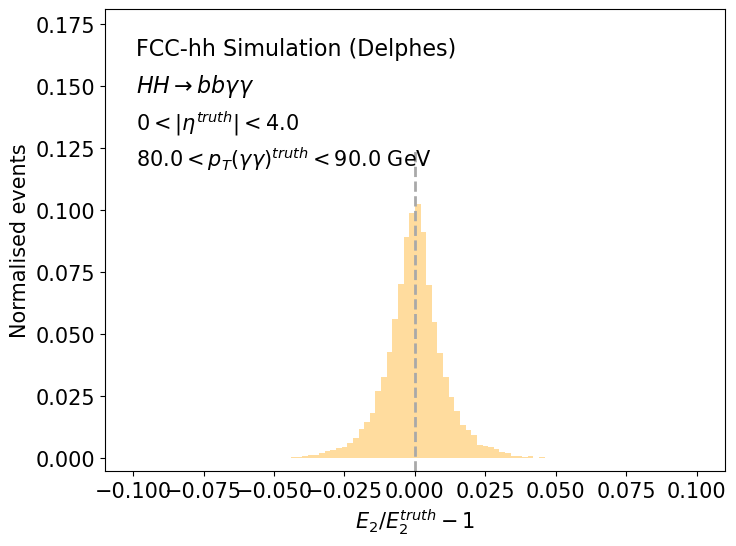

/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


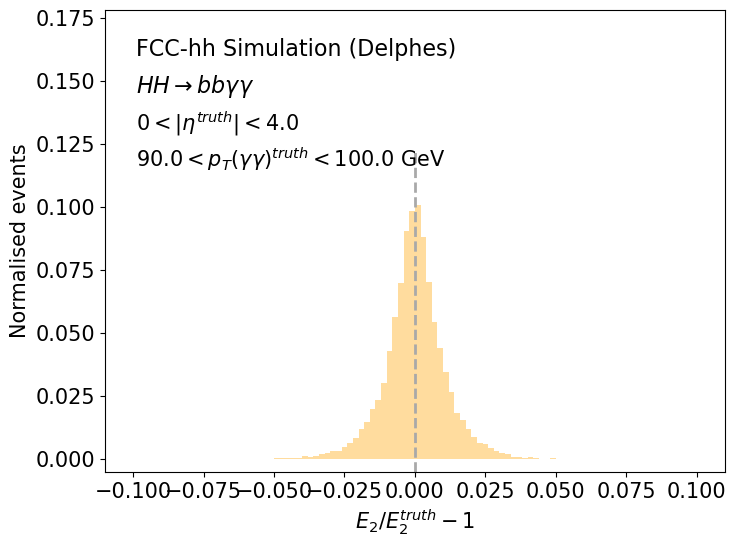

/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


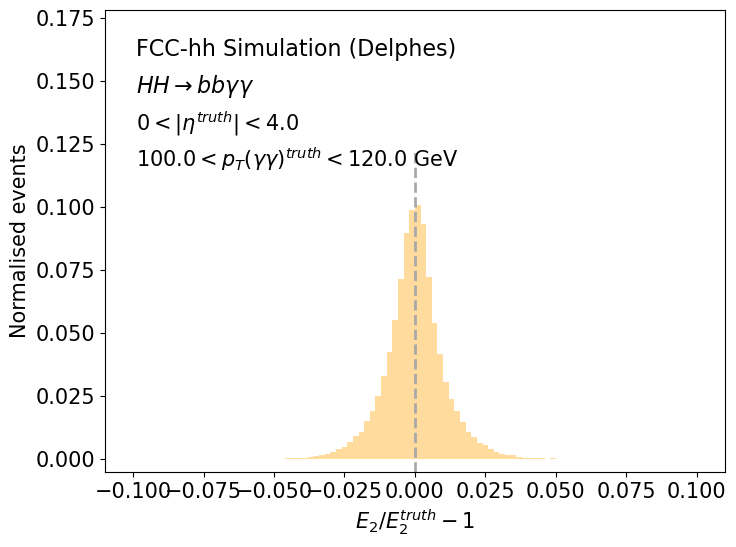

/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


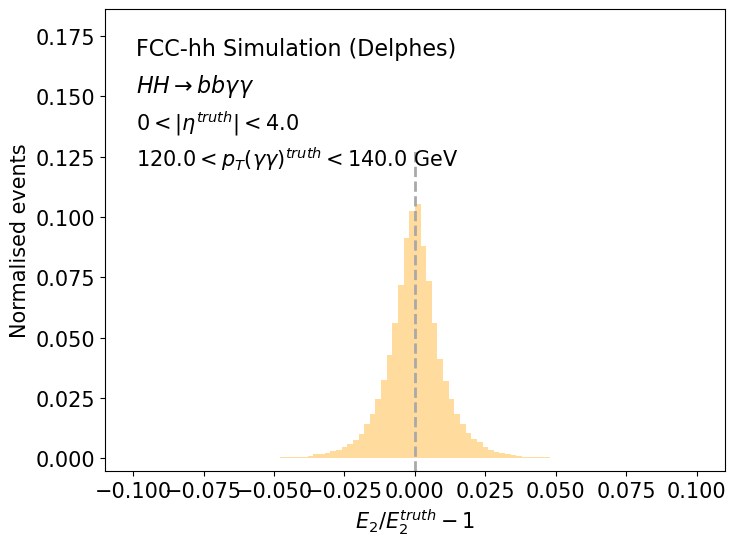

/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


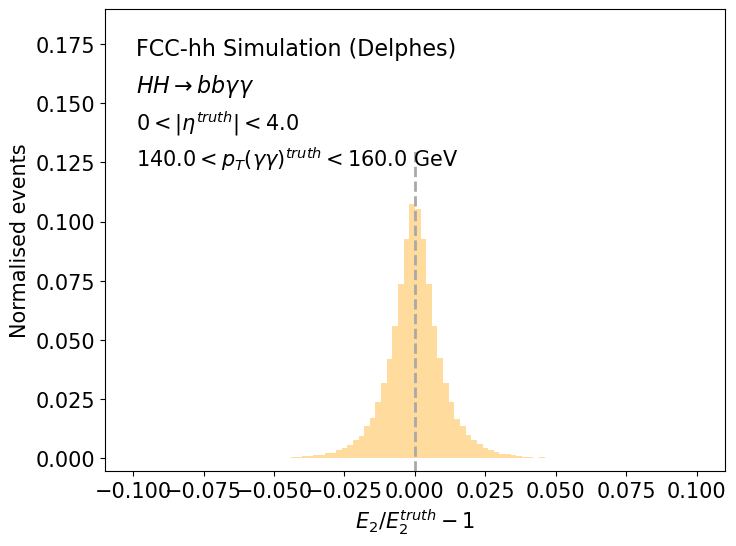

/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


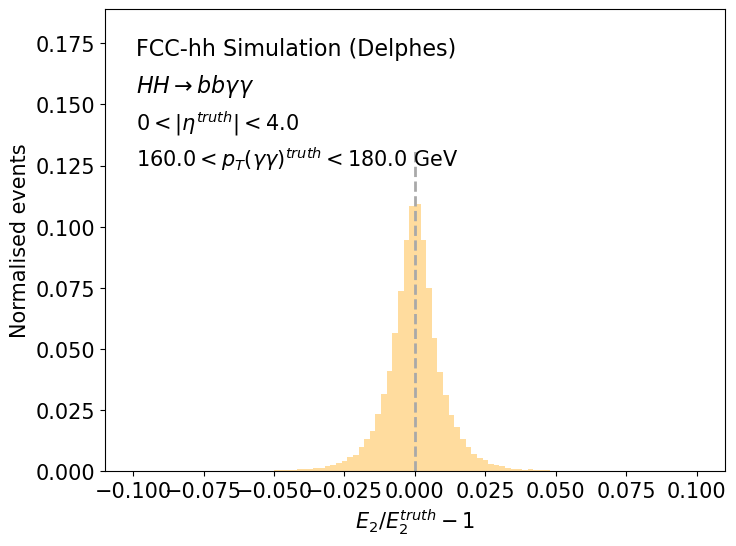

/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


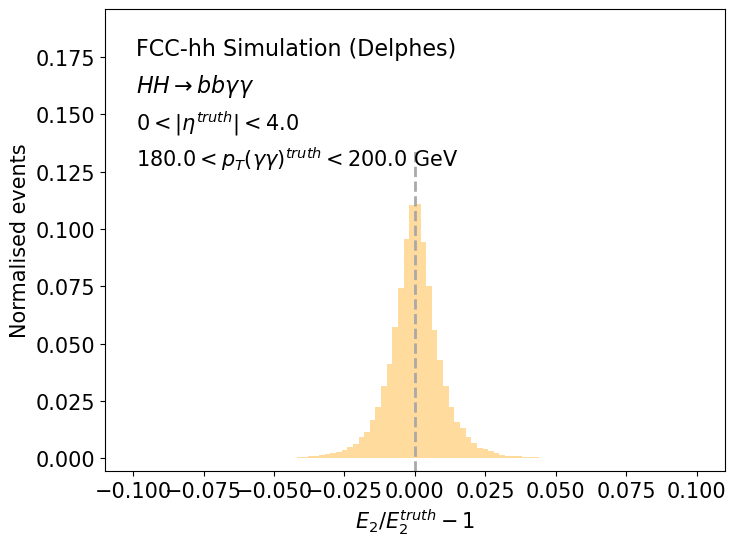

/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


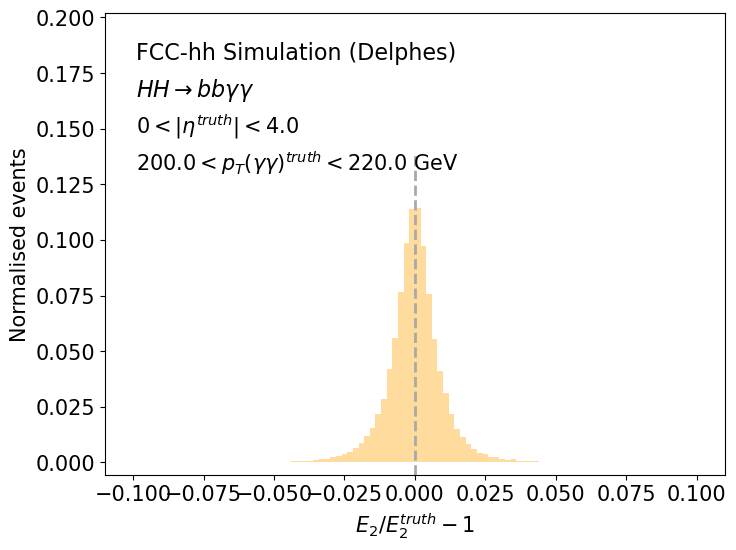

/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


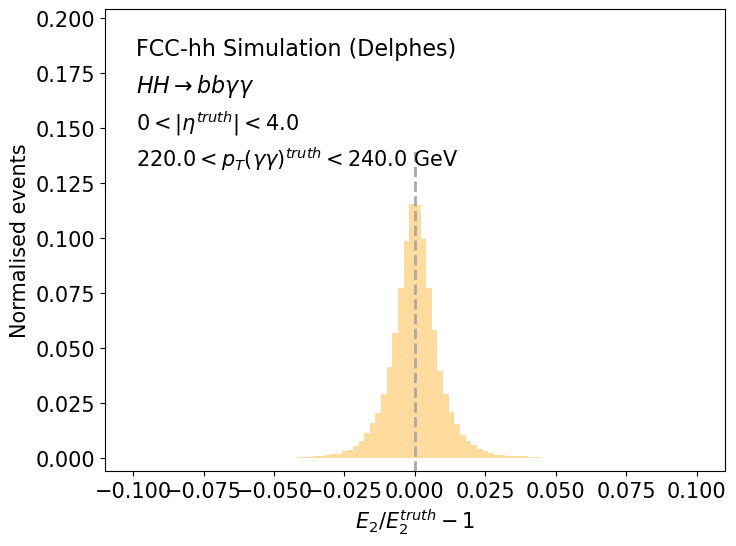

/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


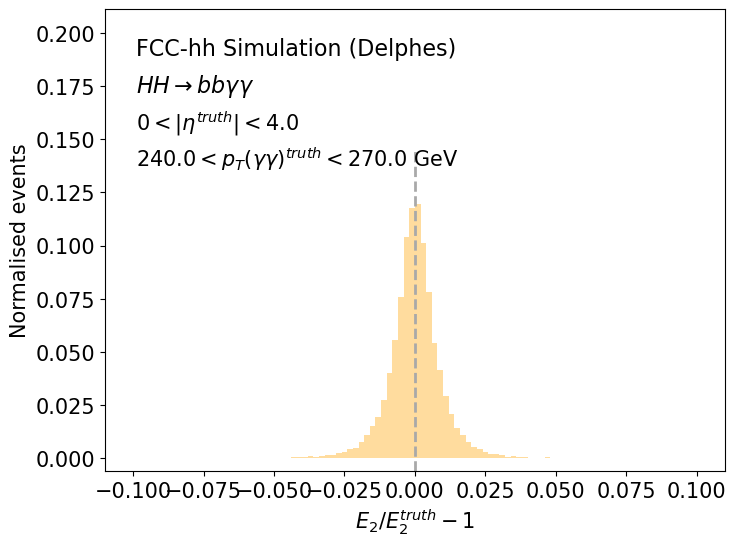

/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


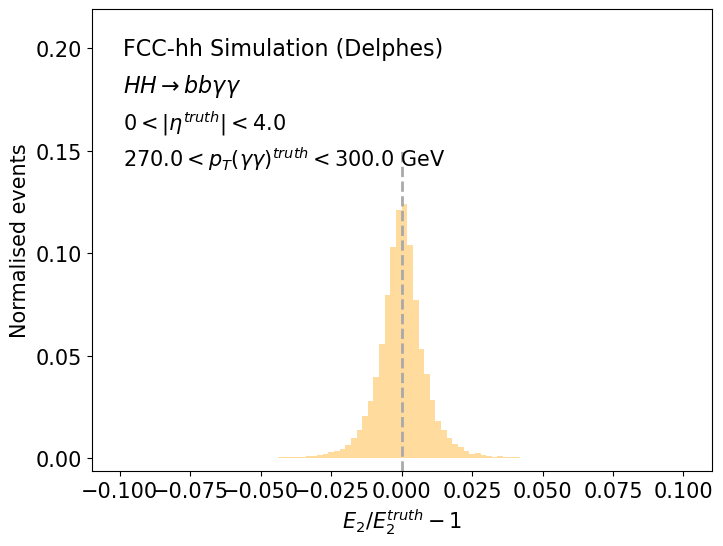

/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


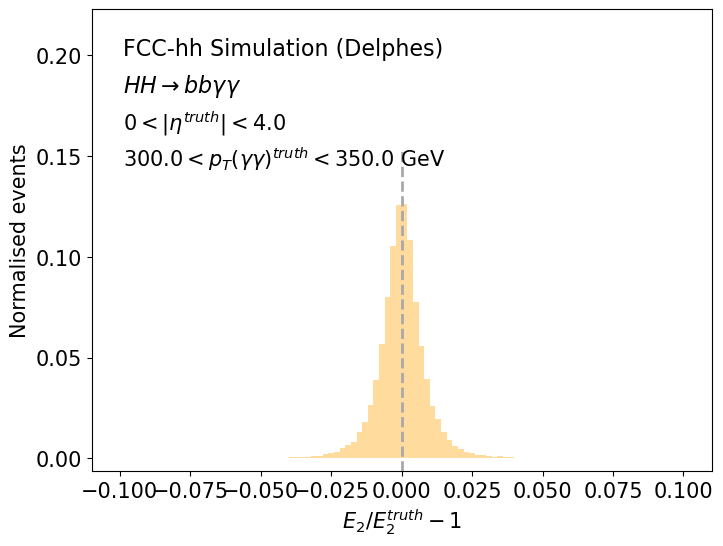

/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


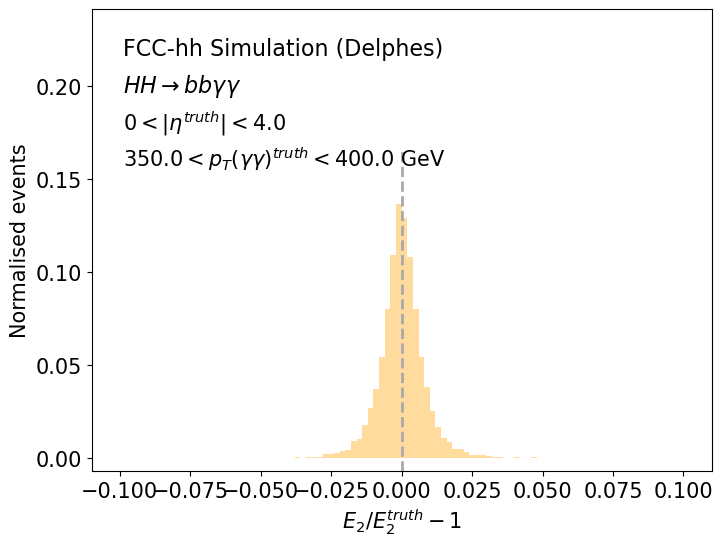

/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


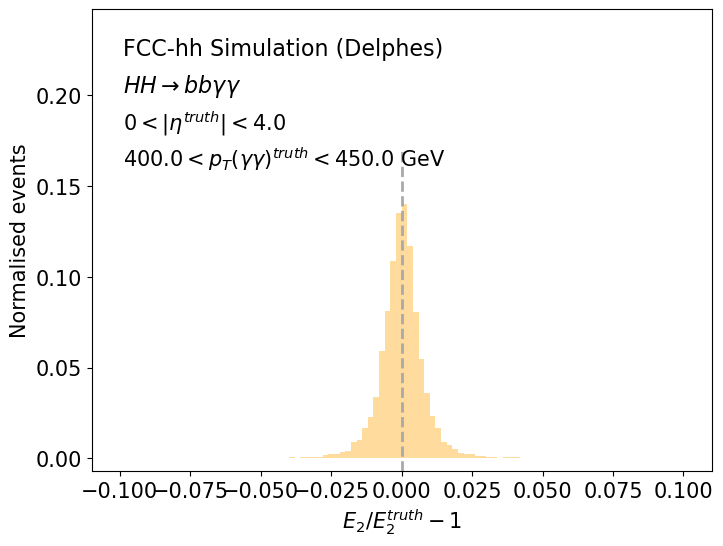

/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


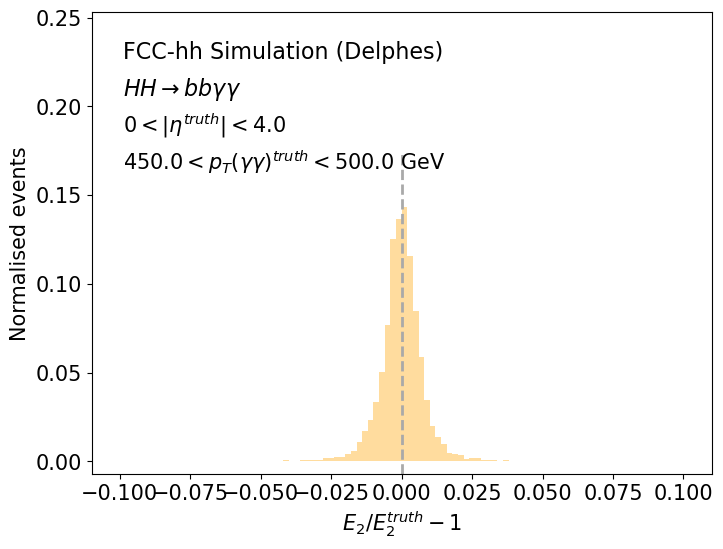

/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


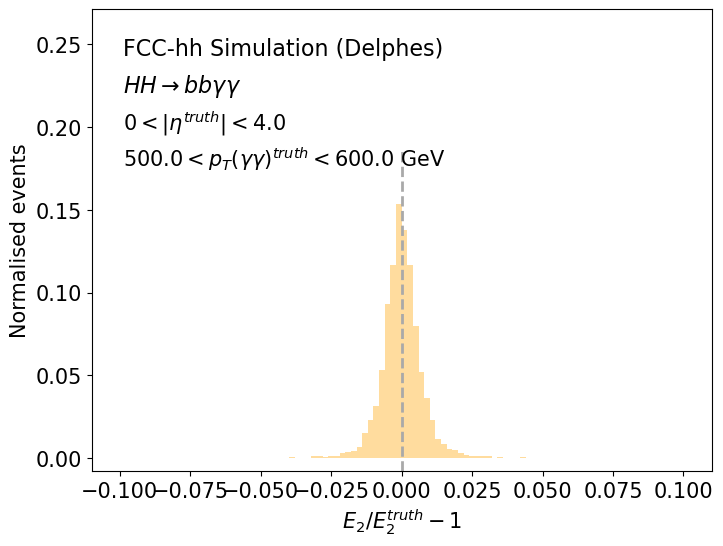

/tmp/elmazzeo/ipykernel_496224/513861296.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))


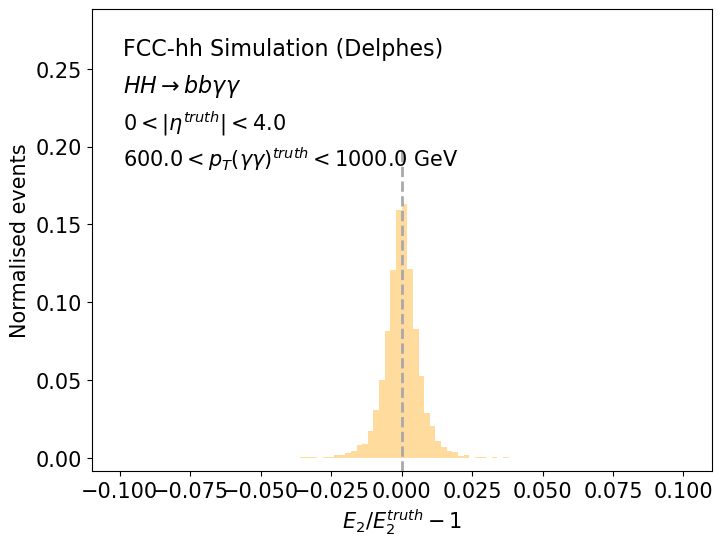

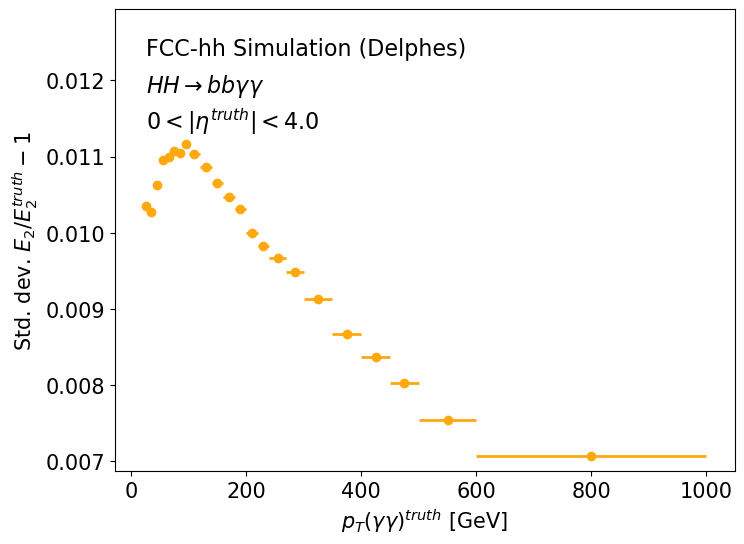

In [49]:
ENERGY_BINS = np.array([20, 30, 40, 50, 60, 70, 80, 90, 100,
                       120, 140, 160, 180, 200,
                       220, 240, 270, 300,
                       350, 400, 450, 500, 600, 1000], dtype=np.float64)
x = 0.5*(ENERGY_BINS[:-1] + ENERGY_BINS[1:])
xerr = 0.5*(ENERGY_BINS[1:] - ENERGY_BINS[:-1])

df1 = df[process_key][sel_key].query("(abs(true_eta_y1)<4.0) & (abs(true_eta_y2)<4.0)")

df1['energy_bin'] = np.digitize(np.abs(df1['true_pT_yy']), ENERGY_BINS)

y = np.zeros(len(ENERGY_BINS)-1)
for jbin in range(1, len(ENERGY_BINS)) :
    i_low = 0
    i_up = 4.0
    j_low = ENERGY_BINS[jbin-1]
    j_up = ENERGY_BINS[jbin] 
        
    df_all = df1[(df1['energy_bin']==jbin)]
    df_all["obs"] = df_all['E_y2']/df_all['true_E_y2']-np.ones(len(df_all))
    df_all = df_all.query("abs(obs)<0.1")
    observable = df_all["obs"].copy()
    resolution = np.std(observable)
    y[jbin-1] = resolution
    
    # E / Etrue -1
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(8,6)
    )
    ax.hist(observable, weights=df_all['weight']/df_all['weight'].sum(),
            bins=100, range=(-0.1,0.1), histtype='stepfilled', color=process_color, alpha=0.4)
    ax.axvline(0, ymin=0, ymax=0.7, color='darkgrey', ls='--', lw=2.)

    ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.82, process_label, transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.74, str(i_low)+"$<|\eta^{truth}|<$"+str(i_up), transform=ax.transAxes, fontsize=15)
    ax.text(0.05, 0.66, str(j_low)+"$<p_T(\gamma\gamma)^{truth}<$"+str(j_up)+" GeV", transform=ax.transAxes, fontsize=15)
    xlabel = "$E_2/E_2^{truth}-1$"
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'Normalised events')

    ymin,ymax = ax.get_ylim() 
    ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.65)
    
    plotname = "e2reco_over_e2true_very_central_photons_true_pT_yy_bin_"+str(jbin)
    plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
    plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
    plt.show()        

fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

ax.errorbar(x, y, xerr=xerr, color=process_color, marker='o', lw=2, ls='none')

ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, process_label, transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.74, str(i_low)+"$<|\eta^{truth}|<$"+str(i_up), transform=ax.transAxes, fontsize=16)
xlabel = "$p_T(\gamma\gamma)^{truth}$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Std. dev. $E_2/E_2^{truth}-1$')

ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.35)
    
plotname = "e2reco_over_e2true_hhbbyy_true_pT_yy_bins"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()  

/tmp/elmazzeo/ipykernel_496224/3387924707.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['energy_bin'] = np.digitize(np.abs(df1['true_pT_yy']), ENERGY_BINS)
/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


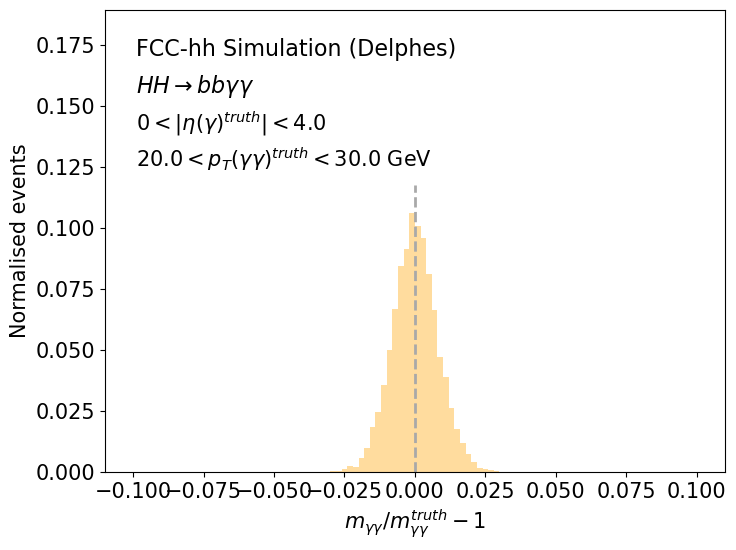

/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


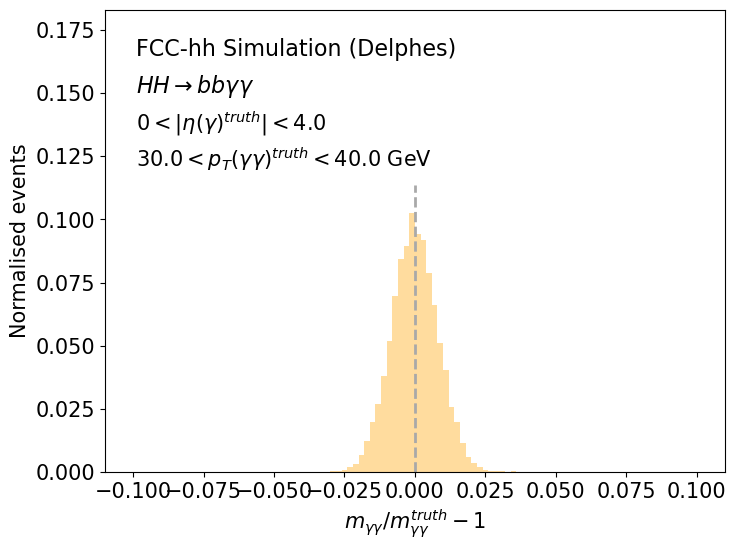

/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


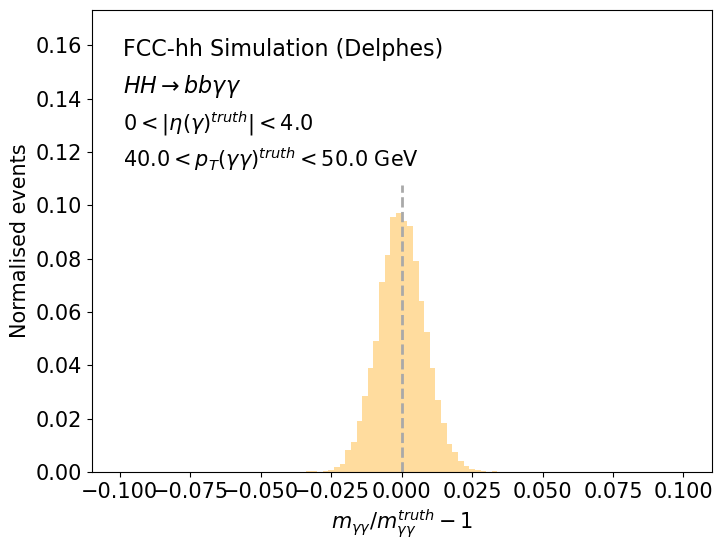

/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


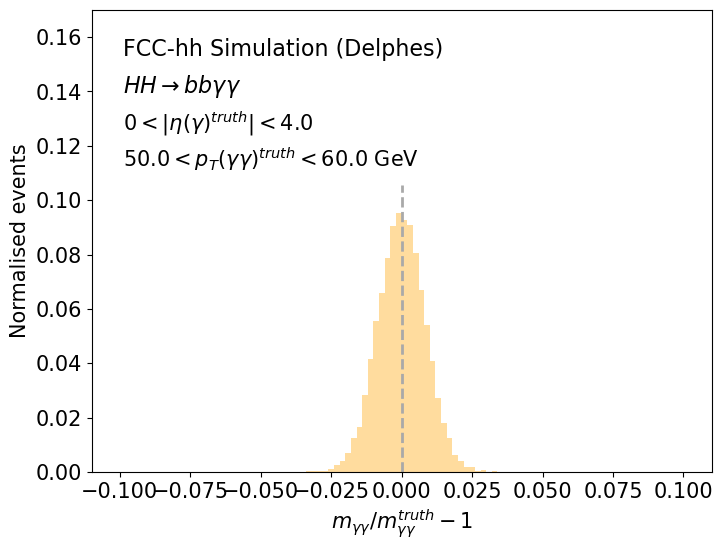

/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


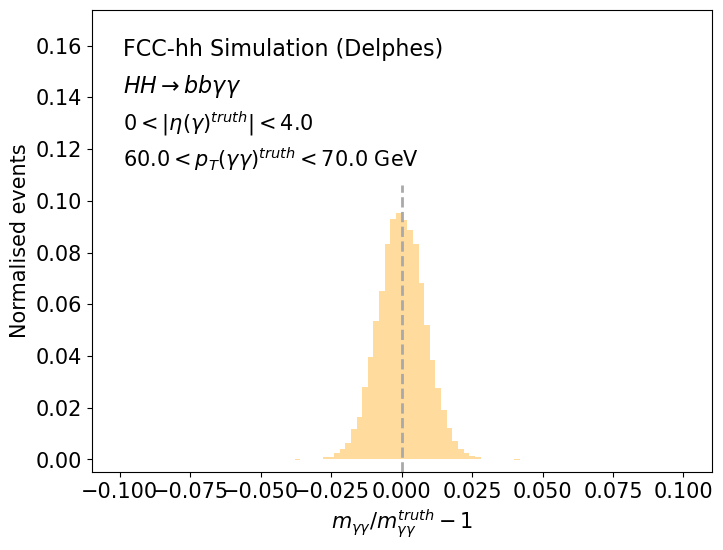

/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


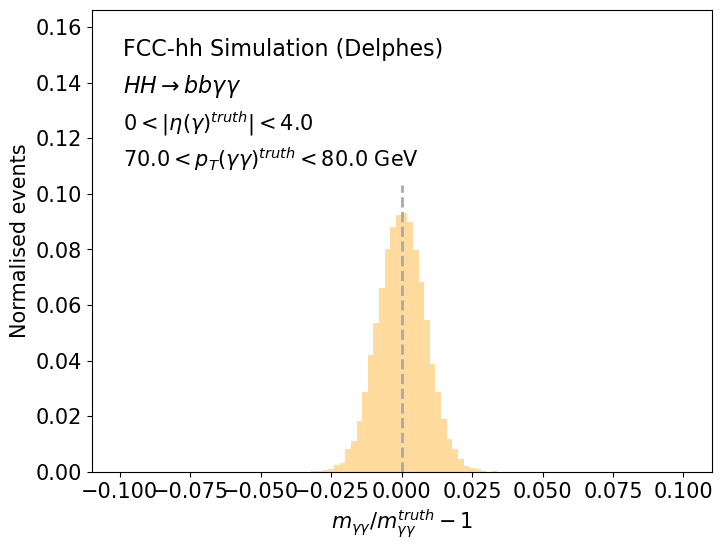

/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


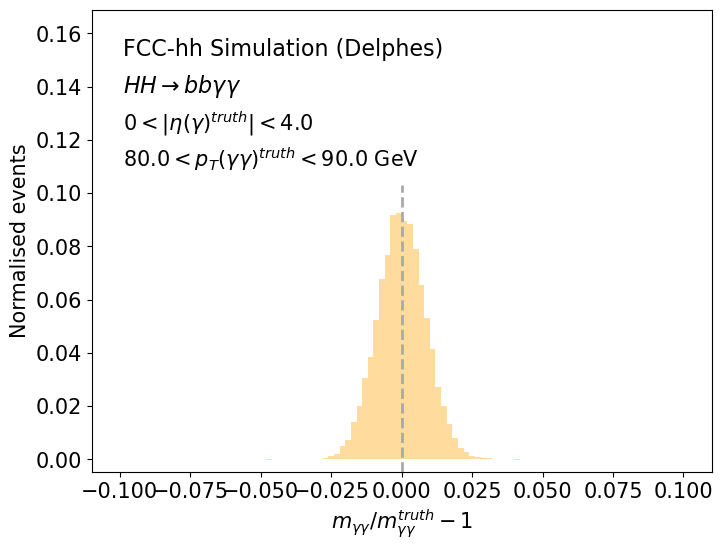

/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


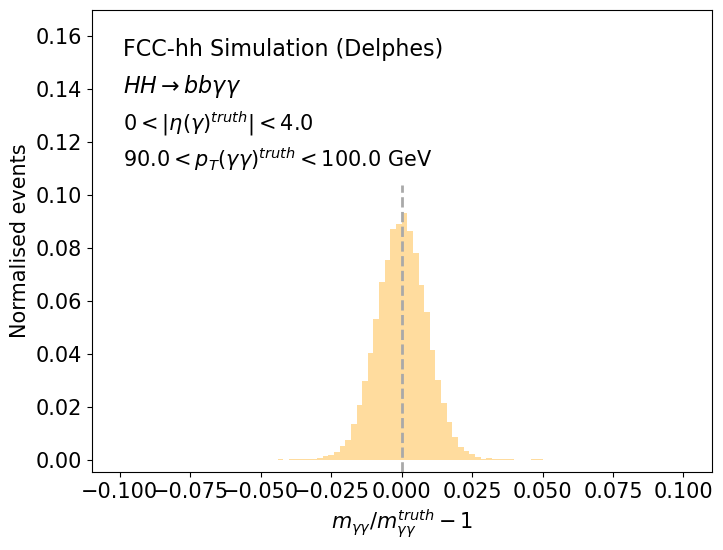

/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


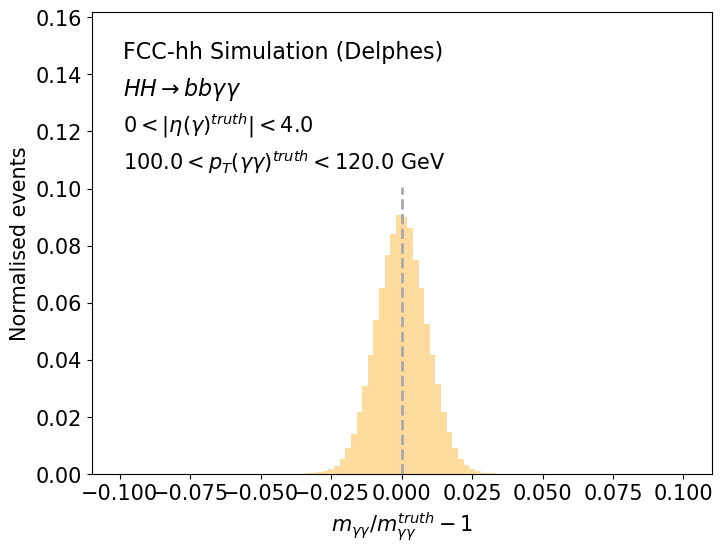

/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


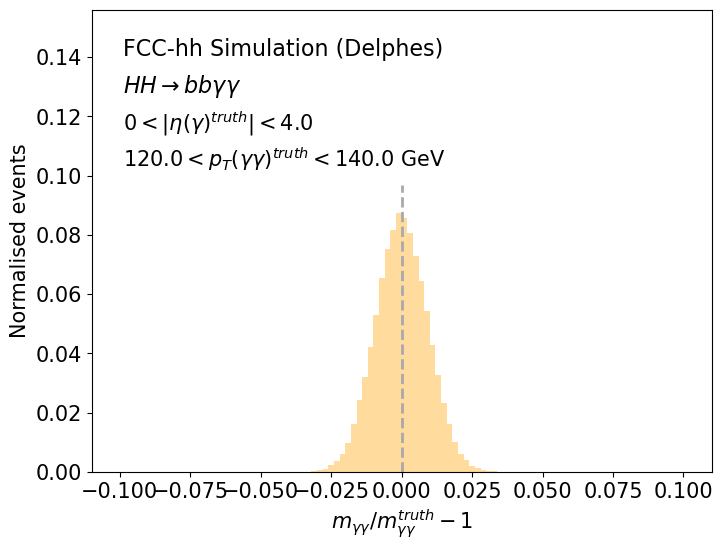

/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


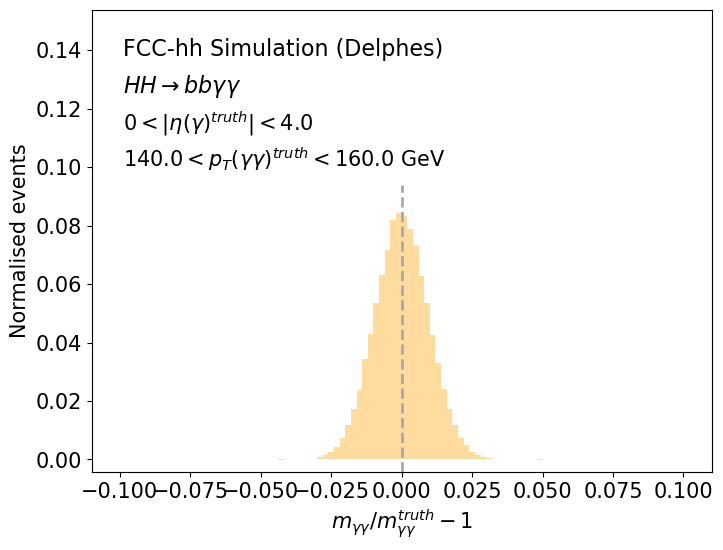

/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


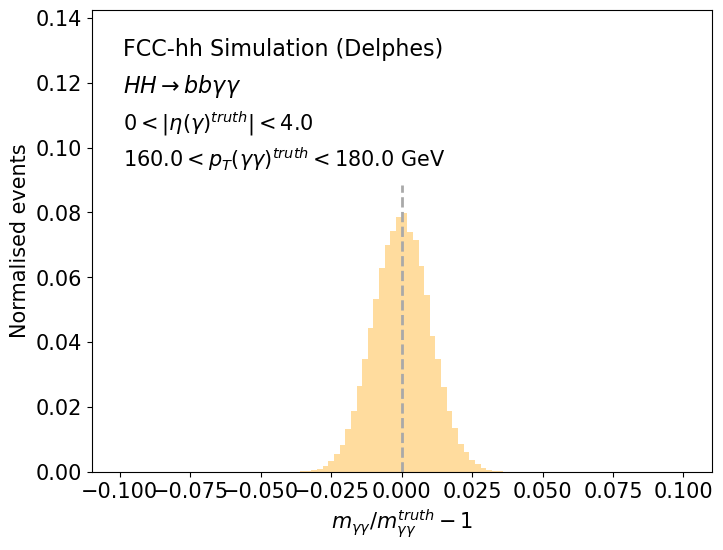

/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


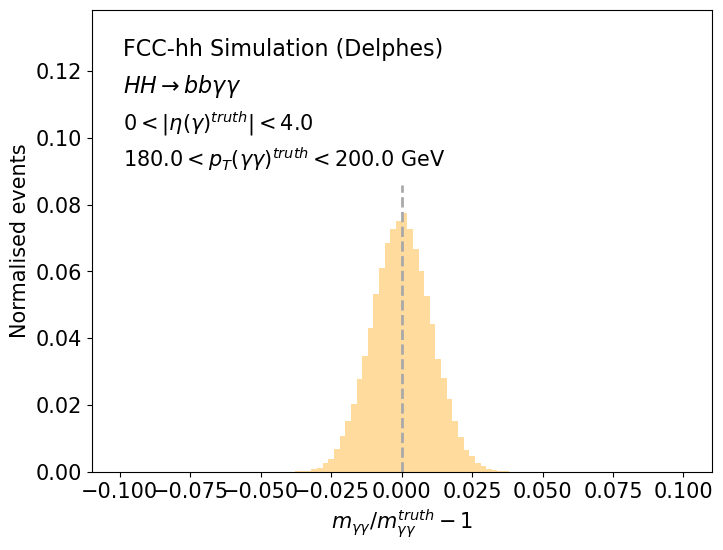

/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


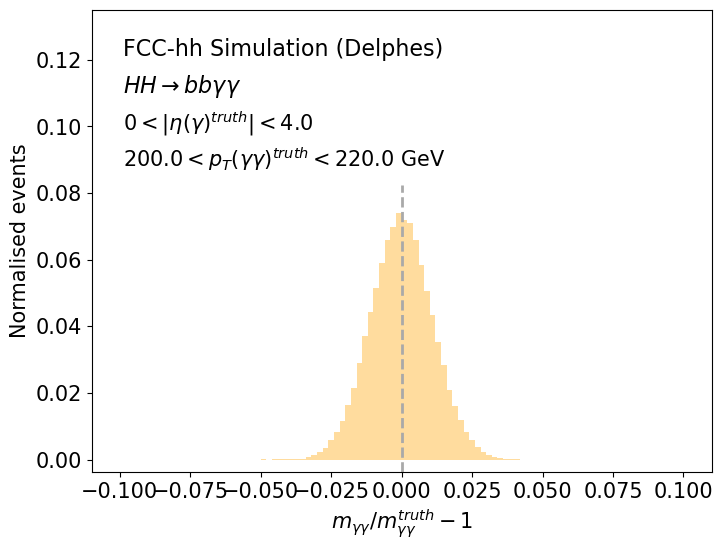

/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


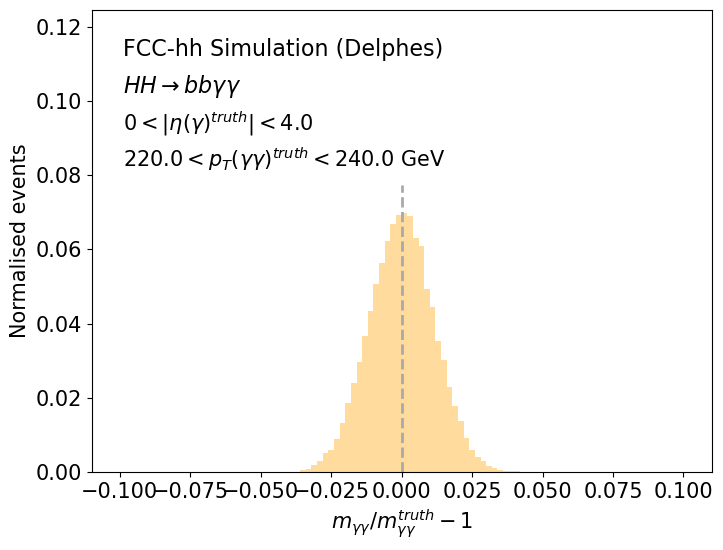

/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


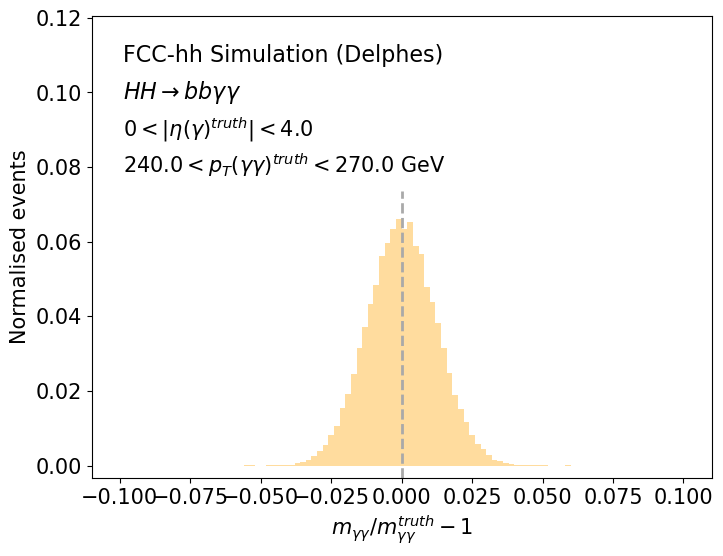

/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


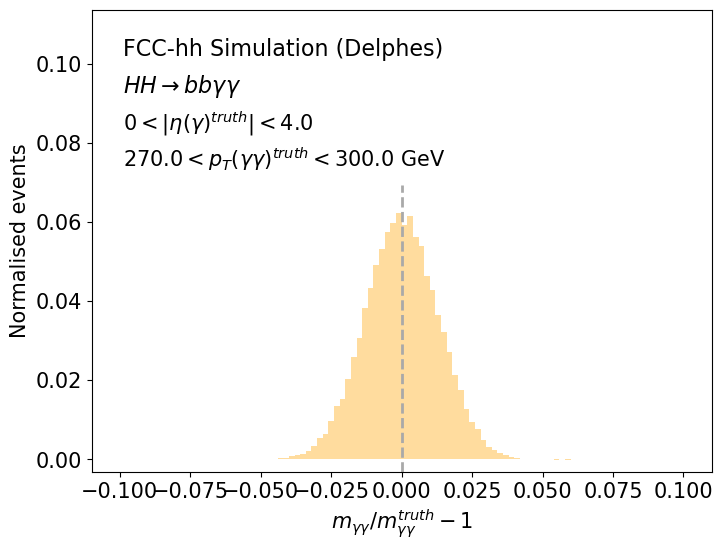

/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


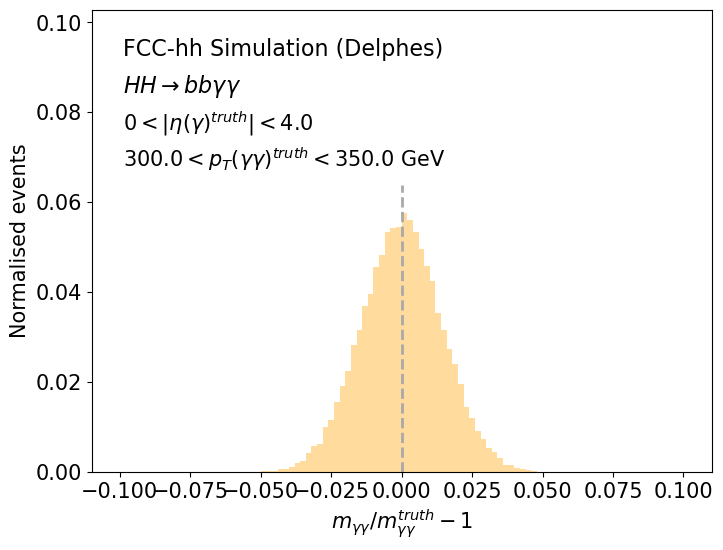

/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


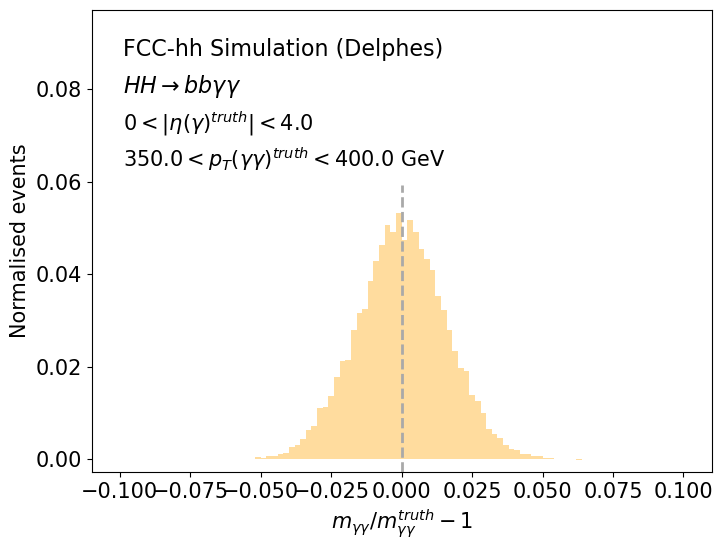

/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


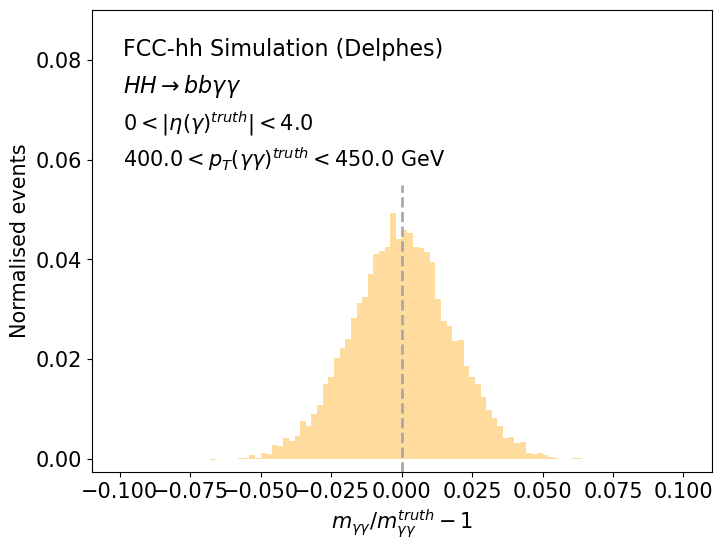

/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


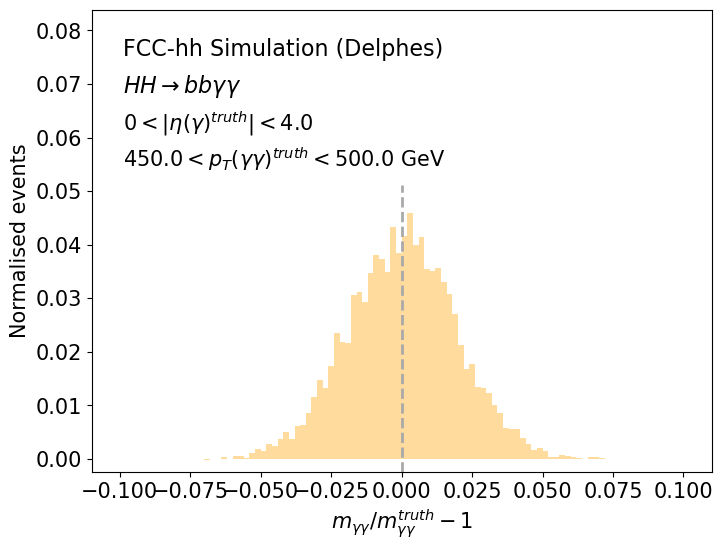

/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


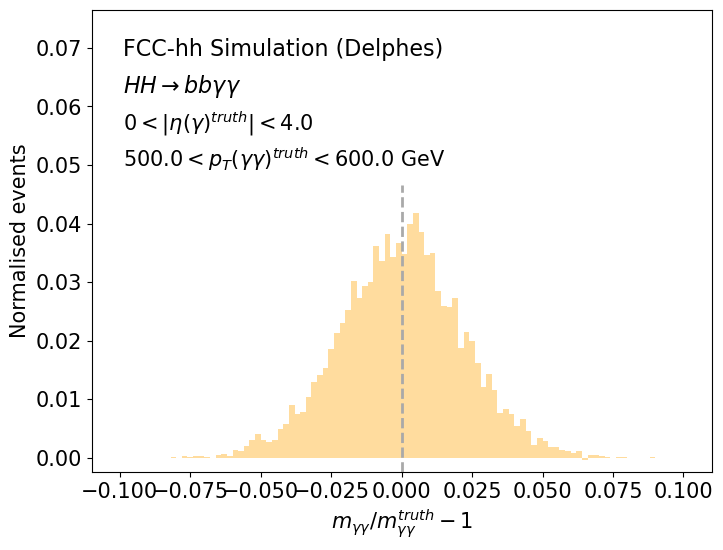

/tmp/elmazzeo/ipykernel_496224/3387924707.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))


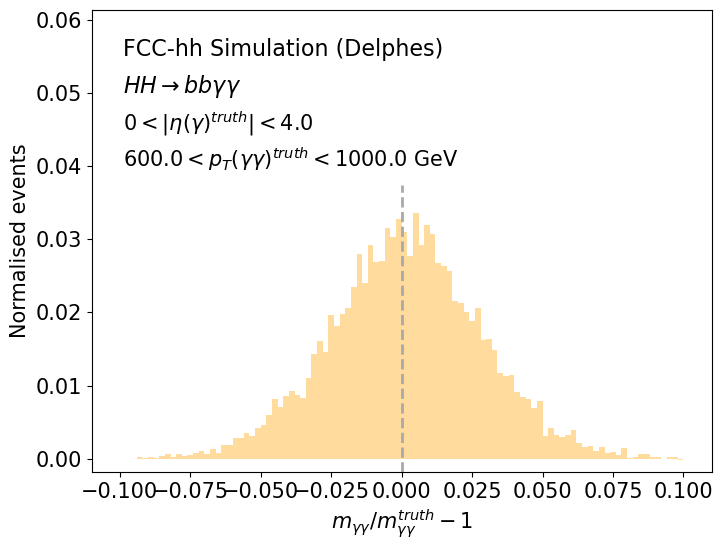

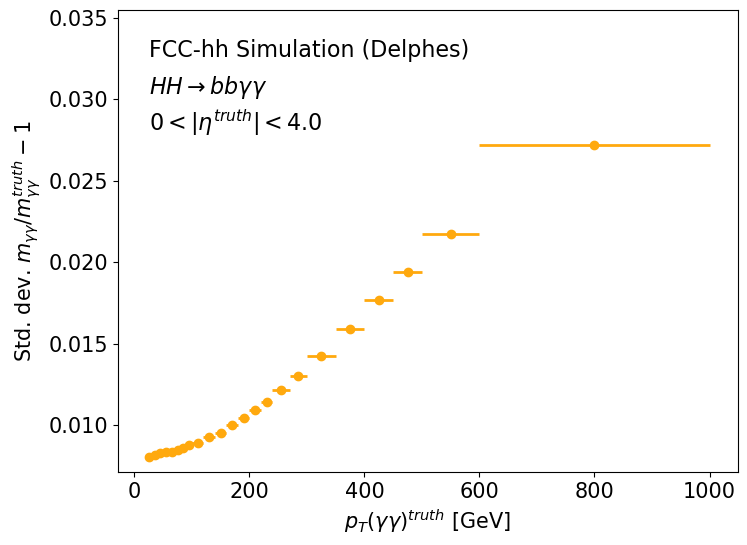

In [50]:
ENERGY_BINS = np.array([20, 30, 40, 50, 60, 70, 80, 90, 100,
                       120, 140, 160, 180, 200,
                       220, 240, 270, 300,
                       350, 400, 450, 500, 600, 1000], dtype=np.float64)
x = 0.5*(ENERGY_BINS[:-1] + ENERGY_BINS[1:])
xerr = 0.5*(ENERGY_BINS[1:] - ENERGY_BINS[:-1])

df1 = df[process_key][sel_key].query("(abs(true_eta_y1)<4.0) & (abs(true_eta_y2)<4.0)")

df1['energy_bin'] = np.digitize(np.abs(df1['true_pT_yy']), ENERGY_BINS)

y = np.zeros(len(ENERGY_BINS)-1)
for jbin in range(1, len(ENERGY_BINS)) :
    i_low = 0
    i_up = 4.0
    j_low = ENERGY_BINS[jbin-1]
    j_up = ENERGY_BINS[jbin] 
        
    df_all = df1[(df1['energy_bin']==jbin)]
    df_all["obs"] = df_all['m_yy']/df_all['true_m_yy']-np.ones(len(df_all))
    df_all = df_all.query("abs(obs)<0.1")
    observable = df_all["obs"].copy()
    resolution = np.std(observable)
    y[jbin-1] = resolution
    
    # E / Etrue -1
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(8,6)
    )
    ax.hist(observable, weights=df_all['weight']/df_all['weight'].sum(),
            bins=100, range=(-0.1,0.1), histtype='stepfilled', color=process_color, alpha=0.4)
    ax.axvline(0, ymin=0, ymax=0.62, color='darkgrey', ls='--', lw=2.)

    ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.82, process_label, transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.74, str(i_low)+"$<|\eta(\gamma)^{truth}|<$"+str(i_up), transform=ax.transAxes, fontsize=15)
    ax.text(0.05, 0.66, str(j_low)+"$<p_T(\gamma\gamma)^{truth}<$"+str(j_up)+" GeV", transform=ax.transAxes, fontsize=15)
    xlabel = "$m_{\gamma\gamma}/m_{\gamma\gamma}^{truth}-1$"
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'Normalised events')

    ymin,ymax = ax.get_ylim() 
    ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.70)
    
    plotname = "myyreco_over_myytruth_hhbbyy_true_pT_yy_bin"+str(jbin)
    plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
    plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
    plt.show()        

fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

ax.errorbar(x, y, xerr=xerr, color=process_color, marker='o', lw=2, ls='none')

ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, process_label, transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.74, str(i_low)+"$<|\eta^{truth}|<$"+str(i_up), transform=ax.transAxes, fontsize=16)
xlabel = "$p_T(\gamma\gamma)^{truth}$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Std. dev. $m_{\gamma\gamma}/m_{\gamma\gamma}^{truth}-1$')

ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.35)
    
plotname = "myyreco_over_myytruth_hhbbyy_true_pT_yy_bins"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show() 

/tmp/elmazzeo/ipykernel_546402/2557694008.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['theta_y_y']/df_all['true_theta_y_y']-np.ones(len(df_all))
/tmp/elmazzeo/ipykernel_546402/2557694008.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['theta_y_y']/df_all['true_theta_y_y']-np.ones(len(df_all))
/tmp/elmazzeo/ipykernel_546402/2557694008.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[ro

/tmp/elmazzeo/ipykernel_546402/2557694008.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['theta_y_y']/df_all['true_theta_y_y']-np.ones(len(df_all))
/tmp/elmazzeo/ipykernel_546402/2557694008.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['theta_y_y']/df_all['true_theta_y_y']-np.ones(len(df_all))


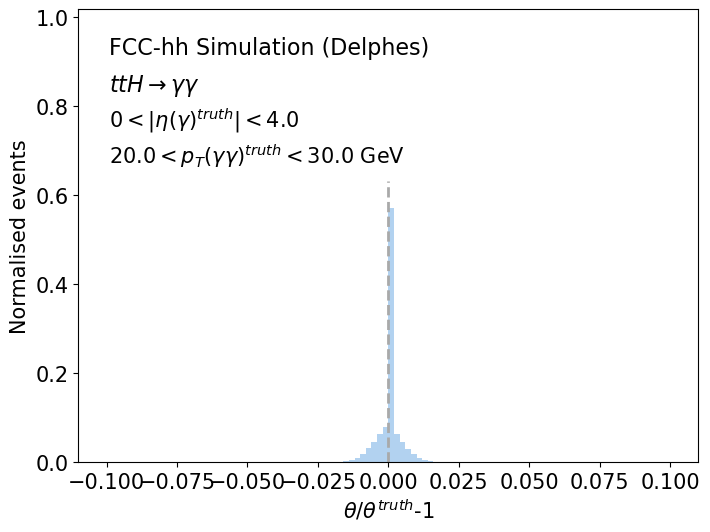

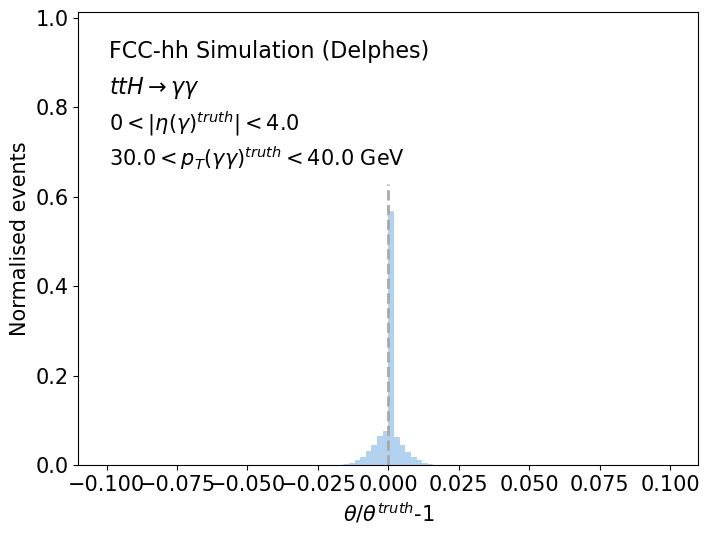

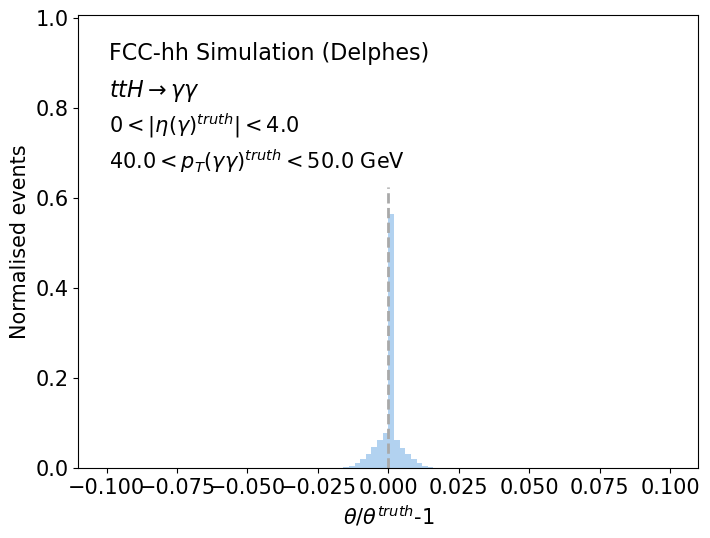

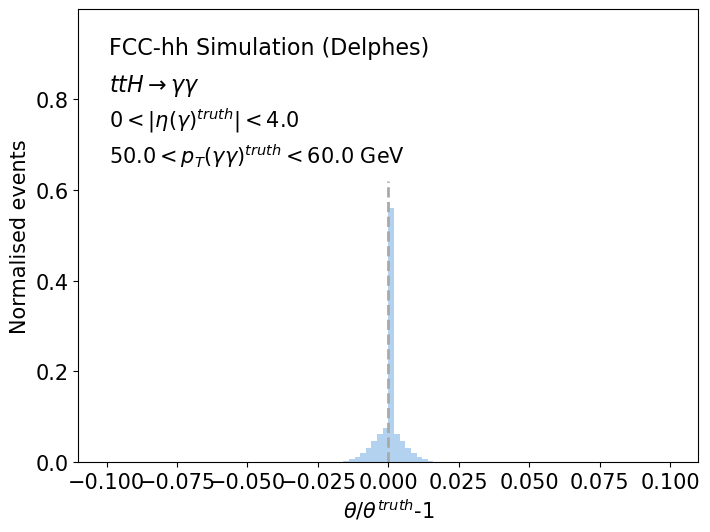

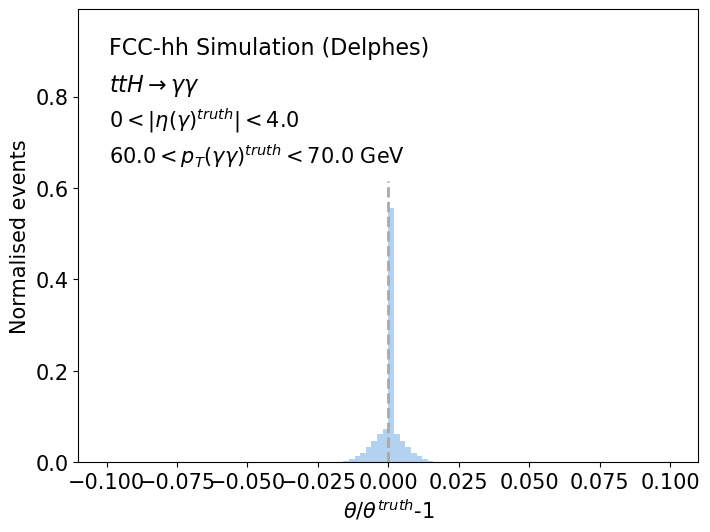

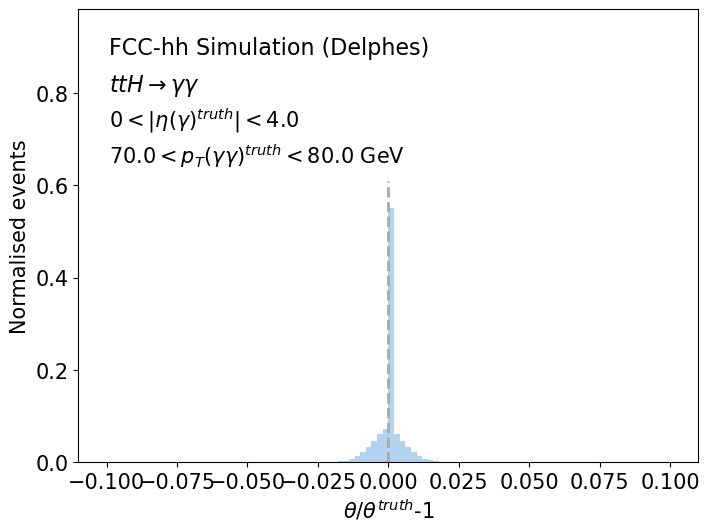

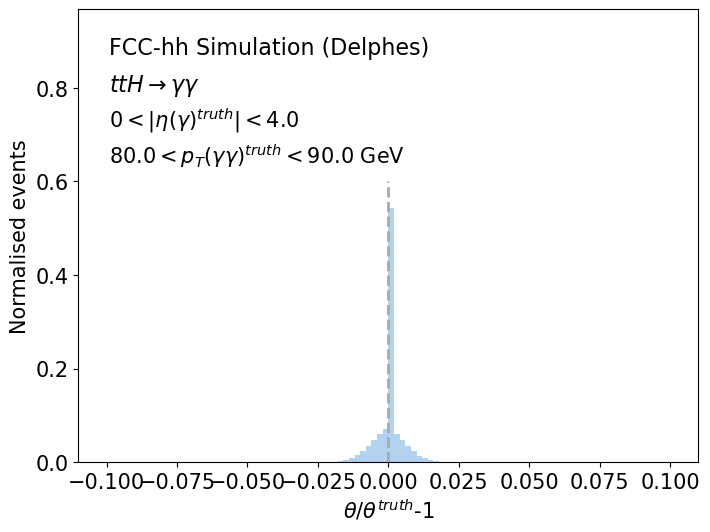

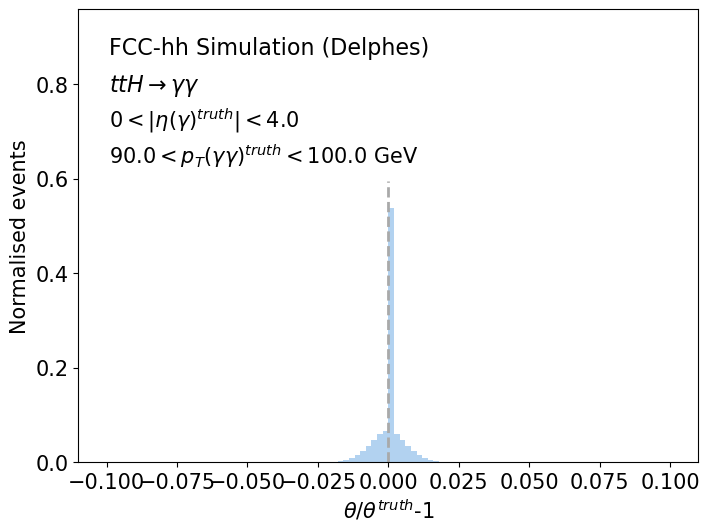

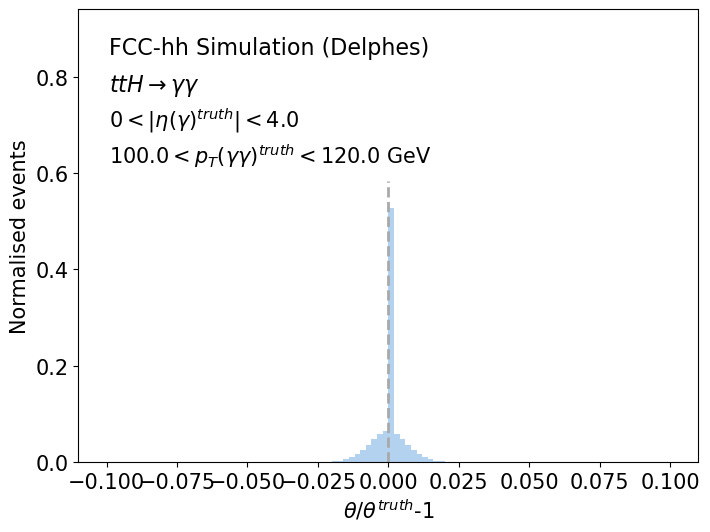

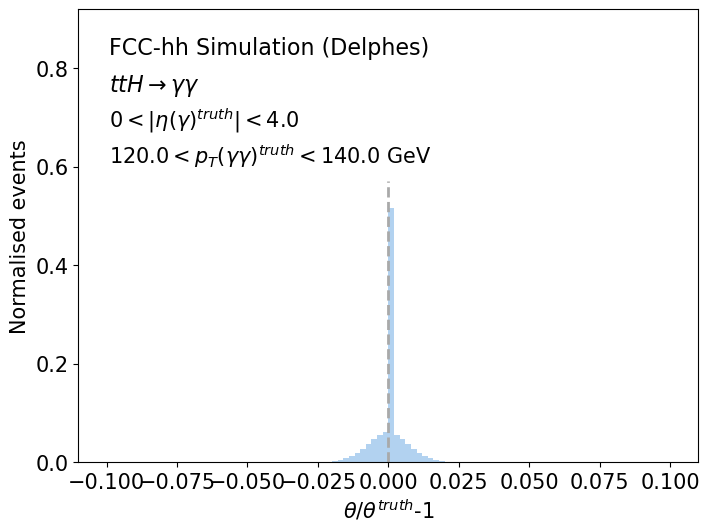

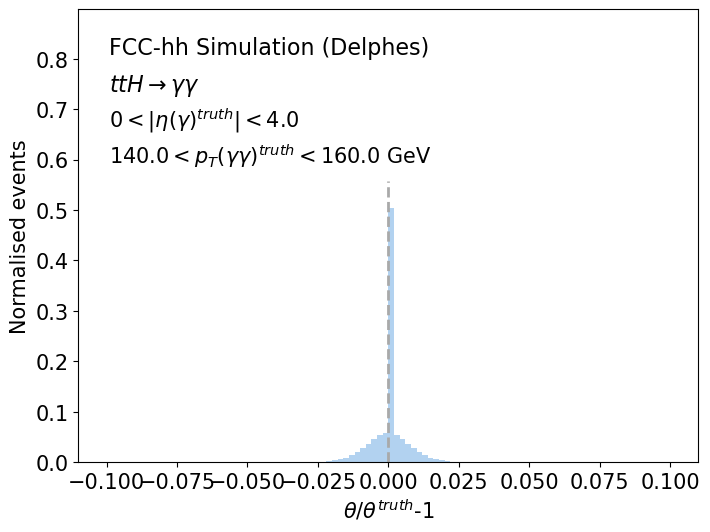

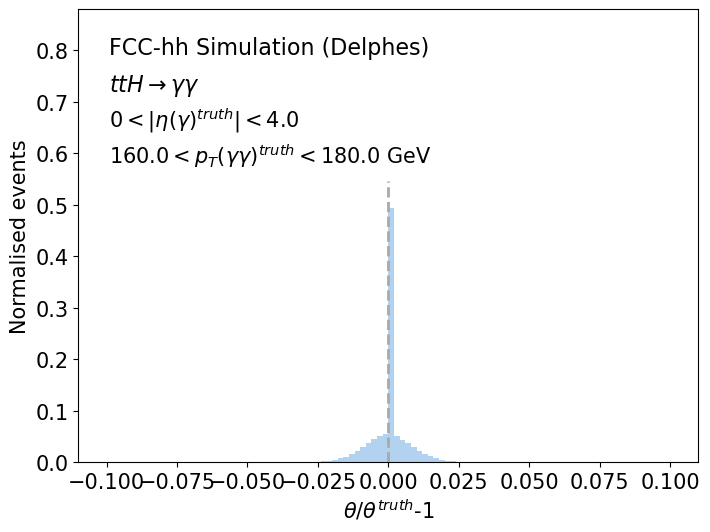

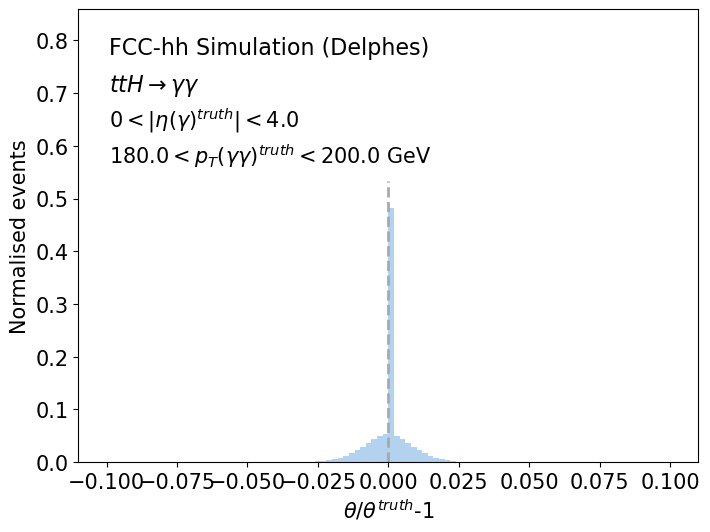

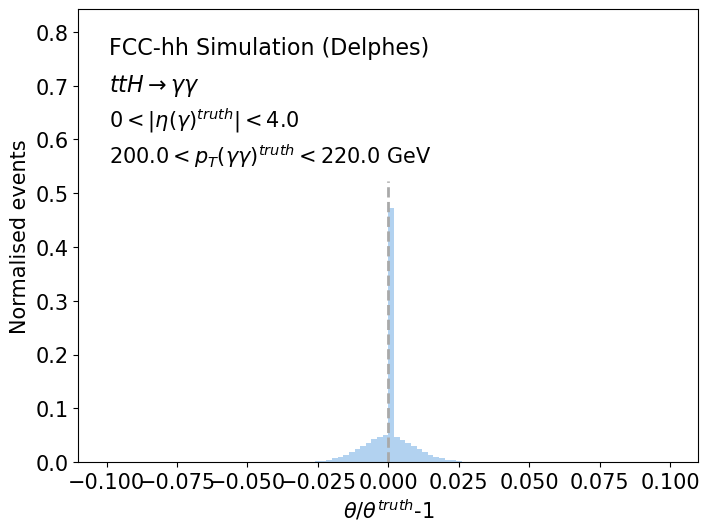

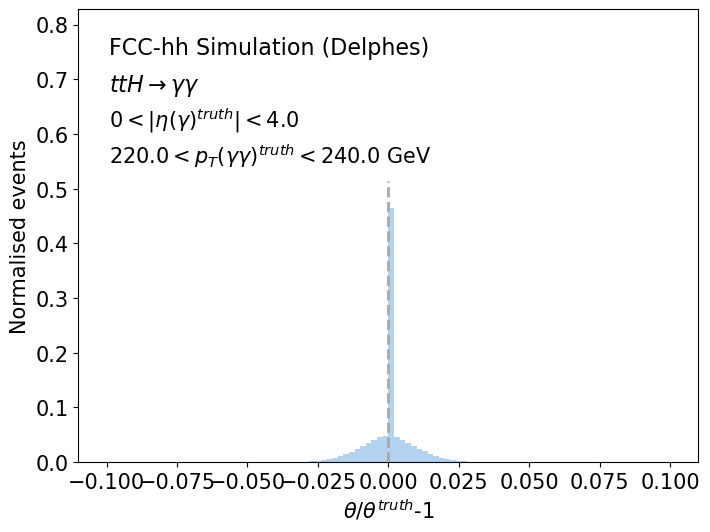

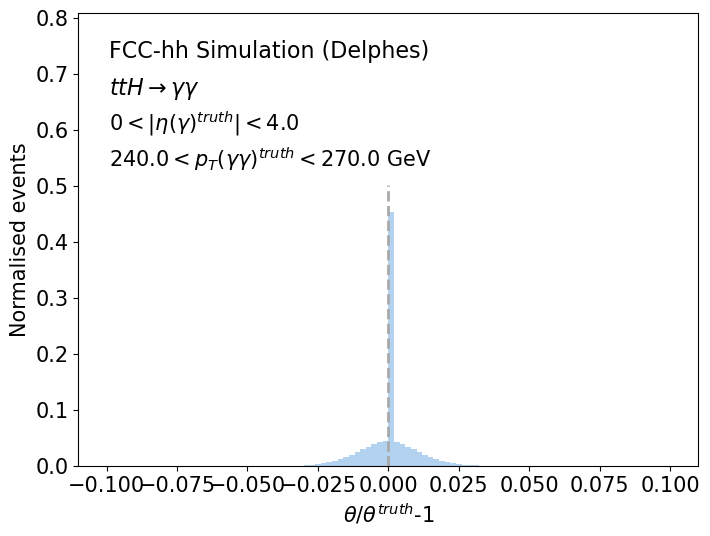

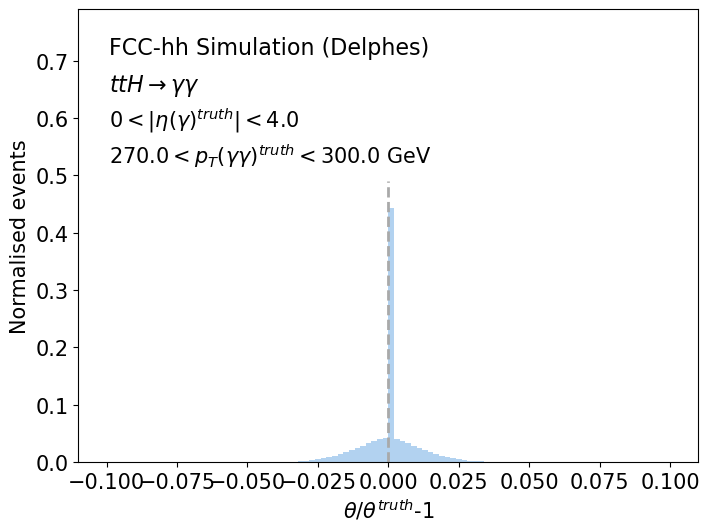

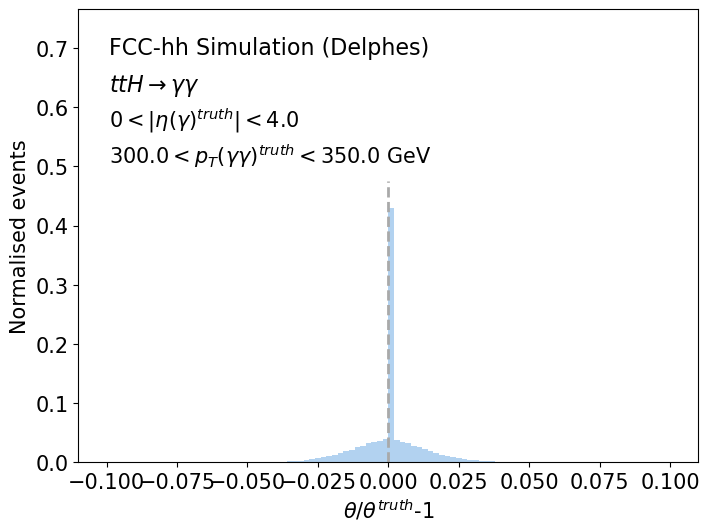

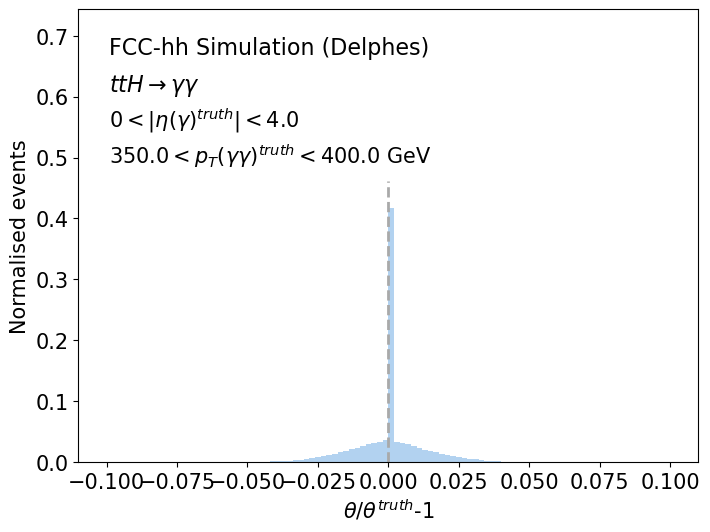

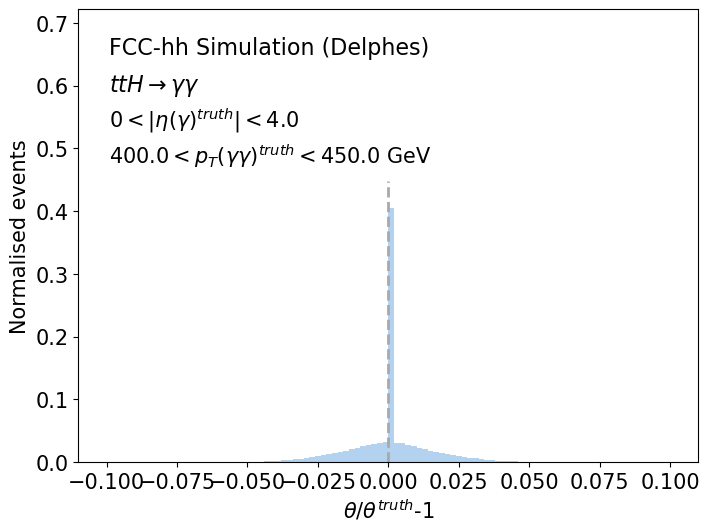

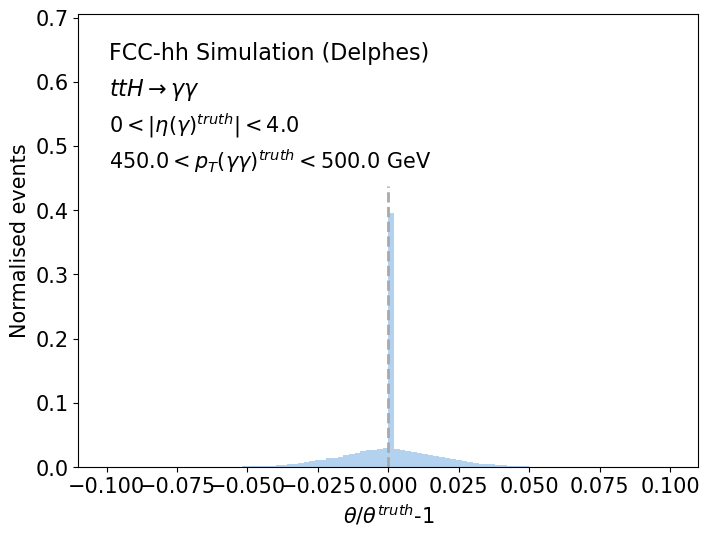

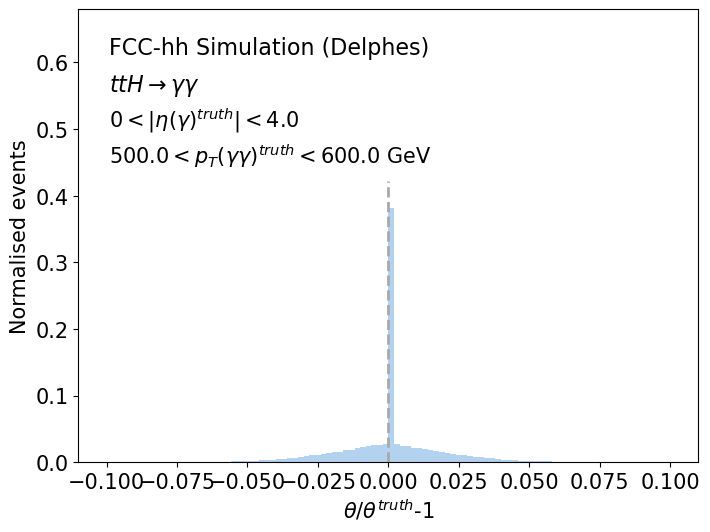

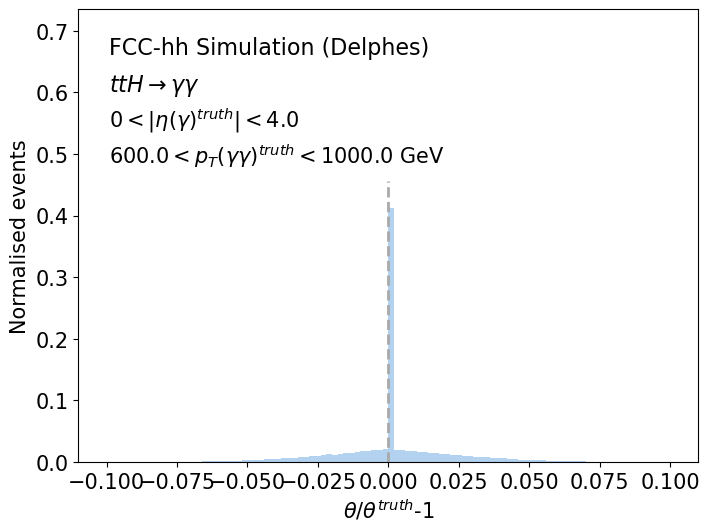

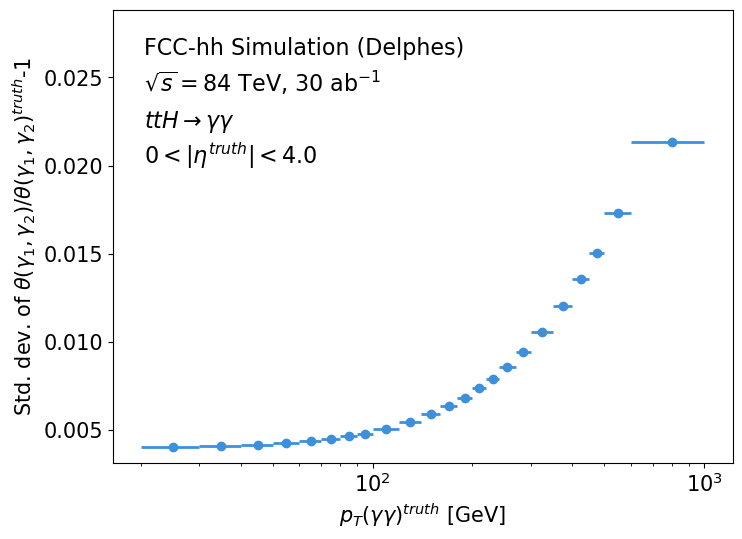

In [26]:
ENERGY_BINS = np.array([20, 30, 40, 50, 60, 70, 80, 90, 100,
                       120, 140, 160, 180, 200,
                       220, 240, 270, 300,
                       350, 400, 450, 500, 600, 1000], dtype=np.float64)
x = 0.5*(ENERGY_BINS[:-1] + ENERGY_BINS[1:])
xerr = 0.5*(ENERGY_BINS[1:] - ENERGY_BINS[:-1])

df1 = df[process_key][sel_key].copy()

df1['energy_bin'] = np.digitize(np.abs(df1['pT_higgs']), ENERGY_BINS)

y = np.zeros(len(ENERGY_BINS)-1)
for jbin in range(1, len(ENERGY_BINS)) :
    i_low = 0
    i_up = 4.0
    j_low = ENERGY_BINS[jbin-1]
    j_up = ENERGY_BINS[jbin] 
        
    df_all = df1[(df1['energy_bin']==jbin)]
    df_all["obs"] = df_all['theta_y_y']/df_all['true_theta_y_y']-np.ones(len(df_all))
    df_all = df_all.query("abs(obs)<0.1")
    observable = df_all["obs"].copy()
    resolution = np.std(observable)
    y[jbin-1] = resolution
    
    # E / Etrue -1
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(8,6)
    )
    ax.hist(observable, weights=df_all['weight']/df_all['weight'].sum(),
            bins=100, range=(-0.1,0.1), histtype='stepfilled', color=color_sequence[0], alpha=0.4)
    ax.axvline(0, ymin=0, ymax=0.62, color='darkgrey', ls='--', lw=2.)

    ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.82, process_label, transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.74, str(i_low)+"$<|\eta(\gamma)^{truth}|<$"+str(i_up), transform=ax.transAxes, fontsize=15)
    ax.text(0.05, 0.66, str(j_low)+"$<p_T(\gamma\gamma)^{truth}<$"+str(j_up)+" GeV", transform=ax.transAxes, fontsize=15)
    xlabel = r"$\theta / \theta^{truth}$-1"
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'Normalised events')

    ymin,ymax = ax.get_ylim() 
    ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.70)
    
    #plotname = "costheta_over_truecostheta_central_photons_true_pT_yy_bin"+str(jbin)
    #plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
    #plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
    #plt.show()        

fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

ax.errorbar(x, y, xerr=xerr, color=color_sequence[0], marker='o', lw=2, ls='none')

ax.set_xscale("log")

ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$\sqrt{s}=84$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.74, process_label, transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.66, str(i_low)+"$<|\eta^{truth}|<$"+str(i_up), transform=ax.transAxes, fontsize=16)
xlabel = "$p_T(\gamma\gamma)^{truth}$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Std. dev. of $\theta(\gamma_1, \gamma_2) / \theta(\gamma_1, \gamma_2)^{truth}$-1')

ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.35)
outdir = "/eos/user/e/elmazzeo/ttH@FCC-hh/presentations/"
plotname = "theta_over_truetheta_true_pT_yy"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()

/tmp/elmazzeo/ipykernel_496224/620235003.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['energy_bin'] = np.digitize(np.abs(df1['true_pT_yy']), ENERGY_BINS)
/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


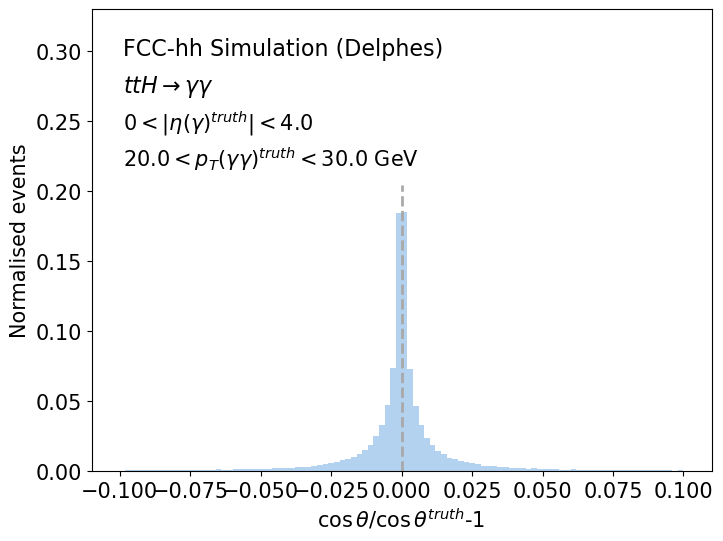

/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


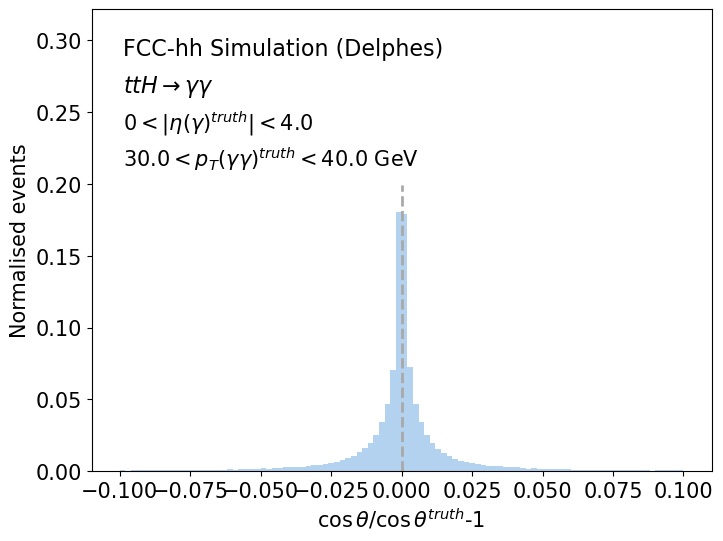

/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


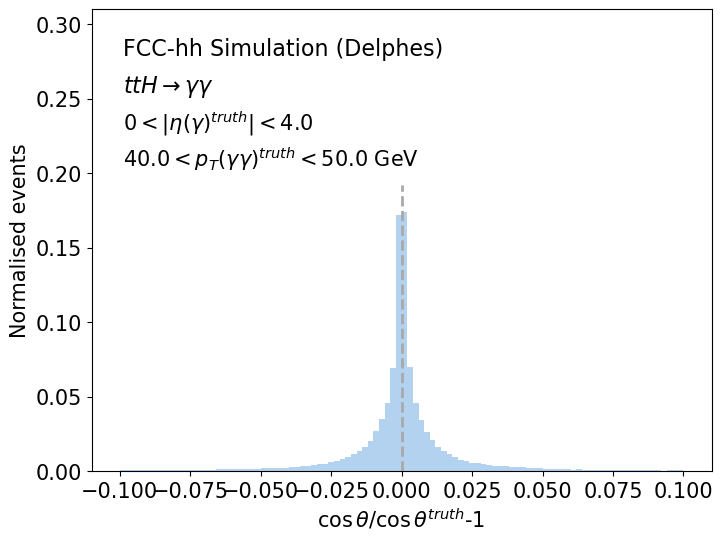

/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


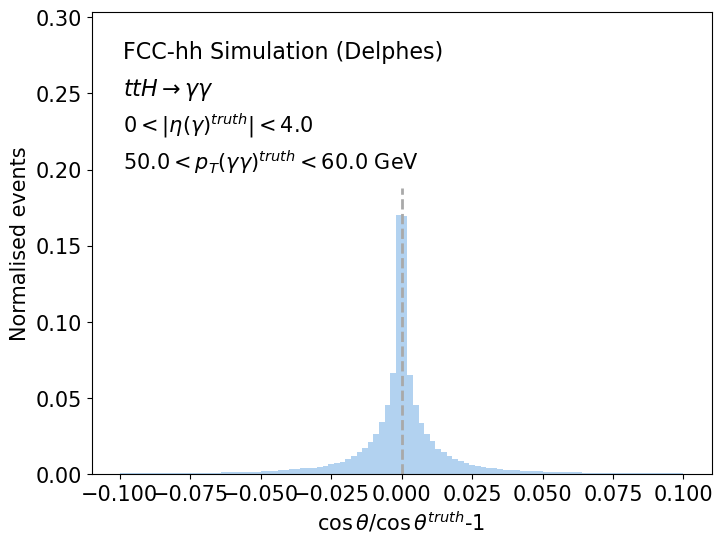

/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


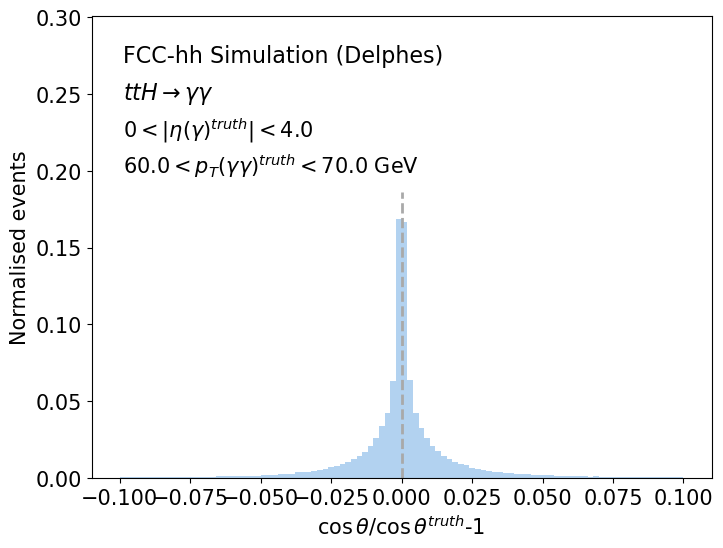

/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


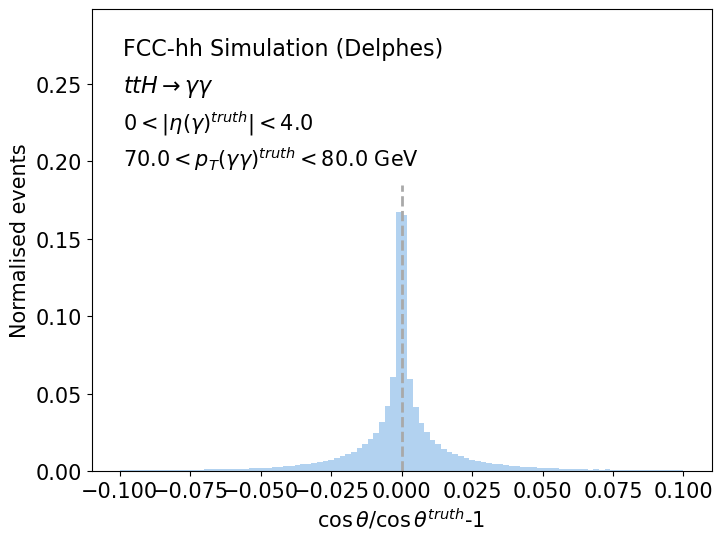

/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


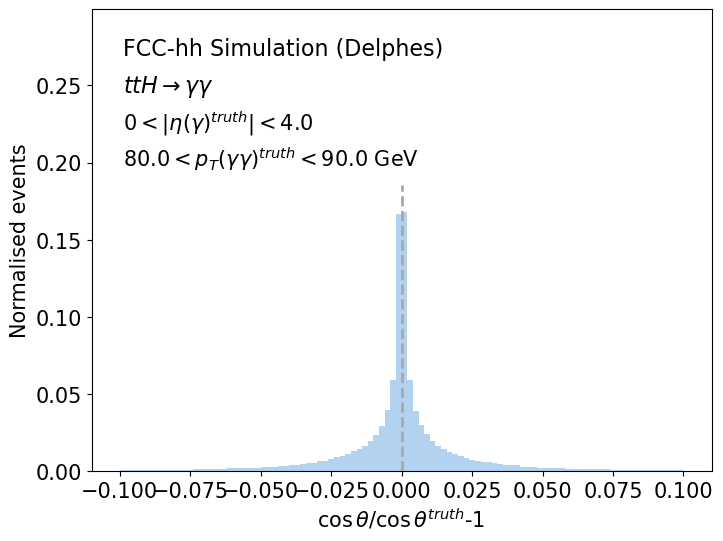

/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


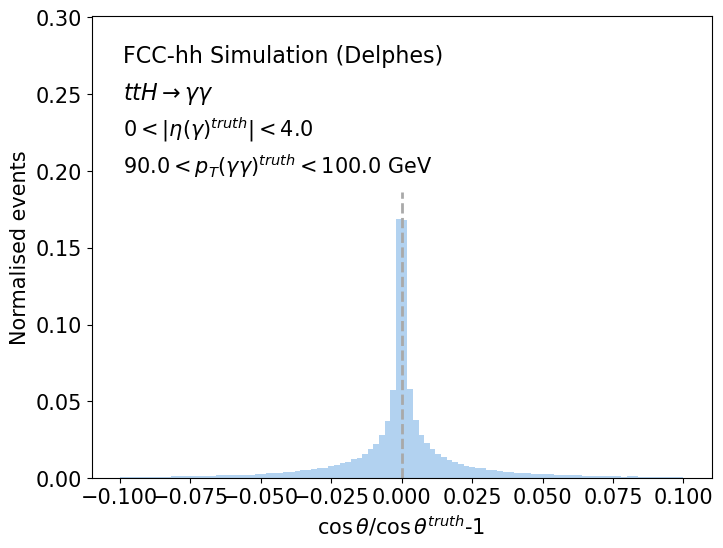

/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


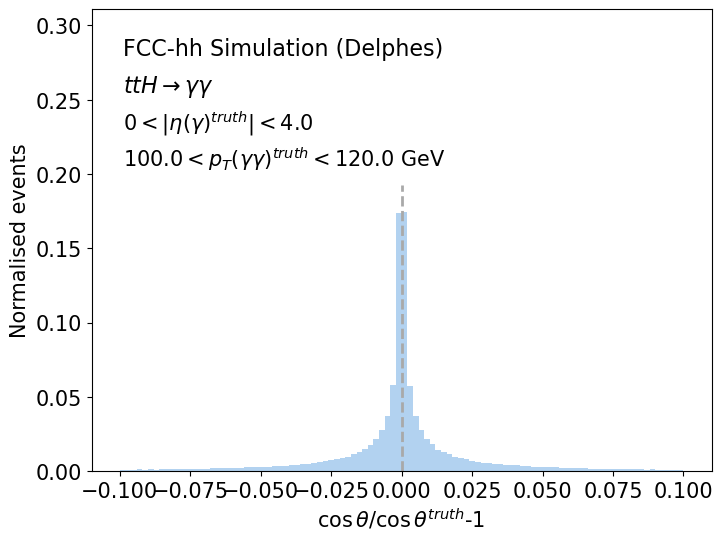

/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


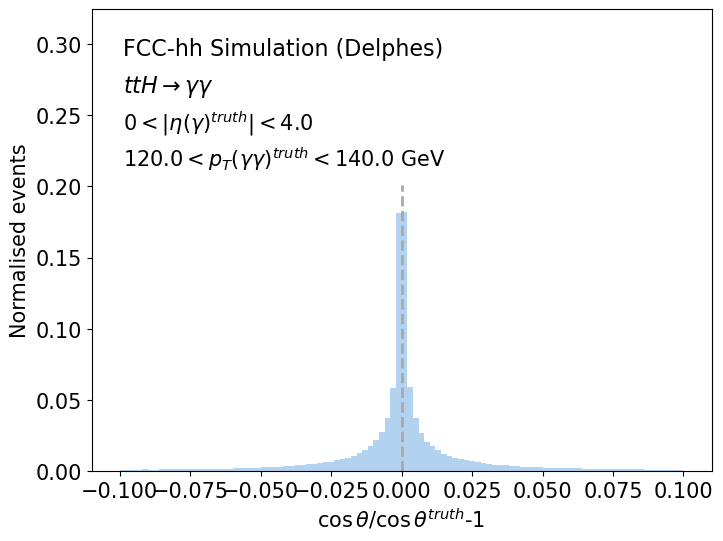

/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


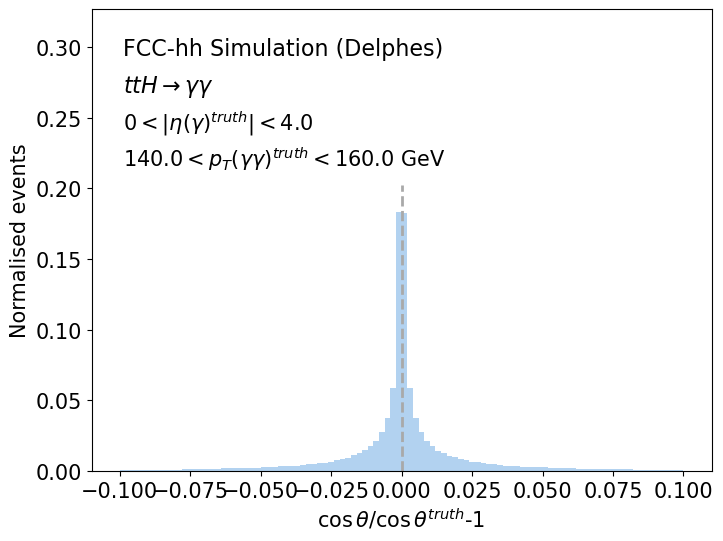

/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


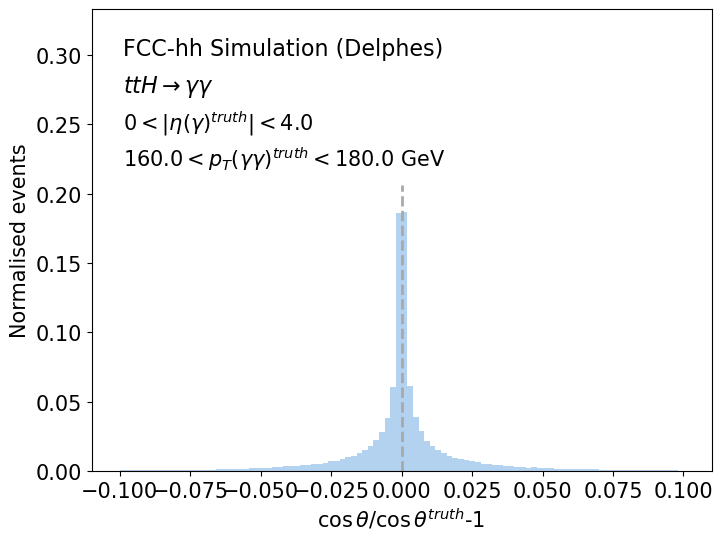

/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


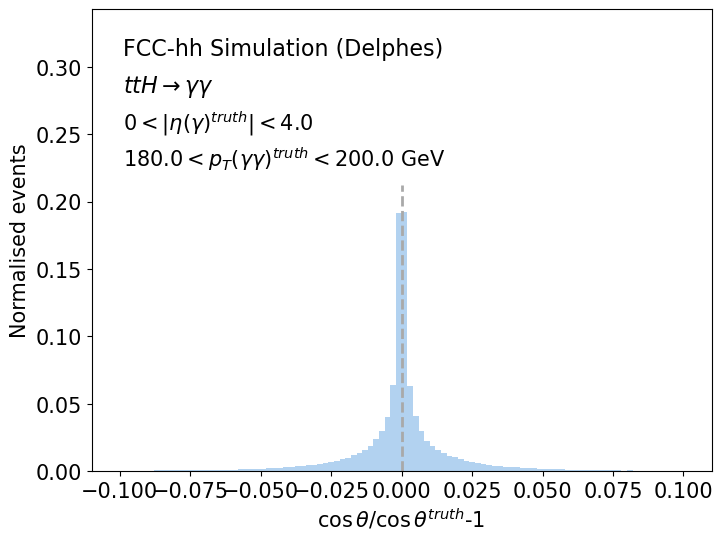

/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


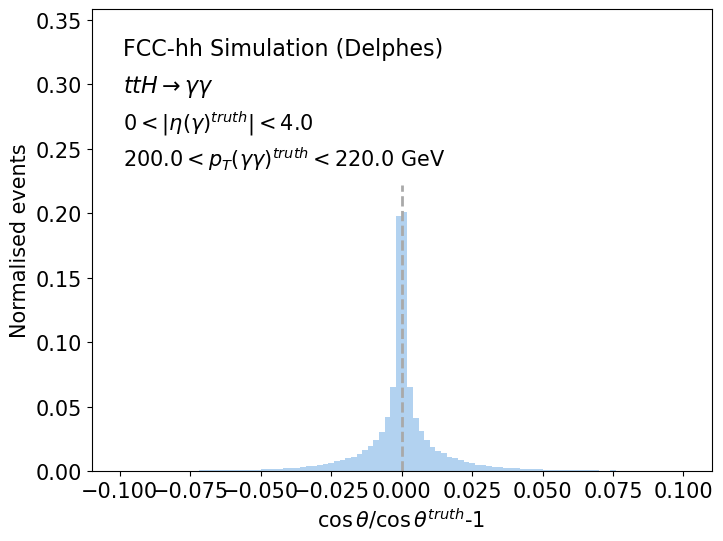

/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


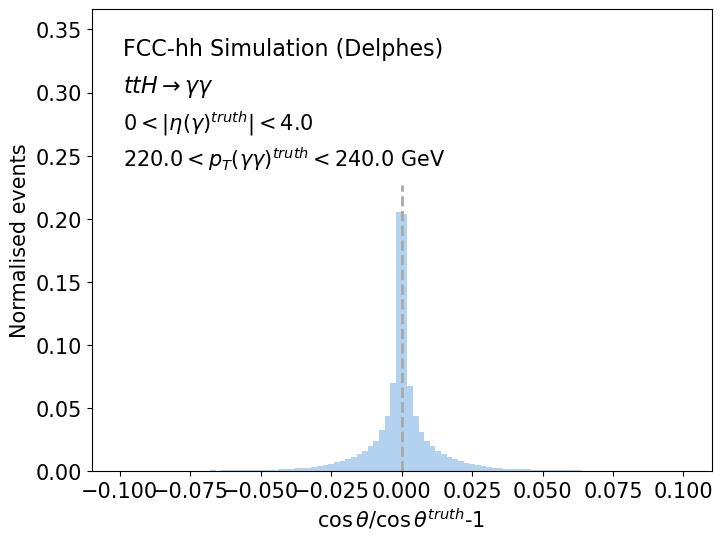

/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


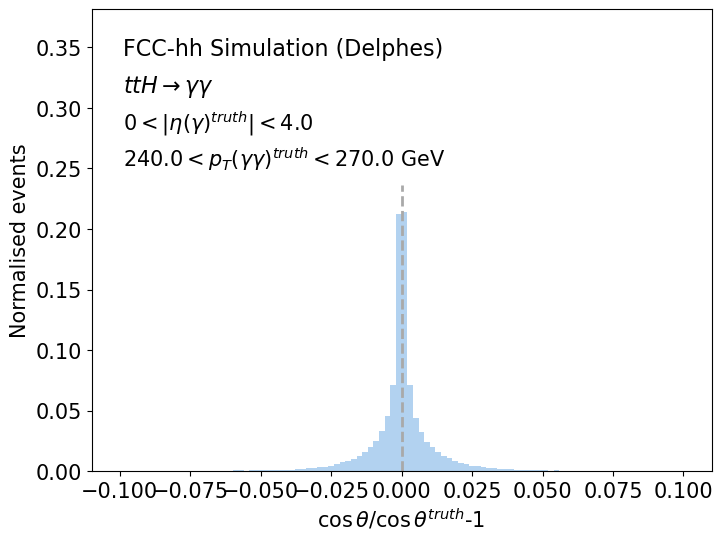

/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


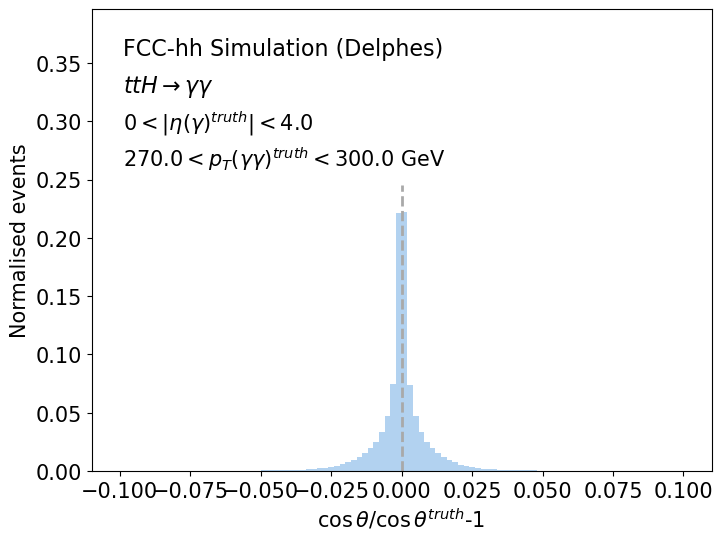

/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


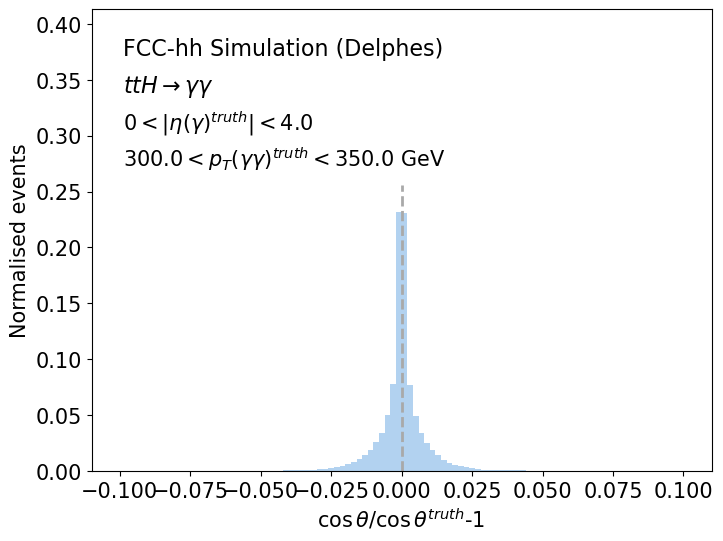

/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


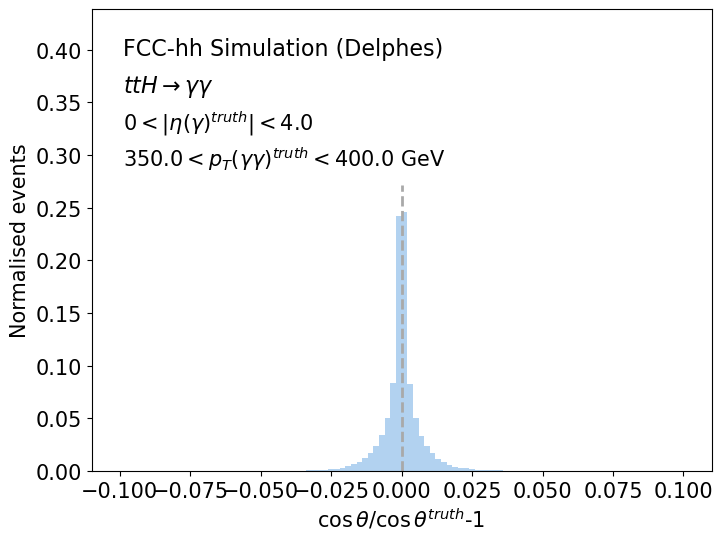

/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


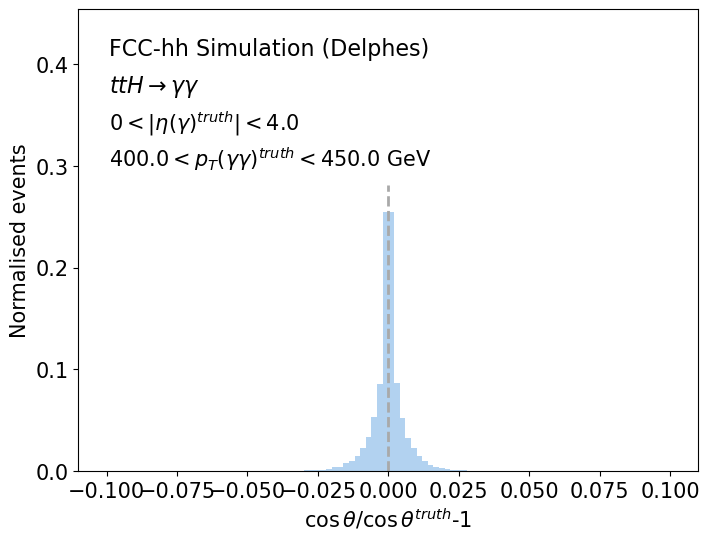

/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


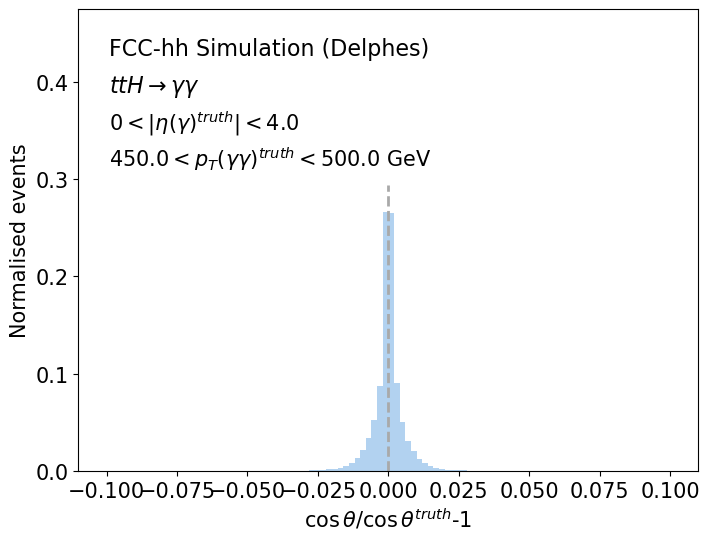

/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


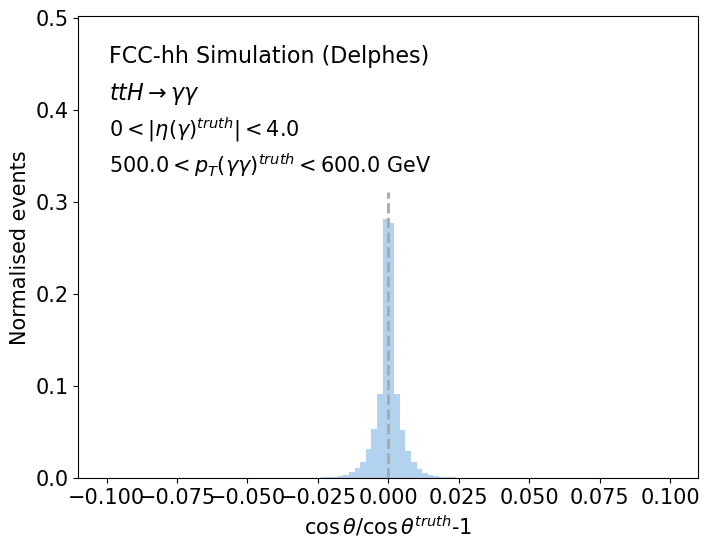

/tmp/elmazzeo/ipykernel_496224/620235003.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))


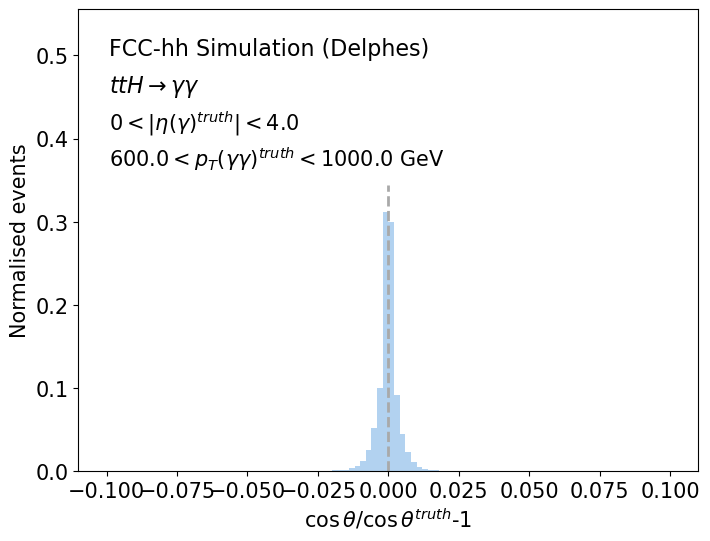

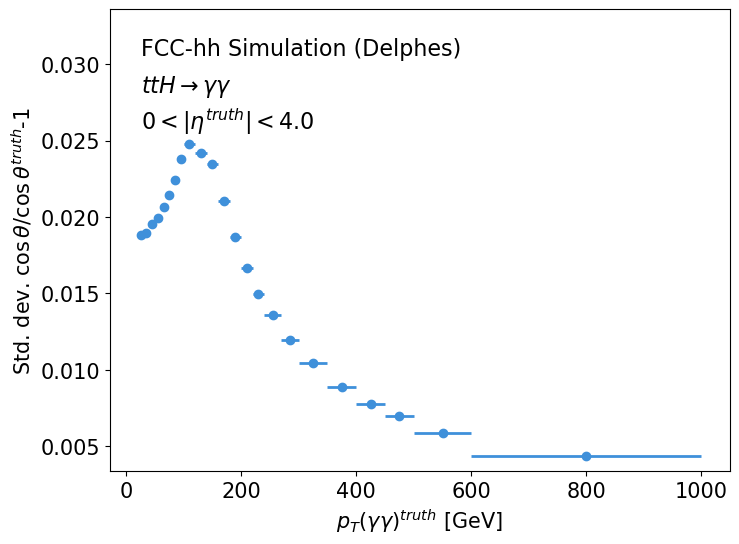

In [24]:
ENERGY_BINS = np.array([20, 30, 40, 50, 60, 70, 80, 90, 100,
                       120, 140, 160, 180, 200,
                       220, 240, 270, 300,
                       350, 400, 450, 500, 600, 1000], dtype=np.float64)
x = 0.5*(ENERGY_BINS[:-1] + ENERGY_BINS[1:])
xerr = 0.5*(ENERGY_BINS[1:] - ENERGY_BINS[:-1])

df1 = df[process_key][sel_key].query("(true_eta_y1<4.0) & (true_eta_y2<4.0)")

df1['energy_bin'] = np.digitize(np.abs(df1['true_pT_yy']), ENERGY_BINS)

y = np.zeros(len(ENERGY_BINS)-1)
for jbin in range(1, len(ENERGY_BINS)) :
    i_low = 0
    i_up = 4.0
    j_low = ENERGY_BINS[jbin-1]
    j_up = ENERGY_BINS[jbin] 
        
    df_all = df1[(df1['energy_bin']==jbin)]
    df_all["obs"] = df_all['cos_theta_y_y']/df_all['true_cos_theta_y_y']-np.ones(len(df_all))
    df_all = df_all.query("abs(obs)<0.1")
    observable = df_all["obs"].copy()
    resolution = np.std(observable)
    y[jbin-1] = resolution
    
    # E / Etrue -1
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(8,6)
    )
    ax.hist(observable, weights=df_all['weight']/df_all['weight'].sum(),
            bins=100, range=(-0.1,0.1), histtype='stepfilled', color=color_sequence[0], alpha=0.4)
    ax.axvline(0, ymin=0, ymax=0.62, color='darkgrey', ls='--', lw=2.)

    ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.82, process_label, transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.74, str(i_low)+"$<|\eta(\gamma)^{truth}|<$"+str(i_up), transform=ax.transAxes, fontsize=15)
    ax.text(0.05, 0.66, str(j_low)+"$<p_T(\gamma\gamma)^{truth}<$"+str(j_up)+" GeV", transform=ax.transAxes, fontsize=15)
    xlabel = r"$\cos\theta / \cos\theta^{truth}$-1"
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'Normalised events')

    ymin,ymax = ax.get_ylim() 
    ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.70)
    
    plotname = "costheta_over_truecostheta_central_photons_true_pT_yy_bin"+str(jbin)
    plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
    plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
    plt.show()        

fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

ax.errorbar(x, y, xerr=xerr, color=color_sequence[0], marker='o', lw=2, ls='none')

ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, process_label, transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.74, str(i_low)+"$<|\eta^{truth}|<$"+str(i_up), transform=ax.transAxes, fontsize=16)
xlabel = "$p_T(\gamma\gamma)^{truth}$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Std. dev. $\cos\theta / \cos\theta^{truth}$-1')

ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.35)
    
plotname = "costheta_over_truecostheta_central_photons_true_pT_yy"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()

/tmp/elmazzeo/ipykernel_496224/263640802.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['energy_bin'] = np.digitize(np.abs(df1['true_pT_yy']), ENERGY_BINS)
/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


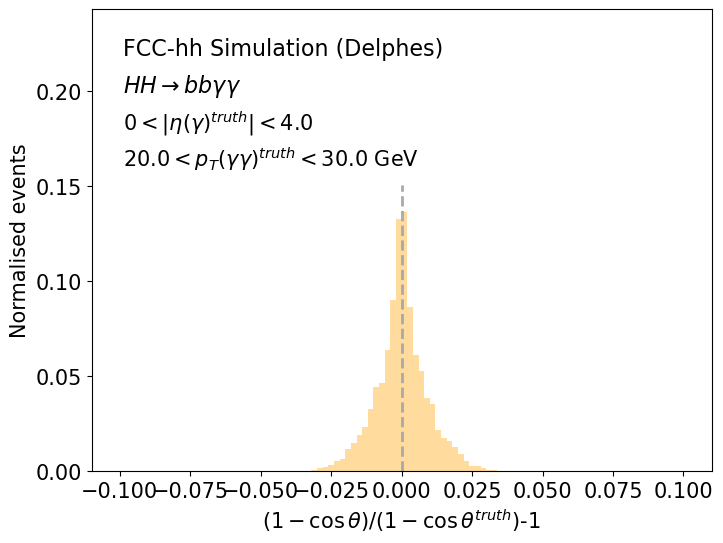

/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


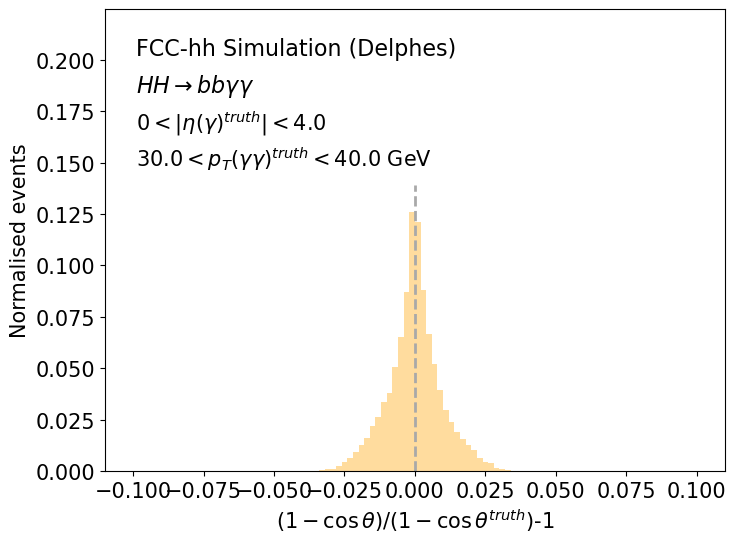

/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


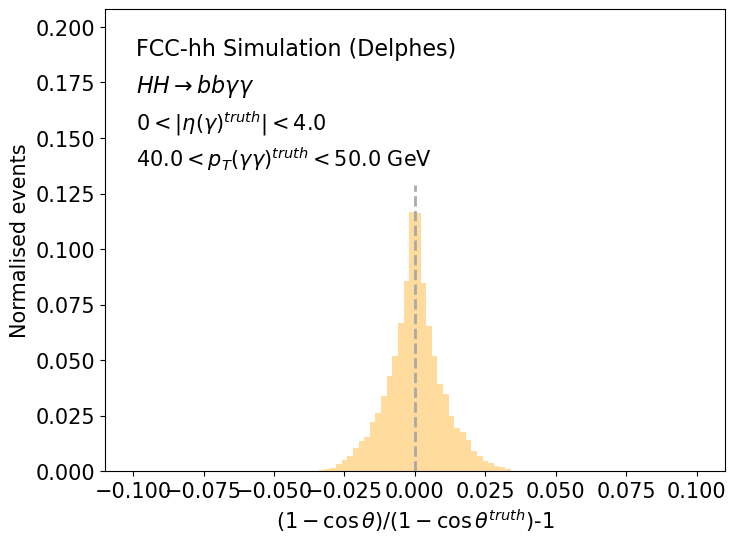

/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


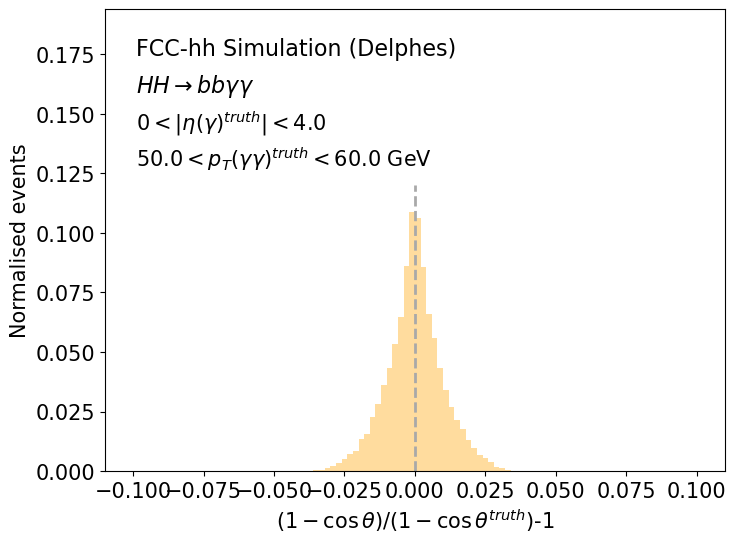

/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


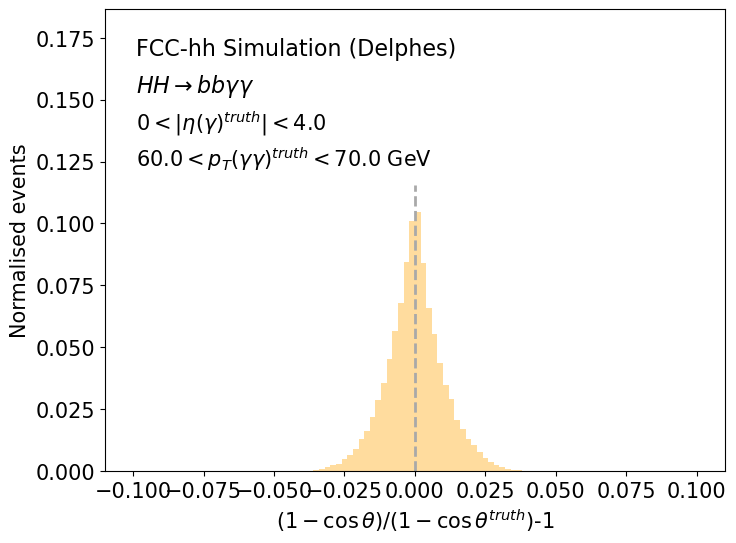

/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


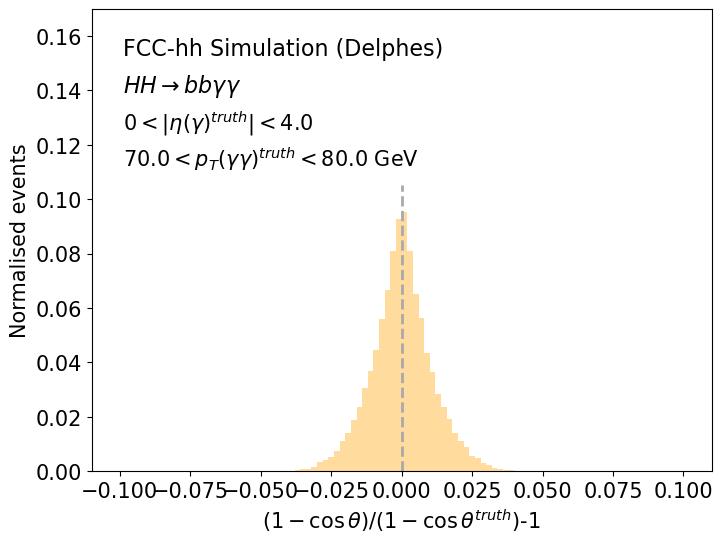

/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


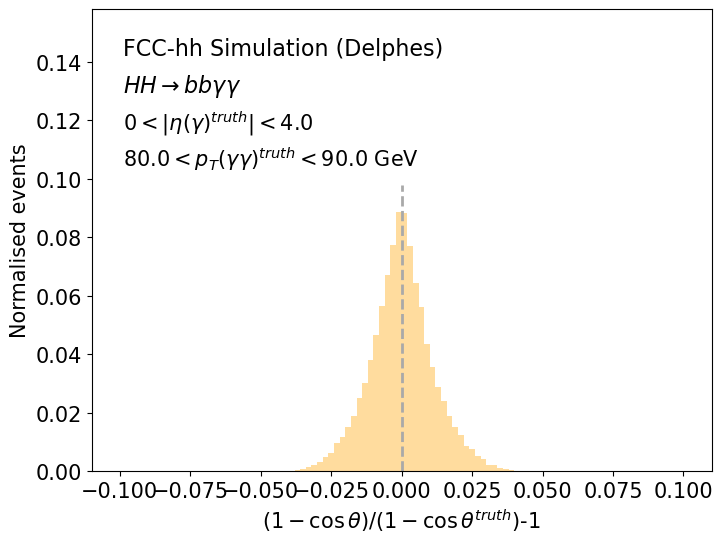

/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


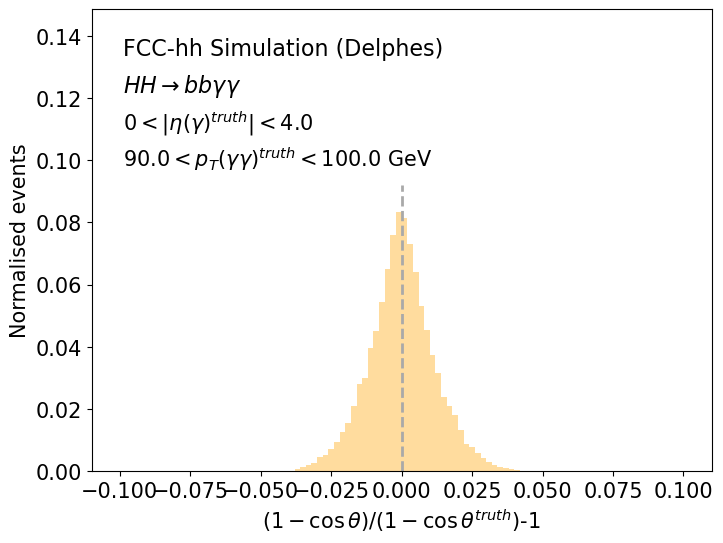

/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


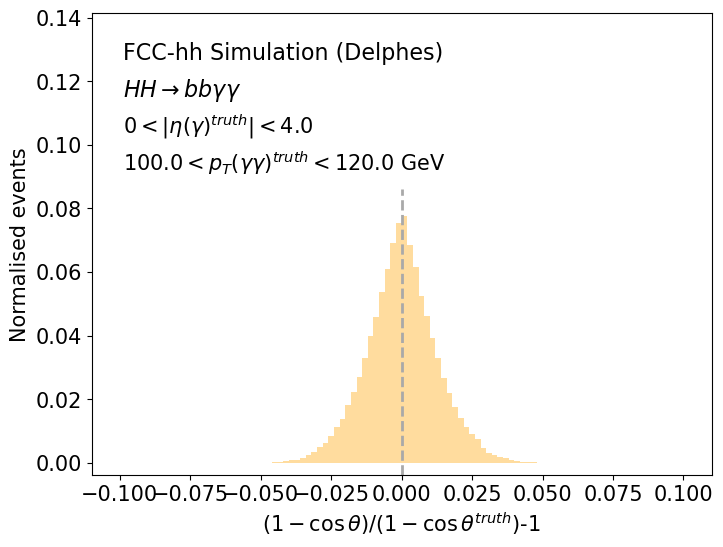

/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


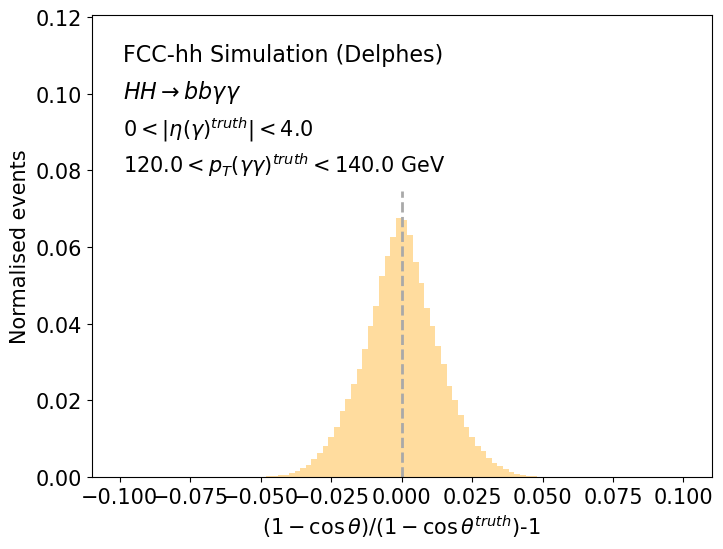

/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


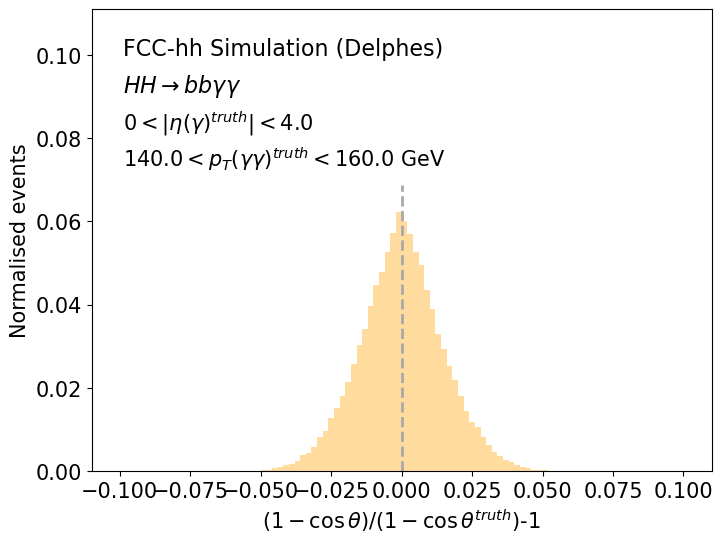

/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


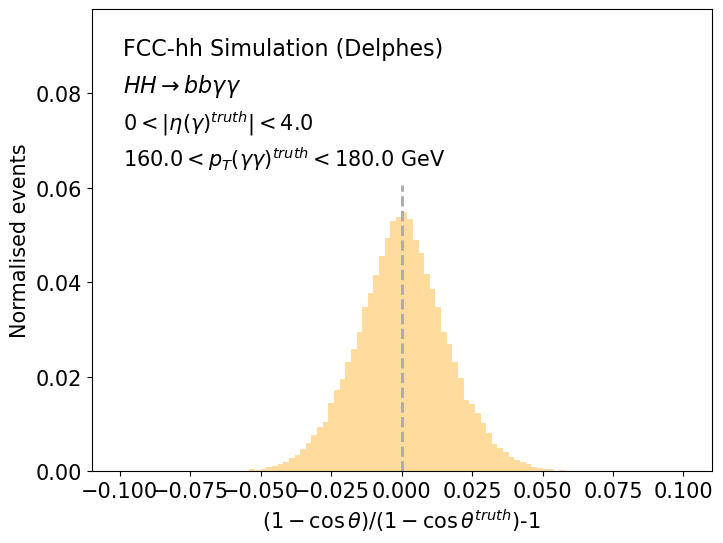

/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


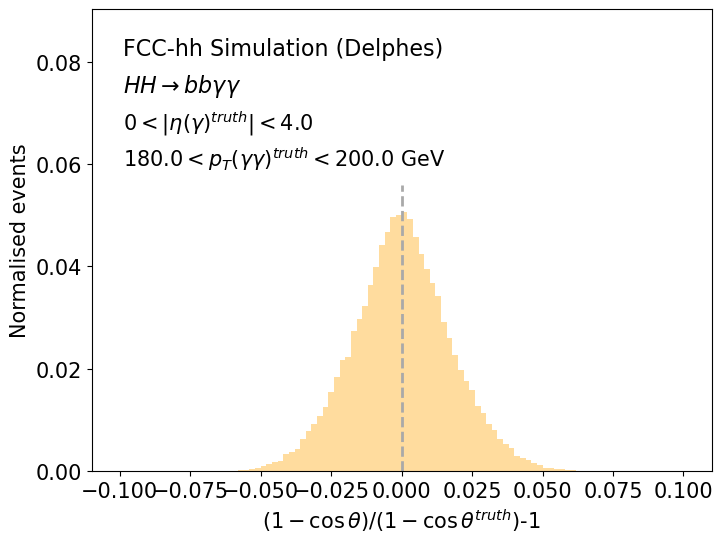

/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


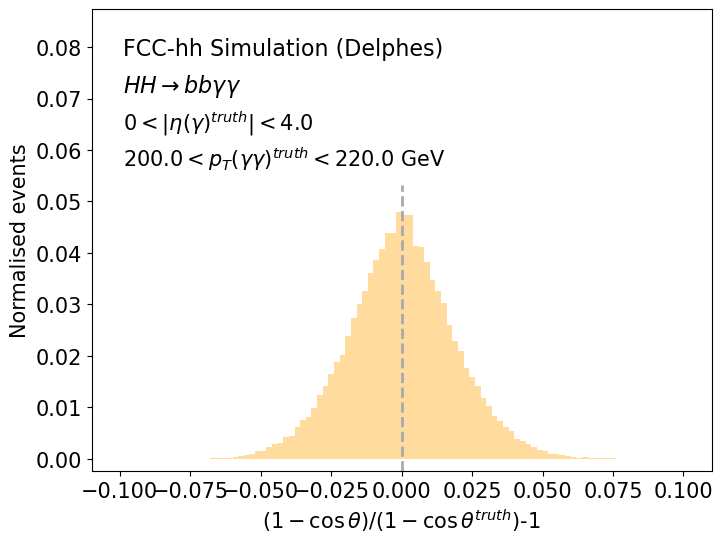

/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


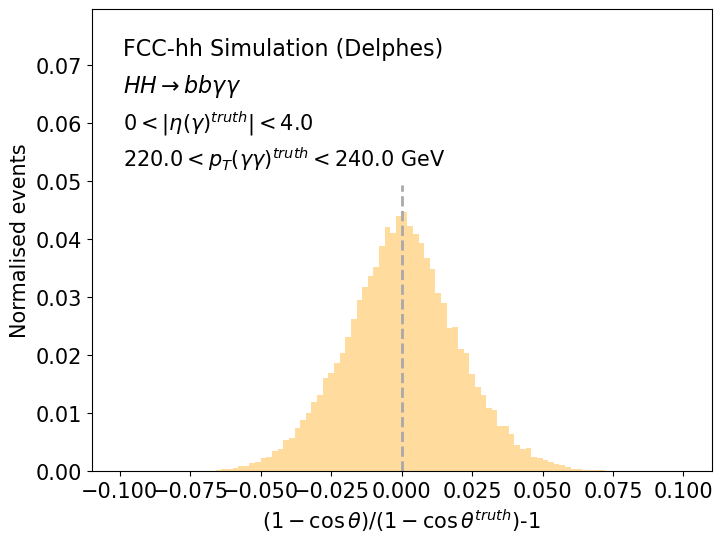

/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


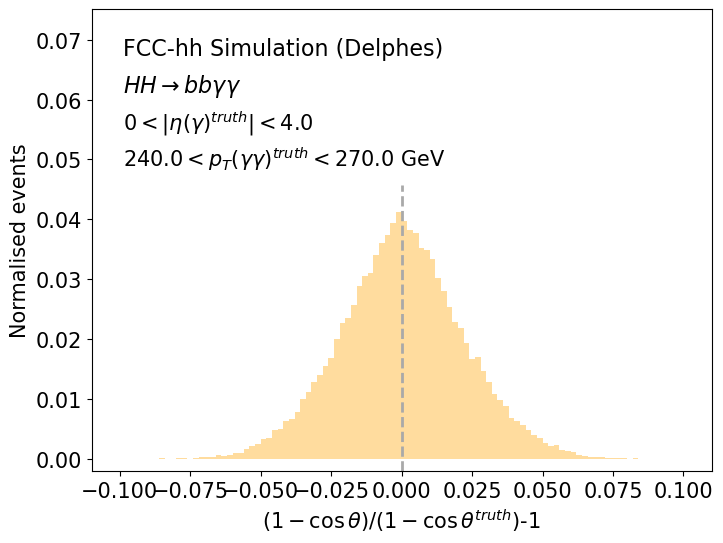

/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


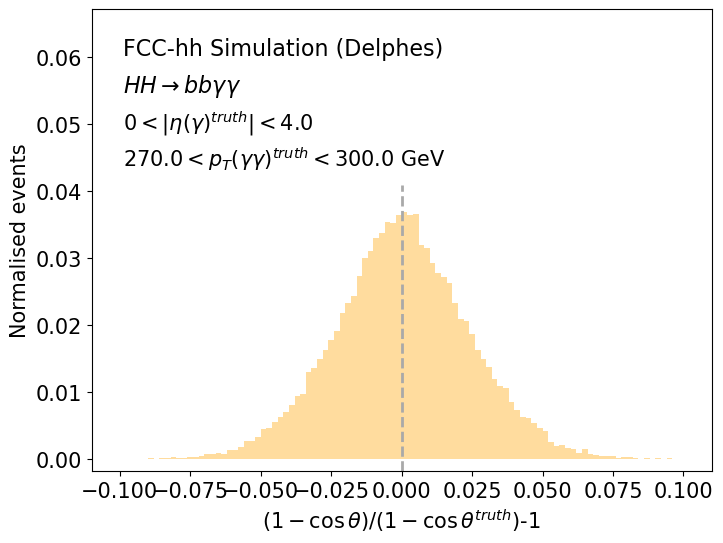

/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


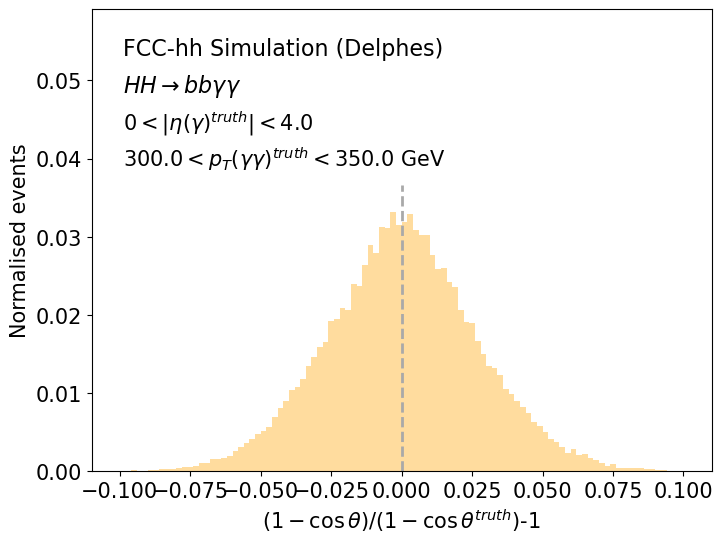

/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


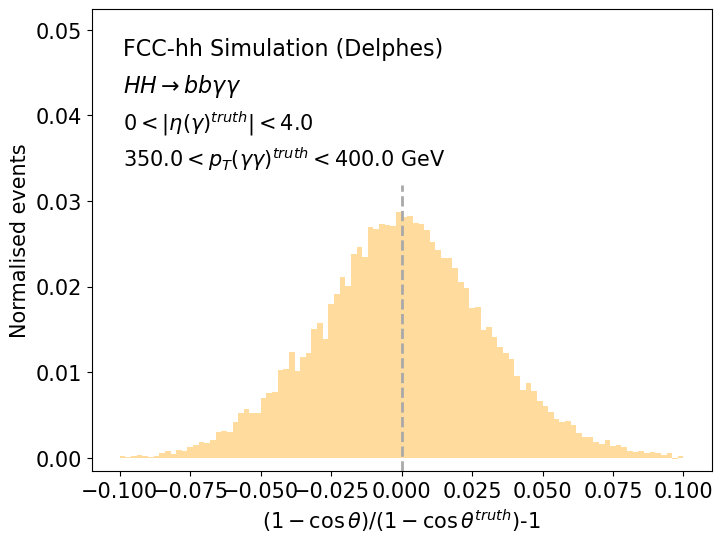

/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


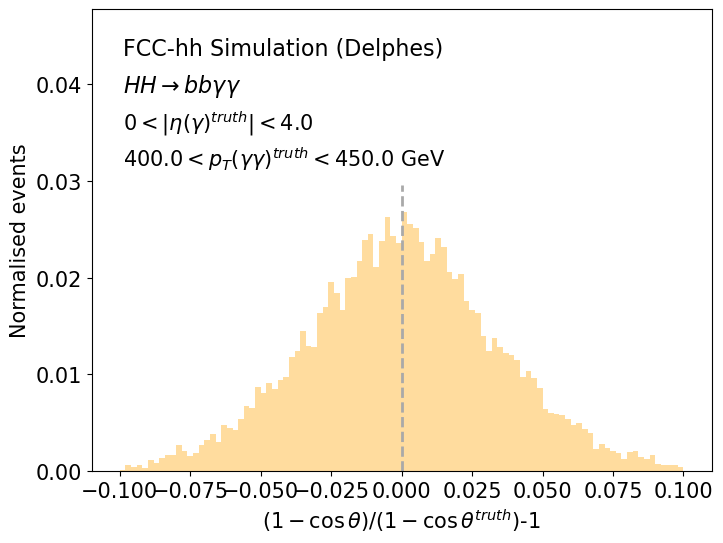

/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


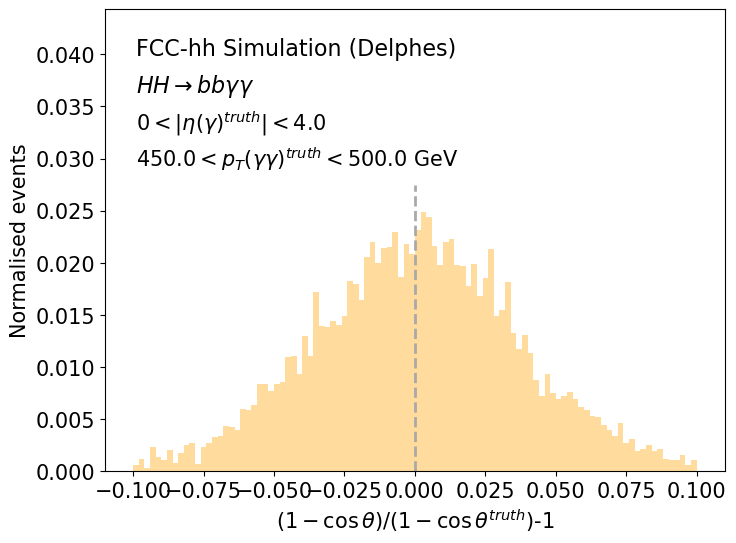

/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


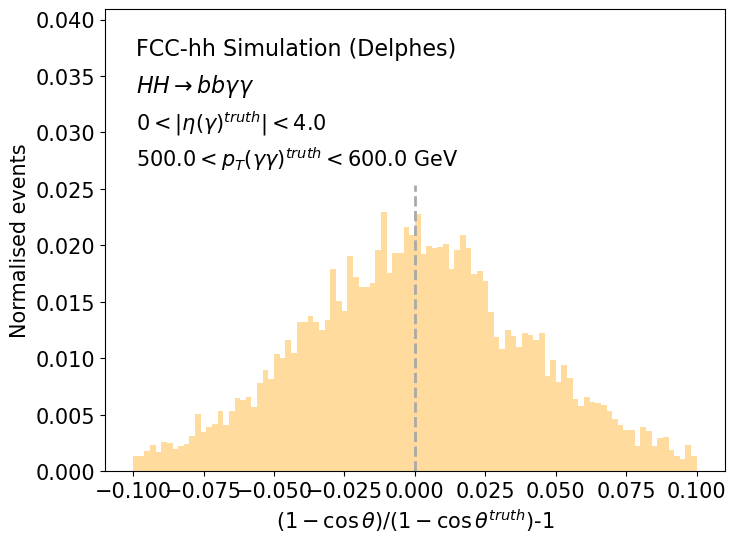

/tmp/elmazzeo/ipykernel_496224/263640802.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))


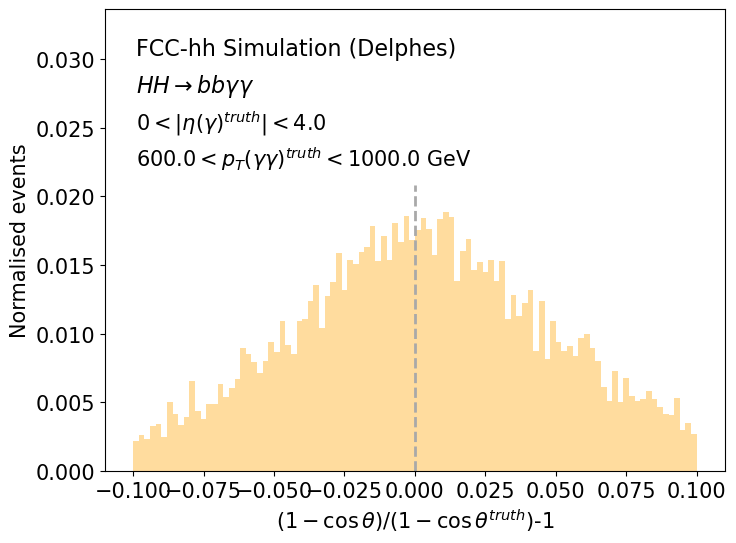

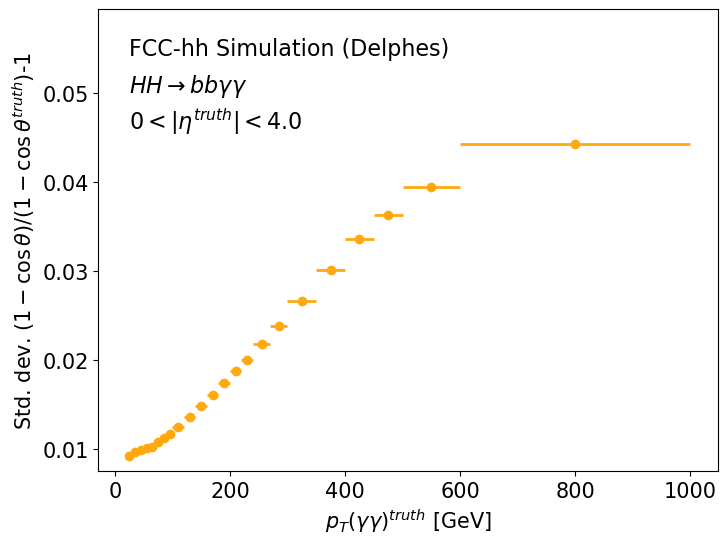

In [52]:
ENERGY_BINS = np.array([20, 30, 40, 50, 60, 70, 80, 90, 100,
                       120, 140, 160, 180, 200,
                       220, 240, 270, 300,
                       350, 400, 450, 500, 600, 1000], dtype=np.float64)
x = 0.5*(ENERGY_BINS[:-1] + ENERGY_BINS[1:])
xerr = 0.5*(ENERGY_BINS[1:] - ENERGY_BINS[:-1])

df1 = df[process_key][sel_key].query("(abs(true_eta_y1)<4.0) & (abs(true_eta_y2)<4.0)")

df1['energy_bin'] = np.digitize(np.abs(df1['true_pT_yy']), ENERGY_BINS)

y = np.zeros(len(ENERGY_BINS)-1)
for jbin in range(1, len(ENERGY_BINS)) :
    i_low = 0
    i_up = 4.0
    j_low = ENERGY_BINS[jbin-1]
    j_up = ENERGY_BINS[jbin] 
        
    df_all = df1[(df1['energy_bin']==jbin)]
    df_all["obs"] = (np.ones(len(df_all))-df_all['cos_theta_y_y'])/(np.ones(len(df_all))-df_all['true_cos_theta_y_y'])-np.ones(len(df_all))
    df_all = df_all.query("abs(obs)<0.1")
    observable = df_all["obs"].copy()
    resolution = np.std(observable)
    y[jbin-1] = resolution
    
    # E / Etrue -1
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(8,6)
    )
    ax.hist(observable, weights=df_all['weight']/df_all['weight'].sum(),
            bins=100, range=(-0.1,0.1), histtype='stepfilled', color=process_color, alpha=0.4)
    ax.axvline(0, ymin=0, ymax=0.62, color='darkgrey', ls='--', lw=2.)

    ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.82, process_label, transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.74, str(i_low)+"$<|\eta(\gamma)^{truth}|<$"+str(i_up), transform=ax.transAxes, fontsize=15)
    ax.text(0.05, 0.66, str(j_low)+"$<p_T(\gamma\gamma)^{truth}<$"+str(j_up)+" GeV", transform=ax.transAxes, fontsize=15)
    xlabel = r"$(1-\cos\theta )/ (1-\cos\theta^{truth})$-1"
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'Normalised events')

    ymin,ymax = ax.get_ylim() 
    ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.70)
    
    plotname = "invcostheta_over_invtruecostheta_hhbbyy_true_pT_yy_bin"+str(jbin)
    plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
    plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
    plt.show()        

fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

ax.errorbar(x, y, xerr=xerr, color=process_color, marker='o', lw=2, ls='none')

ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, process_label, transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.74, str(i_low)+"$<|\eta^{truth}|<$"+str(i_up), transform=ax.transAxes, fontsize=16)
xlabel = "$p_T(\gamma\gamma)^{truth}$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Std. dev. $(1-\cos\theta) / (1-\cos\theta^{truth})$-1')

ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.35)
    
plotname = "invcostheta_over_invtruecostheta_hhbbyy_true_pT_yy"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()

In [33]:
df1["inv_cos_theta_y_y"] = np.ones(len(df1)) - df1["cos_theta_y_y"]

<Axes: >

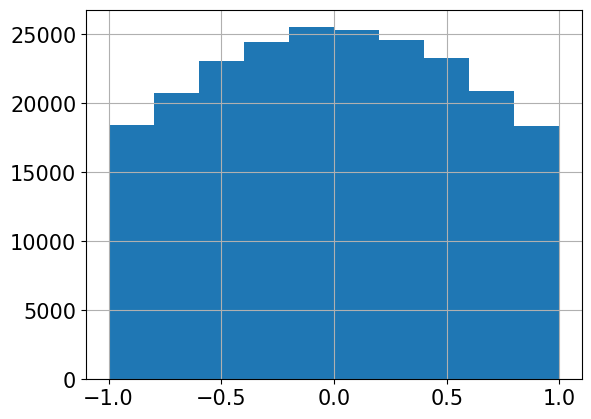

In [38]:
df1["eta_y1"].hist()

/tmp/elmazzeo/ipykernel_496224/3110045778.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['check'] = np.sqrt(2*df1['E_y1']*df1['E_y2']*(1-df1['cos_theta_y_y']))


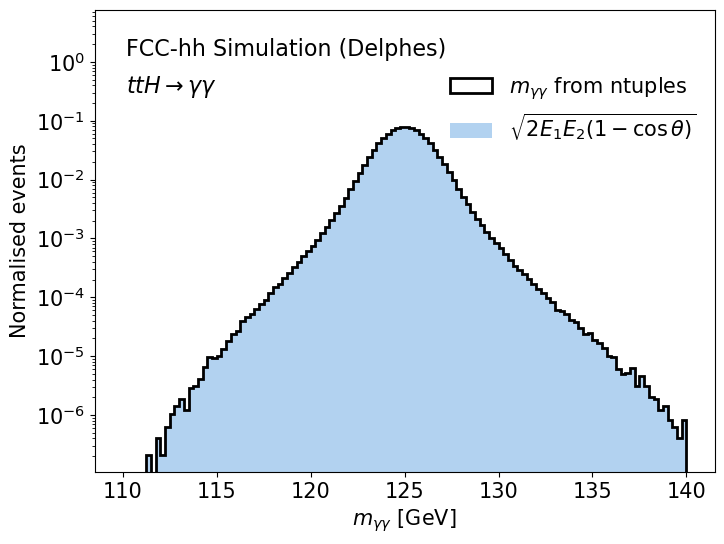

In [26]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

df1['check'] = np.sqrt(2*df1['E_y1']*df1['E_y2']*(1-df1['cos_theta_y_y']))

ax.hist(df1['m_yy'], weights=df1['weight']/df1['weight'].sum(),
        bins=120, range=(110,140), histtype='step', lw=2, color='k', alpha=1,
       label="$m_{\gamma\gamma}$ from ntuples")
ax.hist(df1['check'], weights=df1['weight']/df1['weight'].sum(),
        bins=120, range=(110,140), histtype='stepfilled', lw=2, color=color_sequence[0], alpha=0.4,
       label=r"$\sqrt{2E_1E_2(1-\cos\theta)}$")

ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, process_label, transform=ax.transAxes, fontsize=16)
xlabel = r"$m_{\gamma\gamma}$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Normalised events')

ax.legend(loc='upper right', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 0.90))

ax.set_yscale("log")
ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*50.)
    
plotname = "m_yy_theta_check"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()   

/tmp/elmazzeo/ipykernel_496224/1554422743.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['check1'] = np.sqrt(2*df1['true_E_y1']*df1['true_E_y2']*(1-df1['true_cos_theta_y_y']))
/tmp/elmazzeo/ipykernel_496224/1554422743.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['check'] = np.sqrt(2*df1['E_y1']*df1['E_y2']*(1-df1['cos_theta_y_y']))


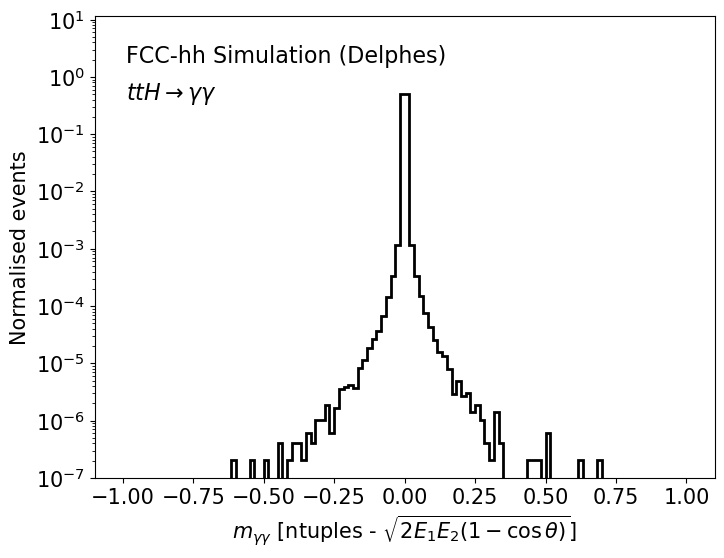

In [32]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

df1['check1'] = np.sqrt(2*df1['true_E_y1']*df1['true_E_y2']*(1-df1['true_cos_theta_y_y']))
df1['check'] = np.sqrt(2*df1['E_y1']*df1['E_y2']*(1-df1['cos_theta_y_y']))

ax.hist(df1['m_yy']-df1['check'], weights=df1['weight']/df1['weight'].sum(),
        bins=120, range=(-1,1), histtype='step', lw=2, color='k', alpha=1)
        
ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, process_label, transform=ax.transAxes, fontsize=16)
xlabel = r"$m_{\gamma\gamma}$ [ntuples - $\sqrt{2E_1E_2(1-\cos\theta)}$]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Normalised events')

ax.set_yscale("log")
ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*10)
    
plotname = "m_yy_theta_check"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()   

In [84]:
df1['test'] = df1['m_yy']-df1['check']

/tmp/elmazzeo/ipykernel_2884975/908256742.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['test'] = df1['m_yy']-df1['check']


In [92]:
df2.head(100)

,E_y1,pT_y1,eta_y1,true_E_y1,true_pT_y1,true_eta_y1,E_y2,pT_y2,eta_y2,true_E_y2,...,true_pT_yy,theta_y_y,cos_theta_y_y,true_theta_y_y,true_cos_theta_y_y,true_m_yy,weight,energy_bin,check,test
35934,10554.726562,377.559967,-4.023427,10442.198278,374.611517,-4.020546,735.250366,40.039570,-3.602748,736.472918,...,398.516672,0.045958,0.998944,0.045079,0.998984,124.999999,1.0,19,128.015946,0.222961
45169,17427.628906,254.297836,-4.920400,17381.221106,251.843159,-4.927434,364.053711,22.592833,-3.471852,365.249783,...,273.308561,0.048791,0.998810,0.049616,0.998769,125.000000,1.0,17,122.885063,0.536118
166559,17076.365234,209.772186,-5.092538,16961.987802,210.810303,-5.080880,665.031921,25.491131,-3.954284,668.799960,...,218.786048,0.037022,0.999315,0.037115,0.999311,125.000002,1.0,14,124.754952,0.221847
193294,15359.796875,208.435425,-4.992980,14984.081596,202.234207,-4.998419,3372.385010,91.831558,-4.296381,3399.264269,...,284.563522,0.017598,0.999845,0.017515,0.999847,124.999996,1.0,17,126.657131,0.248829
227320,19701.937500,201.480621,-5.275900,19525.158365,201.447182,-5.267052,387.410736,18.710217,-3.722980,389.119325,...,208.146084,0.046046,0.998940,0.045353,0.998972,124.999995,1.0,14,127.201736,0.621201
244804,16146.433594,547.206482,-4.077488,15572.085195,528.873415,-4.075345,2413.326416,54.791794,-4.478239,2288.664430,...,571.365436,0.021238,0.999774,0.020939,0.999781,124.999997,1.0,22,132.569794,0.575332
264293,10225.039062,94.162354,-5.380700,10353.558927,94.790223,-5.386546,2724.512695,55.504868,-4.586617,2847.267387,...,105.547821,0.023169,0.999732,0.023023,0.999735,125.000000,1.0,9,122.283783,0.250762
279886,4127.122559,87.281090,-4.549237,4201.215555,87.947170,-4.559430,10709.260742,60.613064,-5.867493,10031.783792,...,123.223885,0.019543,0.999809,0.019255,0.999815,125.000002,1.0,10,129.924728,0.228531
401038,12385.291992,240.626328,-4.634072,12444.899891,242.294000,-4.631967,913.524109,49.946259,-3.598761,915.758292,...,290.487050,0.036774,0.999324,0.037030,0.999314,125.000001,1.0,17,123.689117,0.268441
405931,12128.578125,72.929466,-5.806965,11543.432293,68.753771,-5.816479,7051.750977,68.025490,-5.334273,7079.248077,...,65.542816,0.013844,0.999904,0.013828,0.999904,125.000001,1.0,5,128.027991,0.303995


In [89]:
df2 = df1.query('test>0.2')

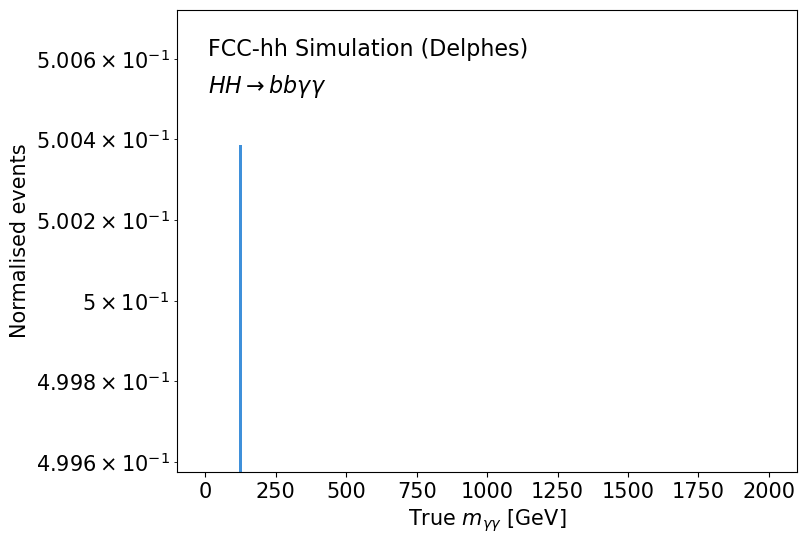

In [44]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

ax.hist(df1['true_m_yy'], weights=df1['weight']/df1['weight'].sum(),
        bins=10000, range=(0,2000), histtype='step', lw=2, color=color_sequence[0], alpha=1)
        
ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, process_label, transform=ax.transAxes, fontsize=16)
xlabel = r"True $m_{\gamma\gamma}$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Normalised events')

ax.set_yscale("log")
ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.35)
    
plotname = "true_m_yy"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()   

In [66]:
# myy check
df1['check'] = np.sqrt(2*df1['E_y1']*df1['E_y2']*(1-df1['cos_theta_y_y']))

/tmp/elmazzeo/ipykernel_2884975/3620623655.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['check'] = np.sqrt(2*df1['E_y1']*df1['E_y2']*(1-df1['cos_theta_y_y']))


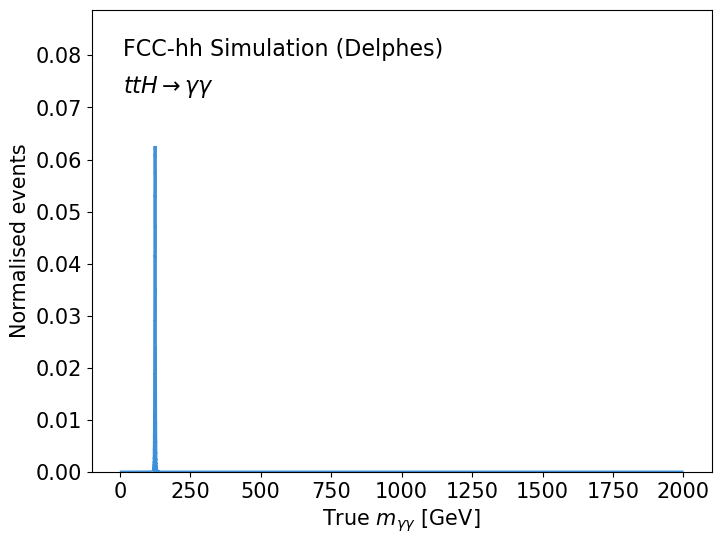

In [69]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

ax.hist(df1['check'], weights=df1['weight']/df1['weight'].sum(),
        bins=10000, range=(0,2000), histtype='step', lw=2, color=color_sequence[0], alpha=1)
        
ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, process_label, transform=ax.transAxes, fontsize=16)
xlabel = r"True $m_{\gamma\gamma}$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Normalised events')

ax.set_yscale("log")
ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.35)
    
plotname = "m_yy_check"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()   

In [60]:
ANGLE_BINS = np.linspace(0, np.pi, 50)
x = 0.5*(ANGLE_BINS[:-1] + ANGLE_BINS[1:])
xerr = 0.5*(ANGLE_BINS[1:] - ANGLE_BINS[:-1])

df1 = df[process_key][sel_key].copy()

df1['angle_bin'] = np.digitize(np.abs(df1['true_theta_y_y']), ANGLE_BINS)

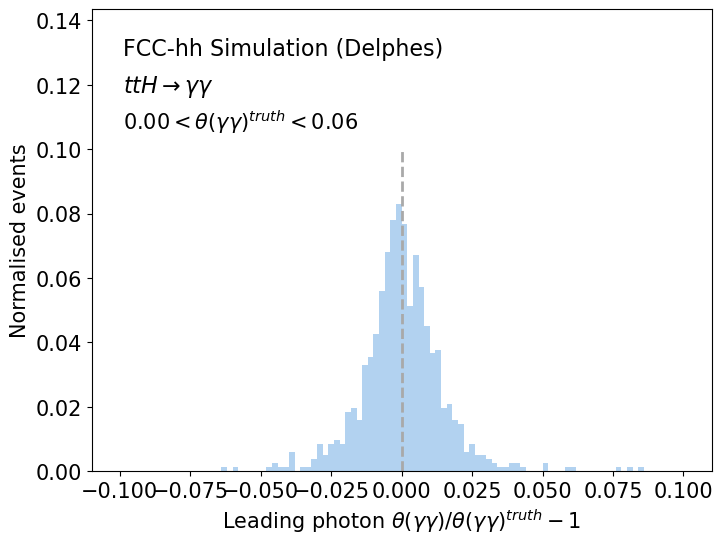

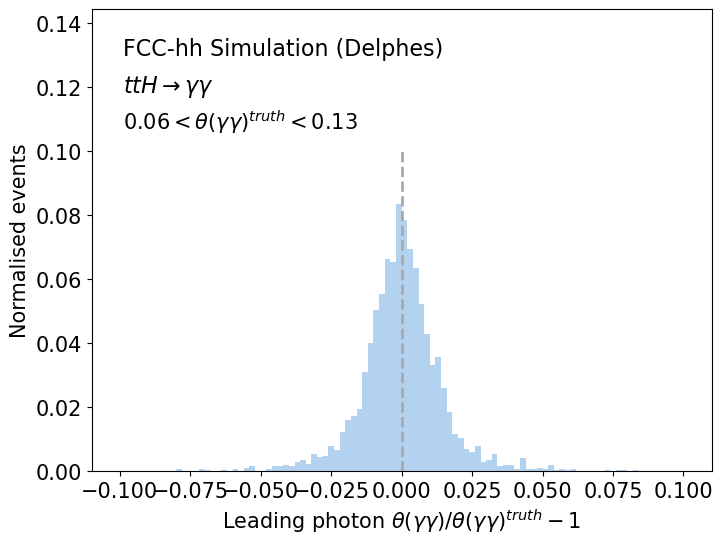

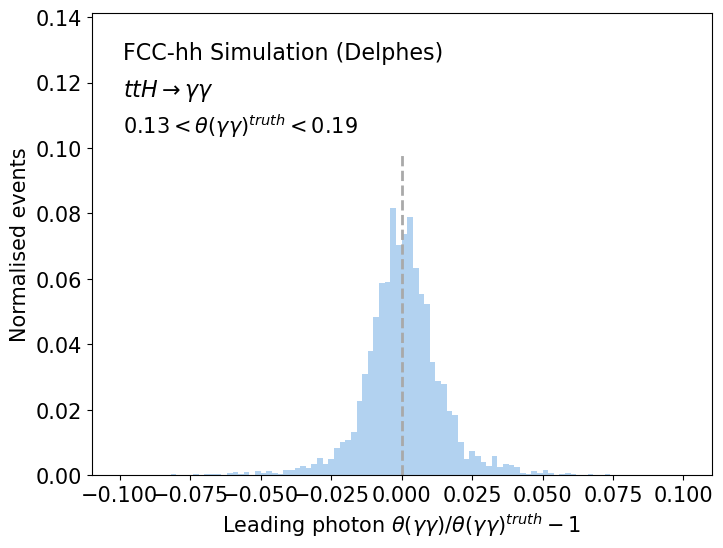

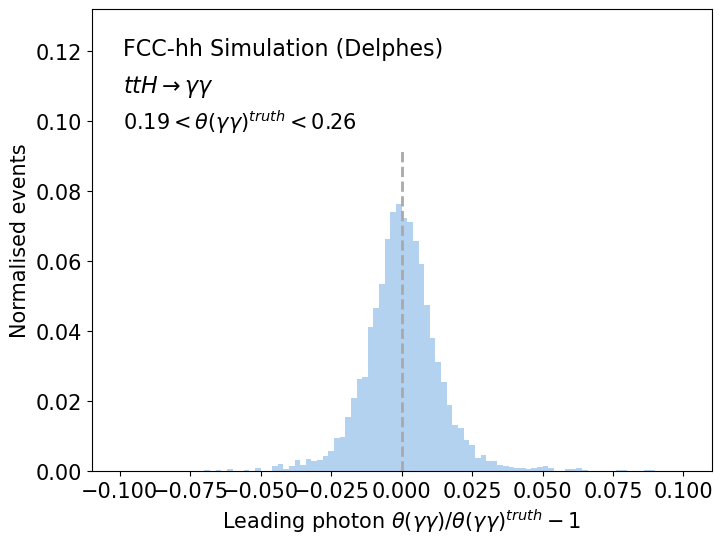

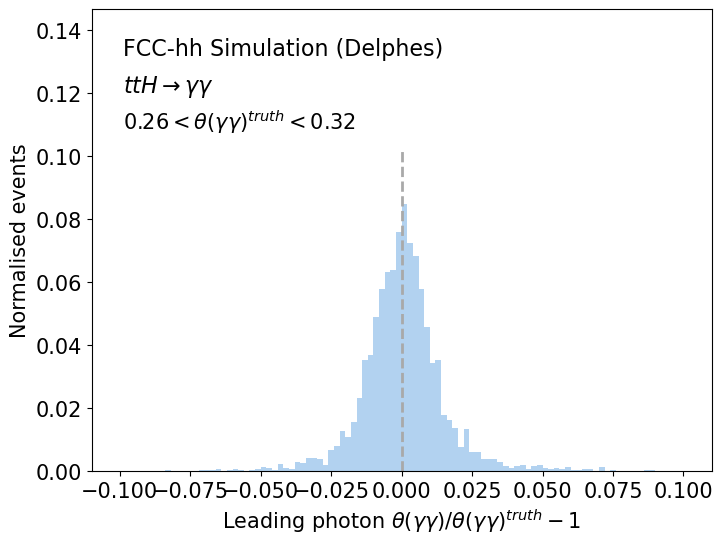

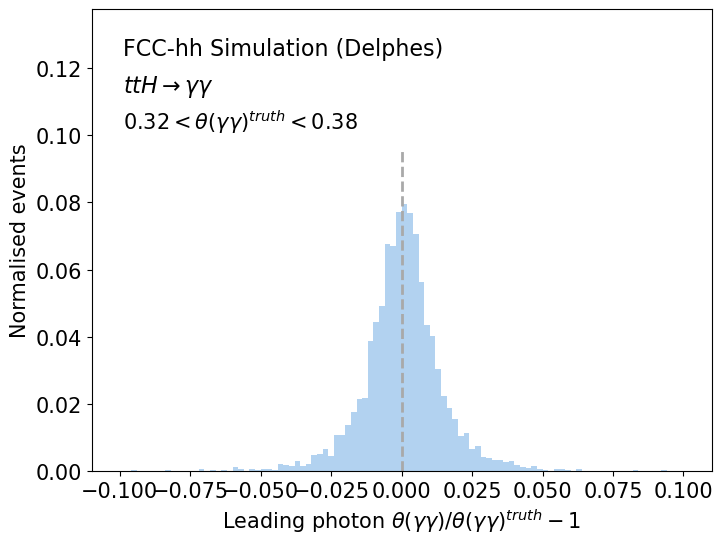

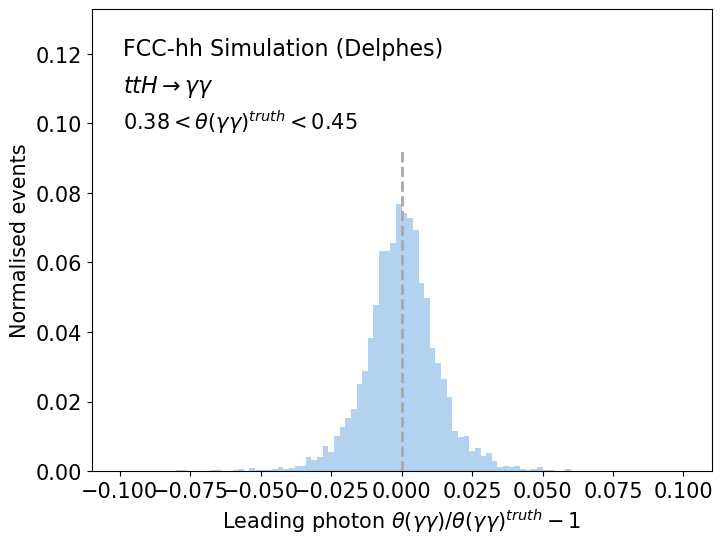

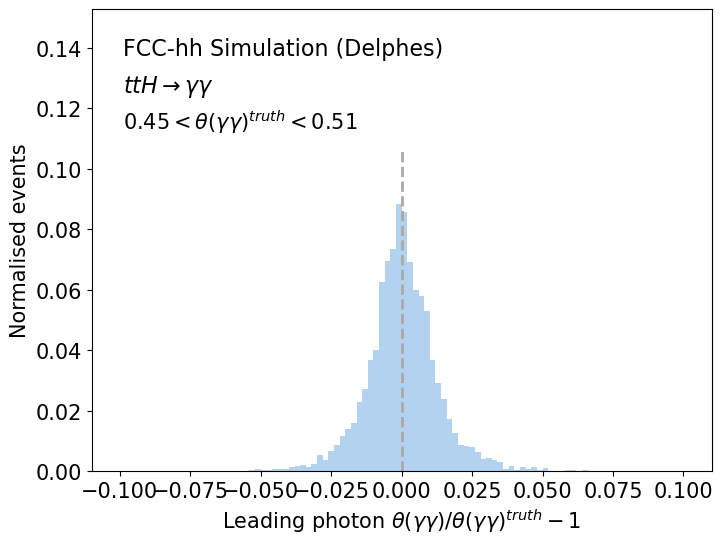

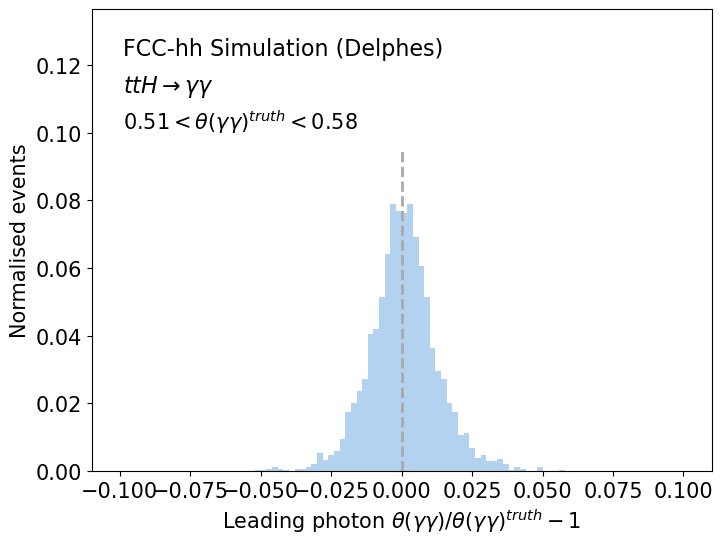

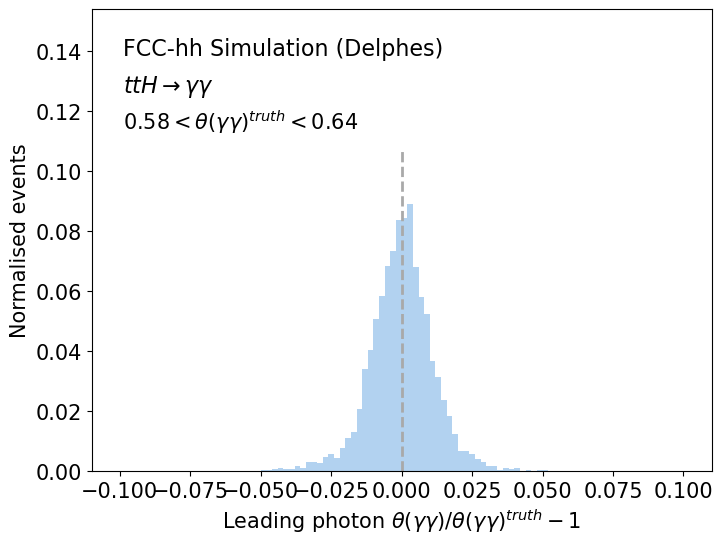

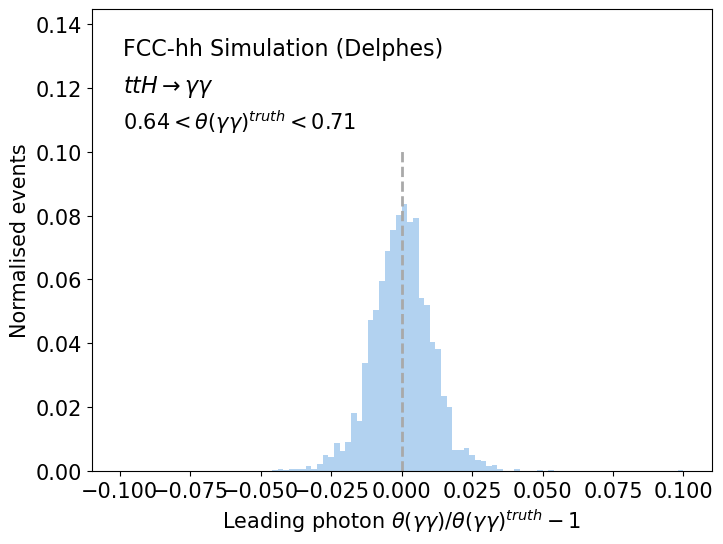

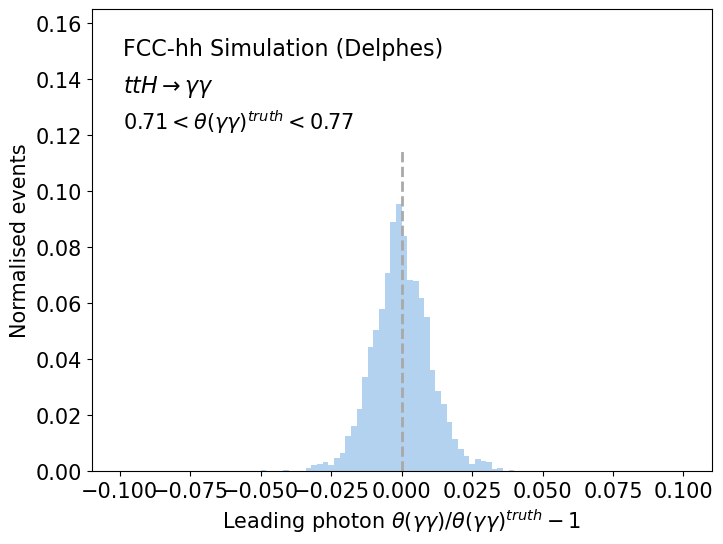

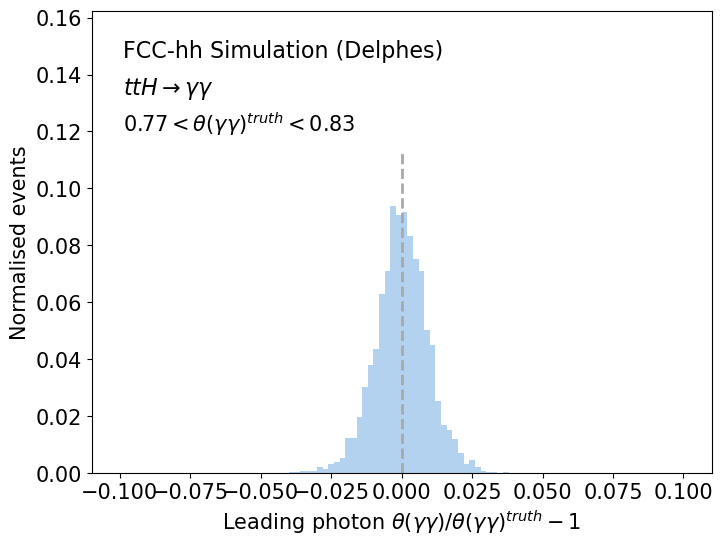

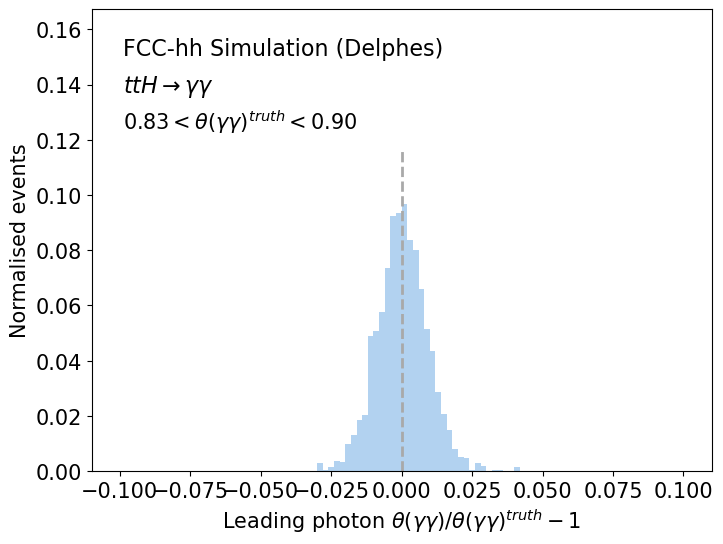

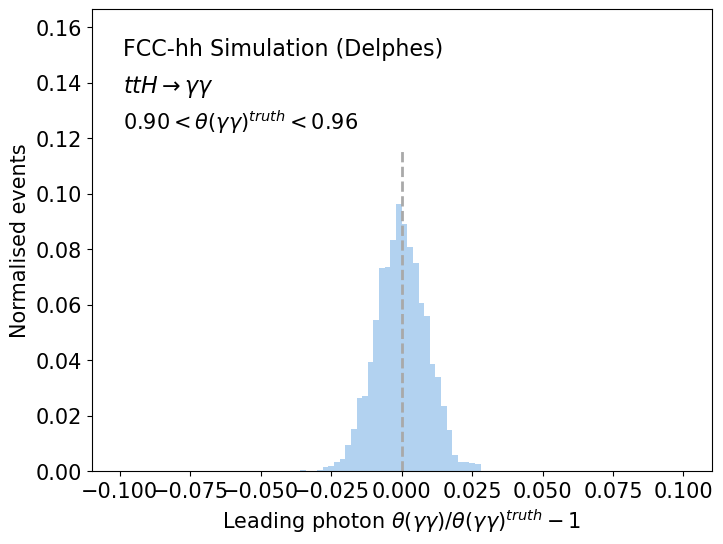

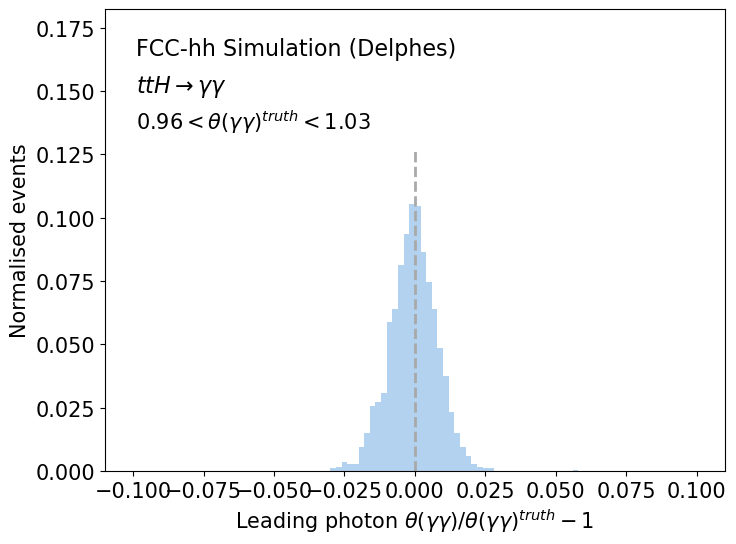

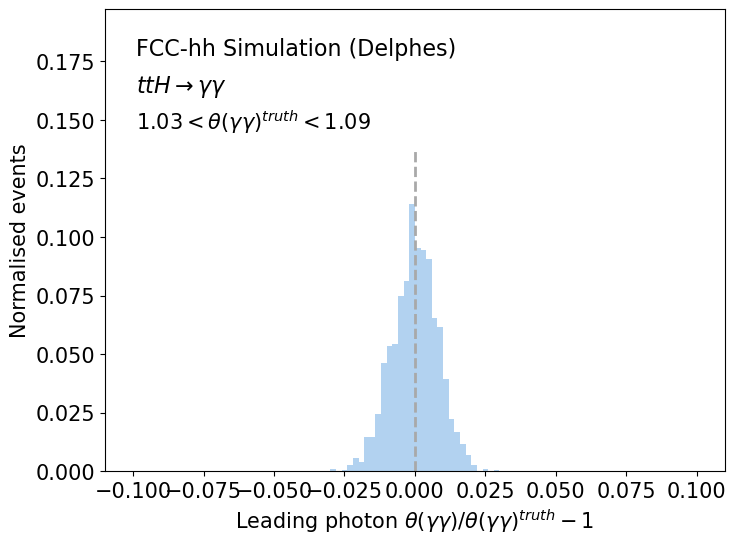

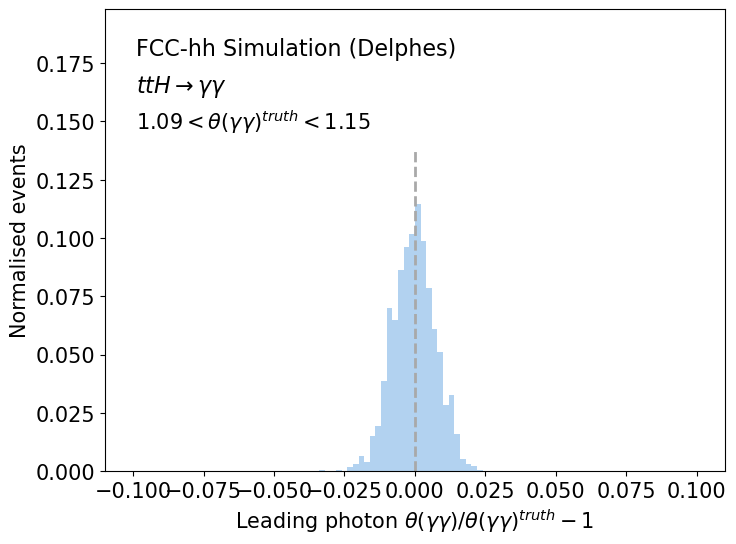

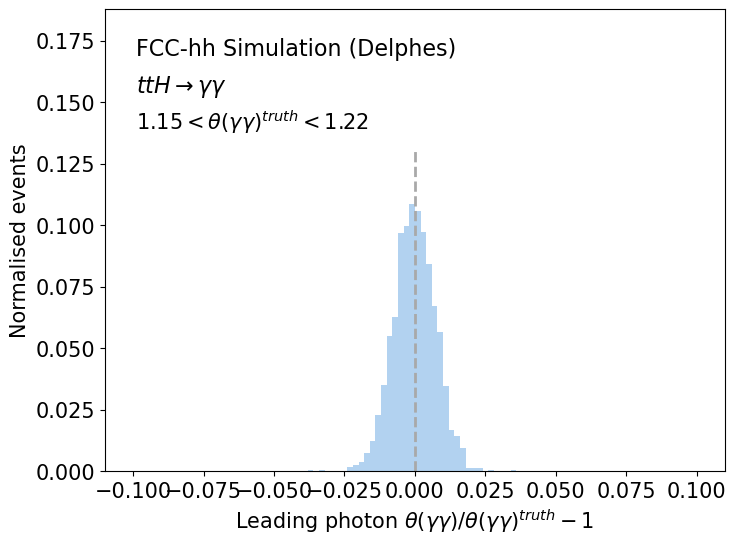

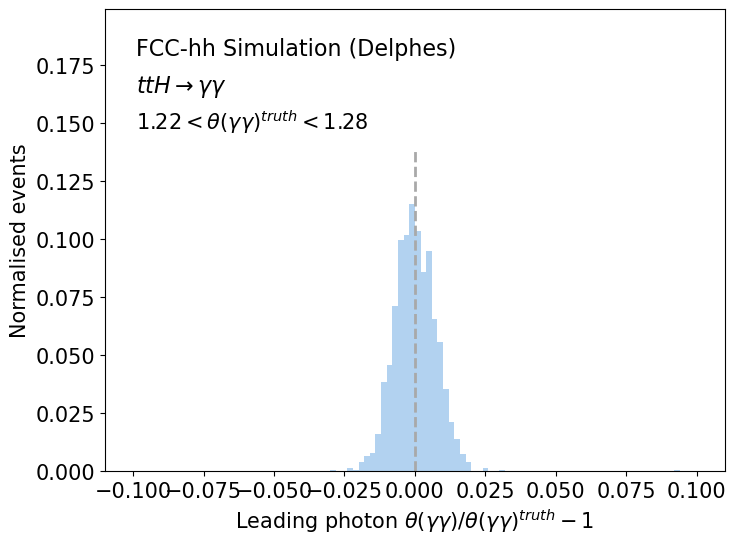

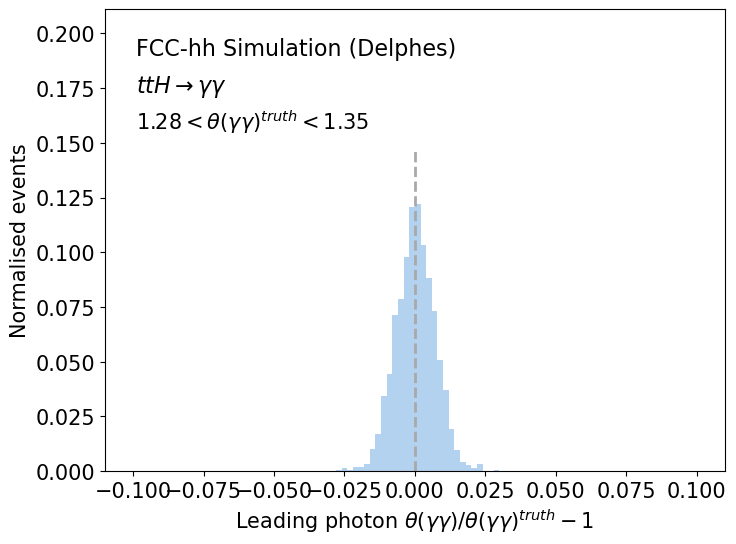

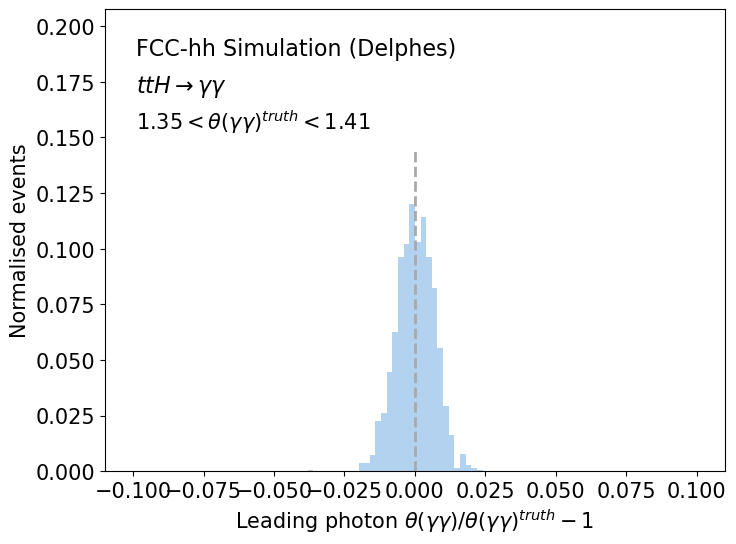

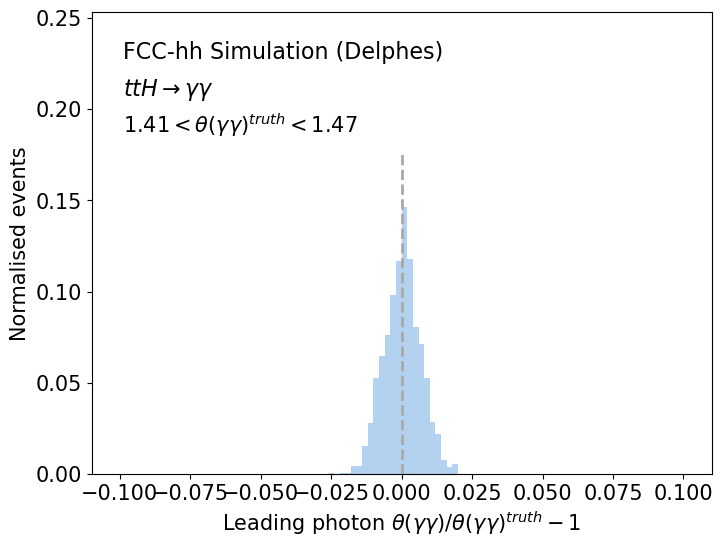

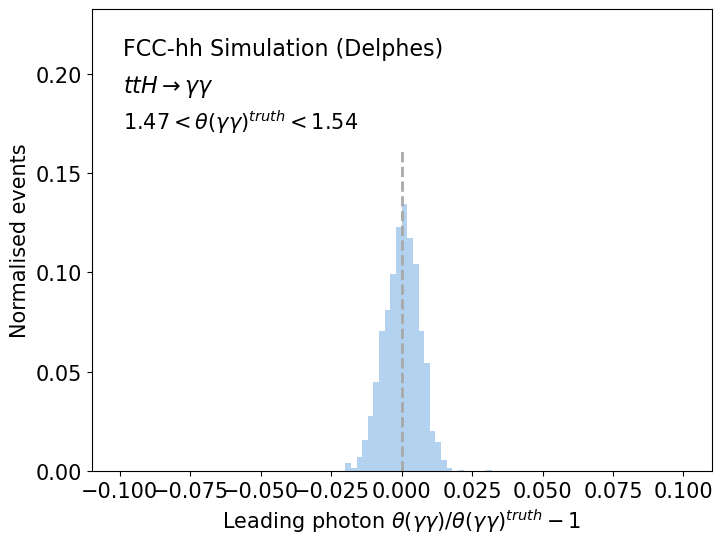

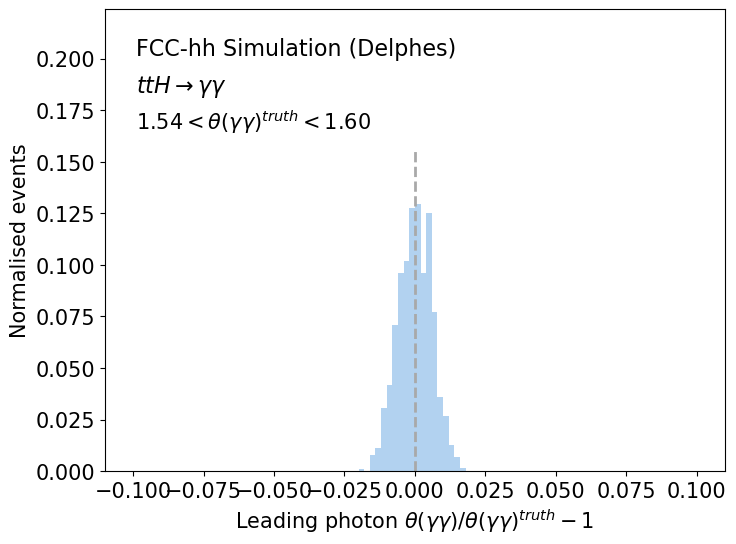

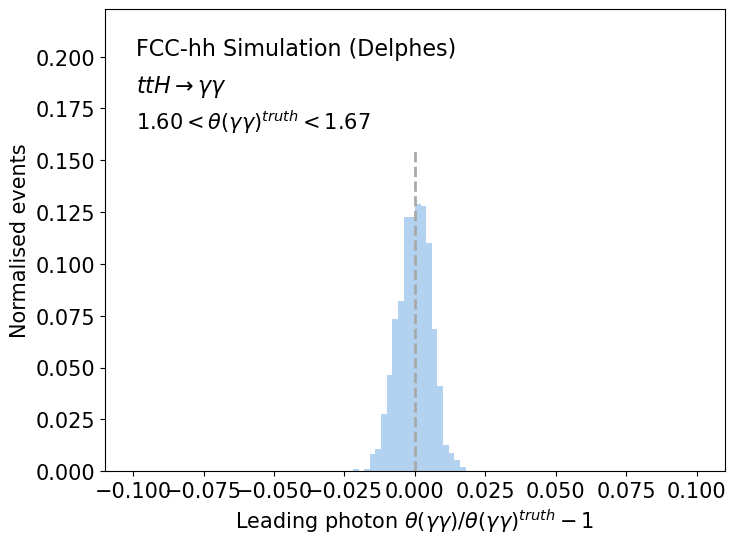

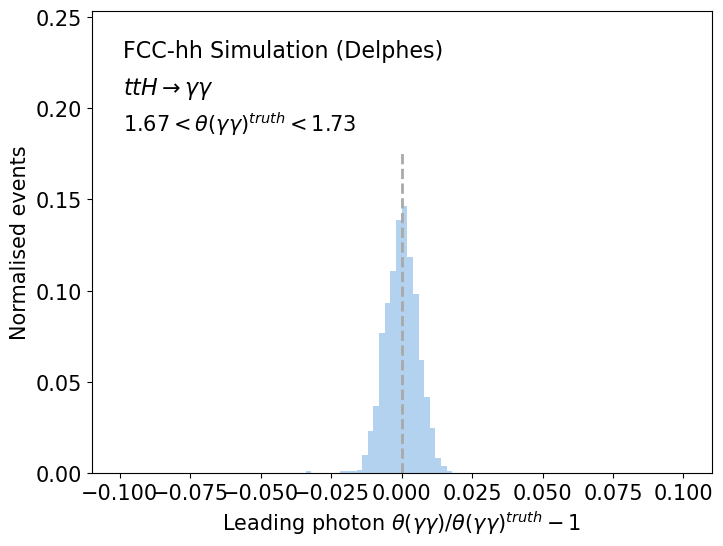

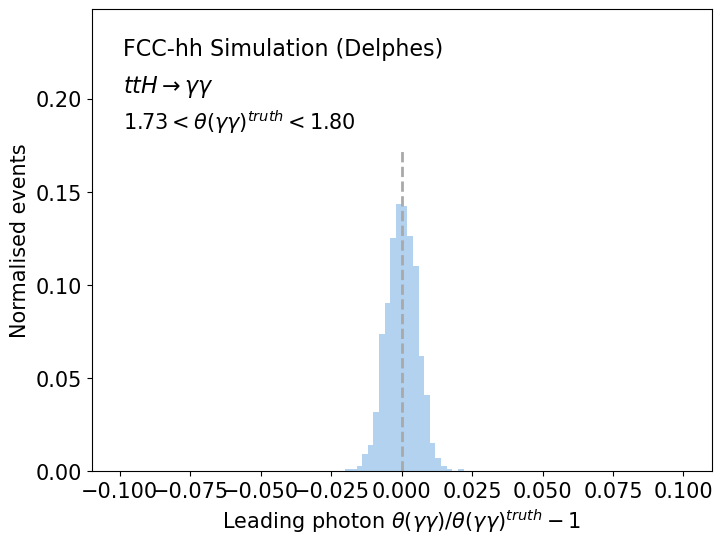

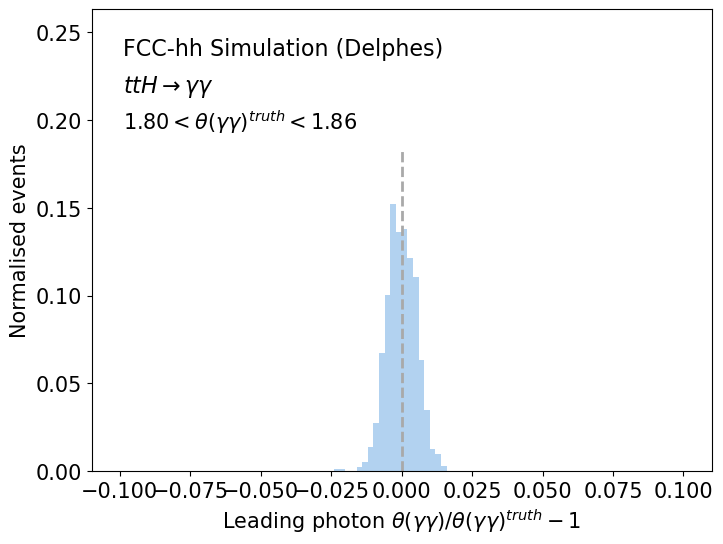

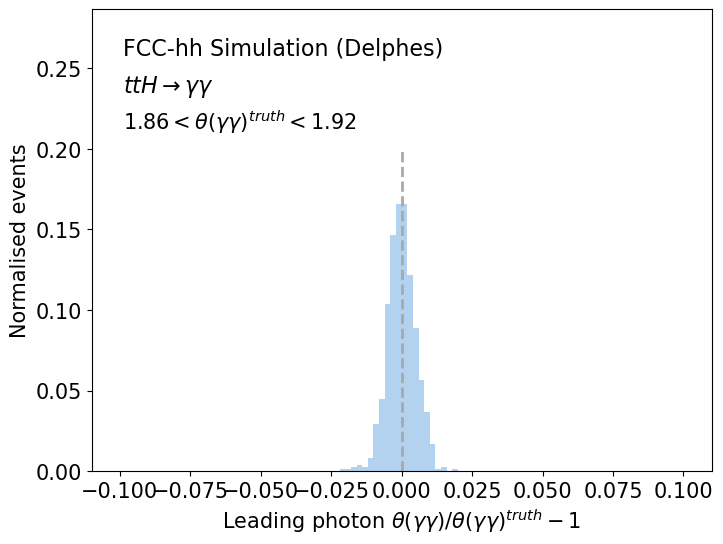

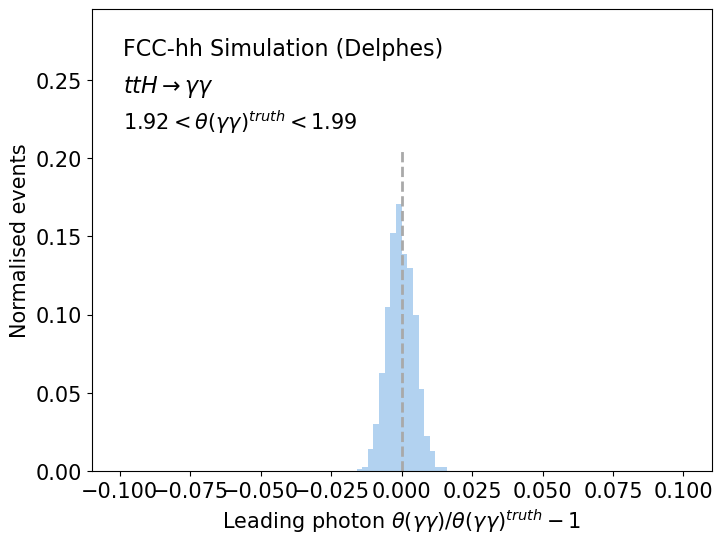

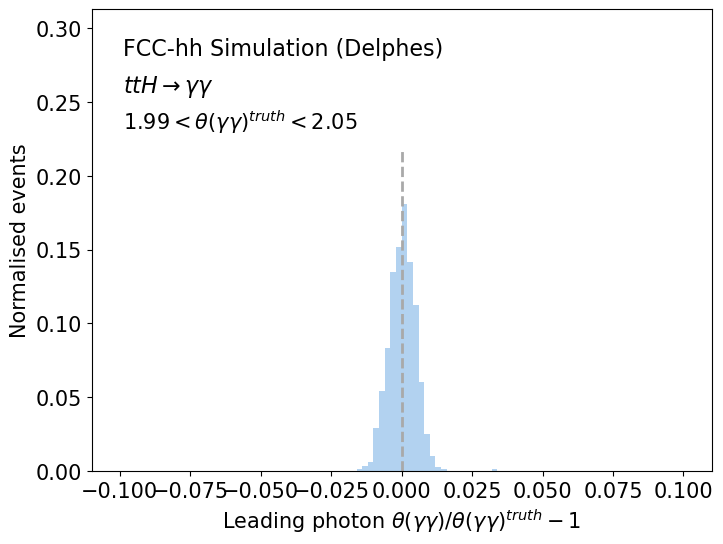

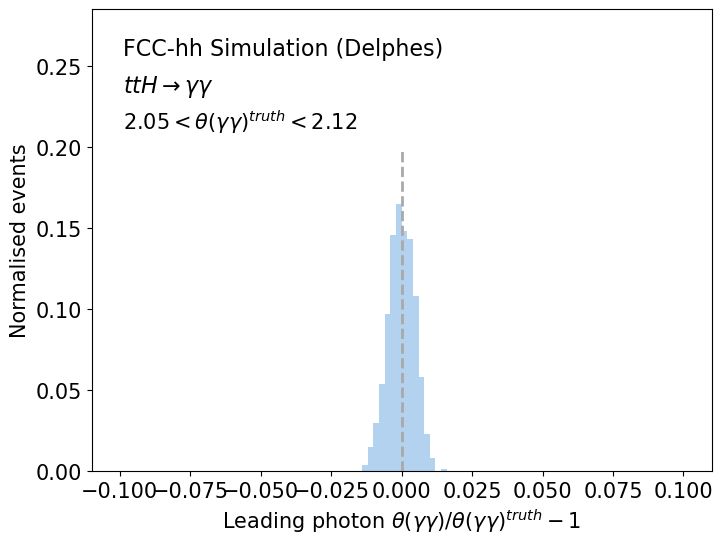

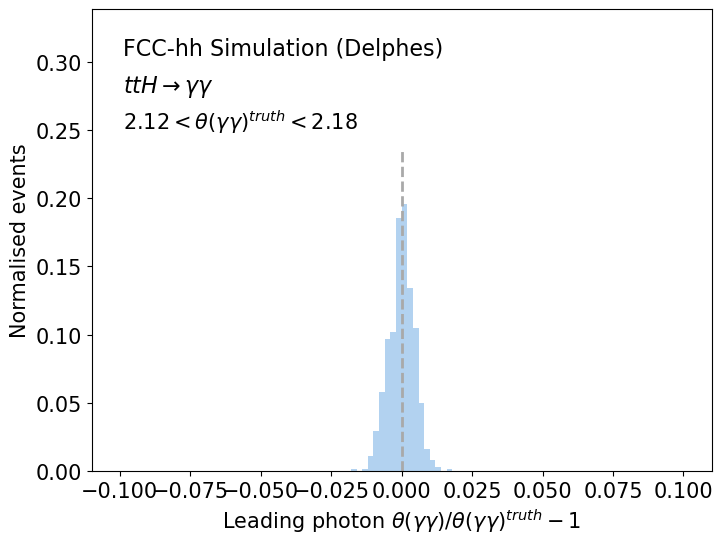

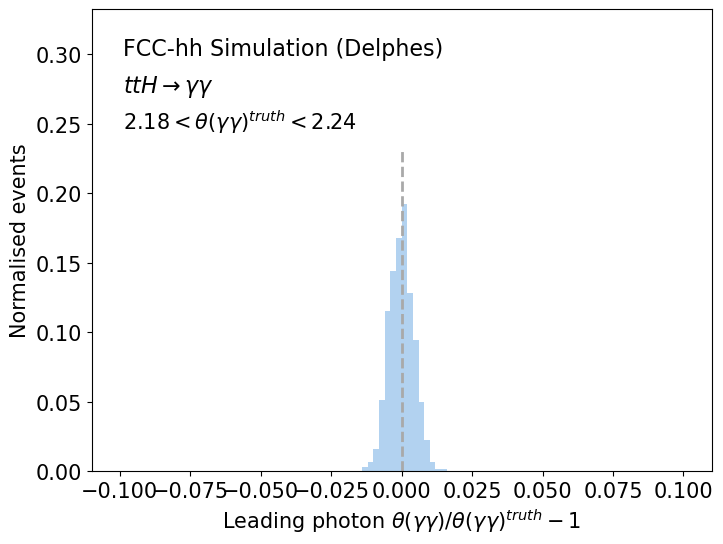

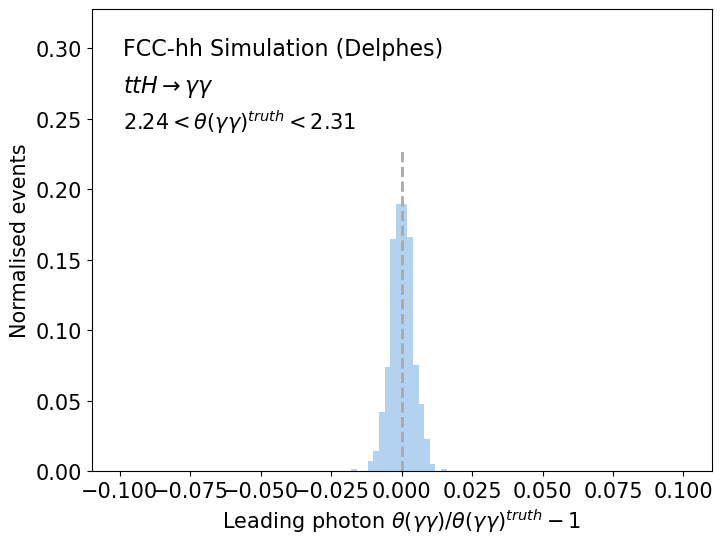

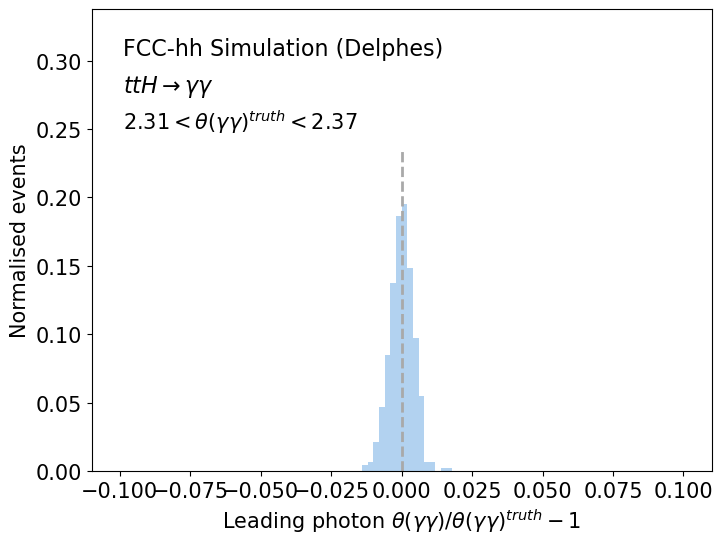

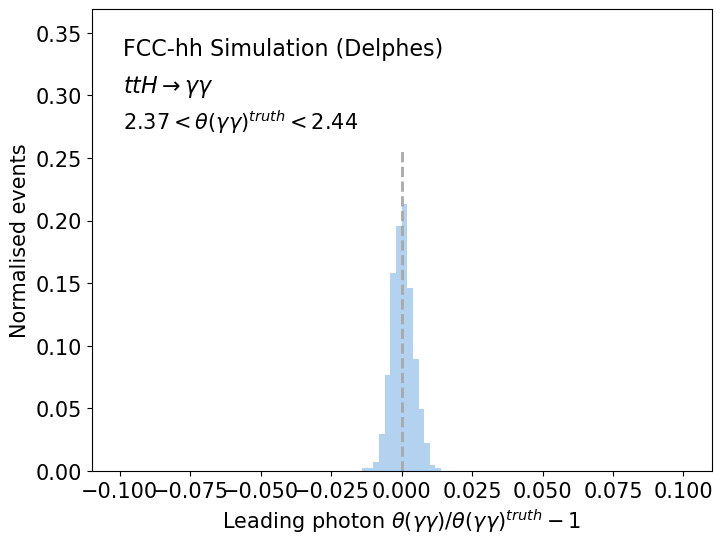

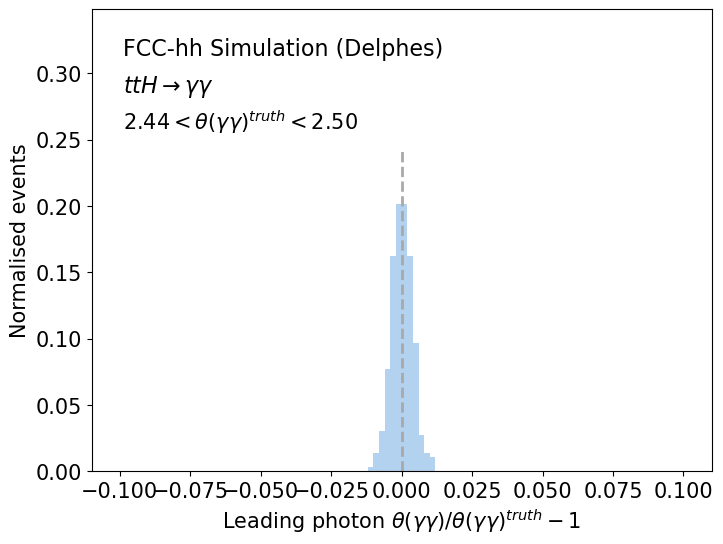

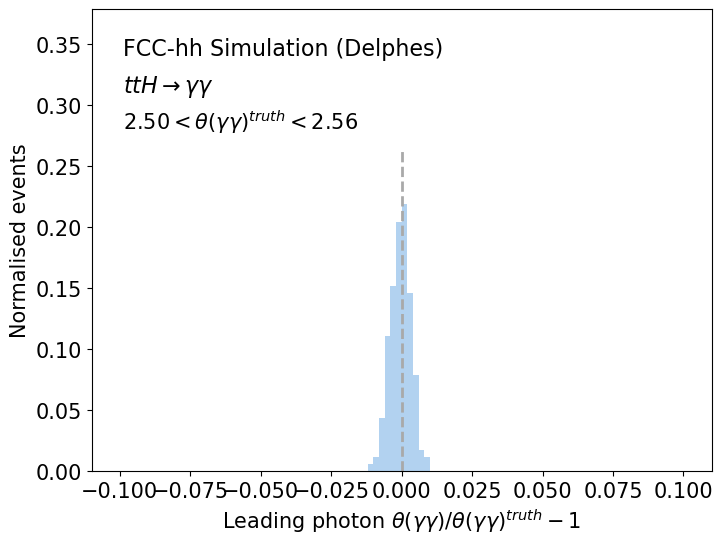

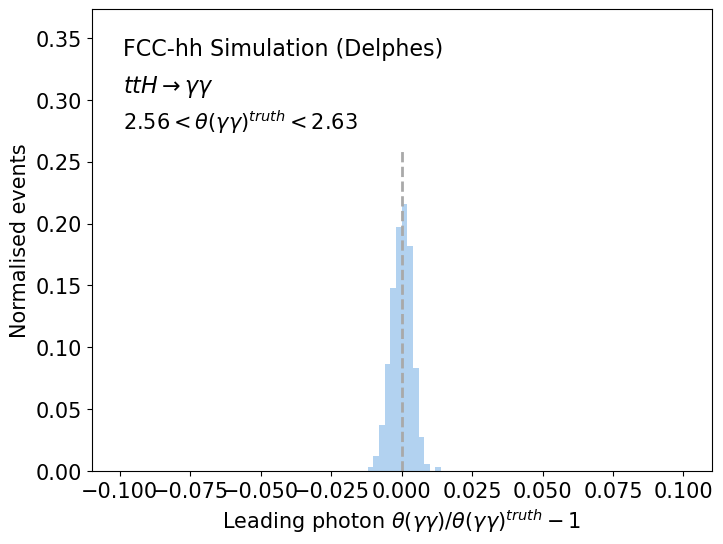

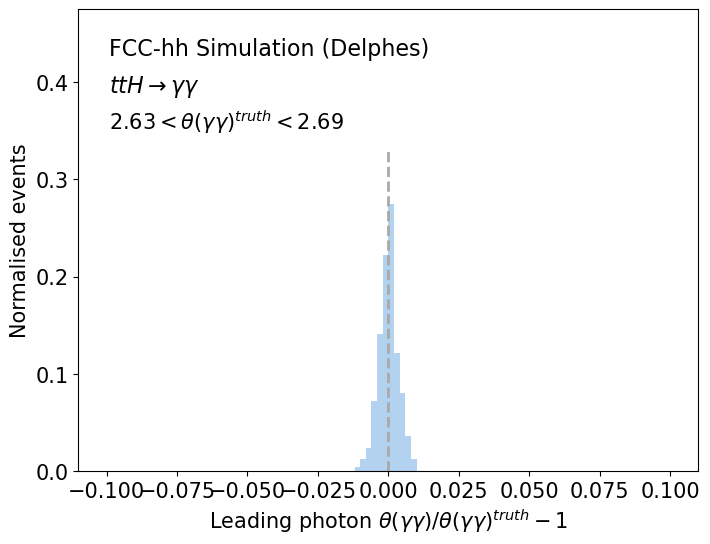

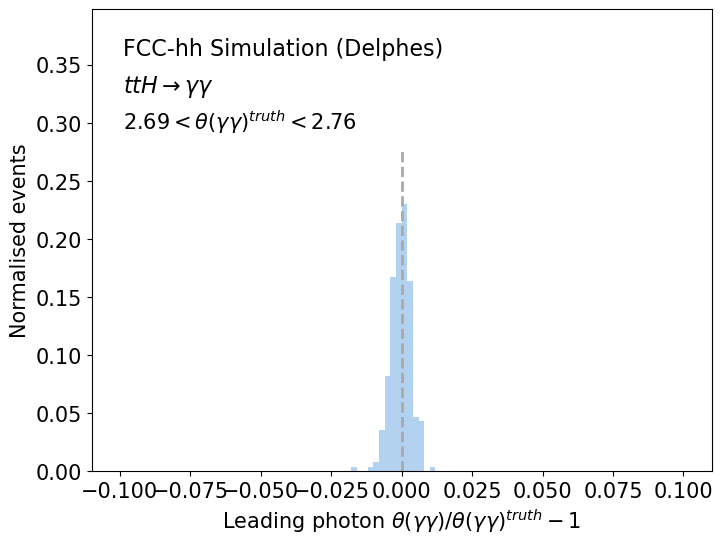

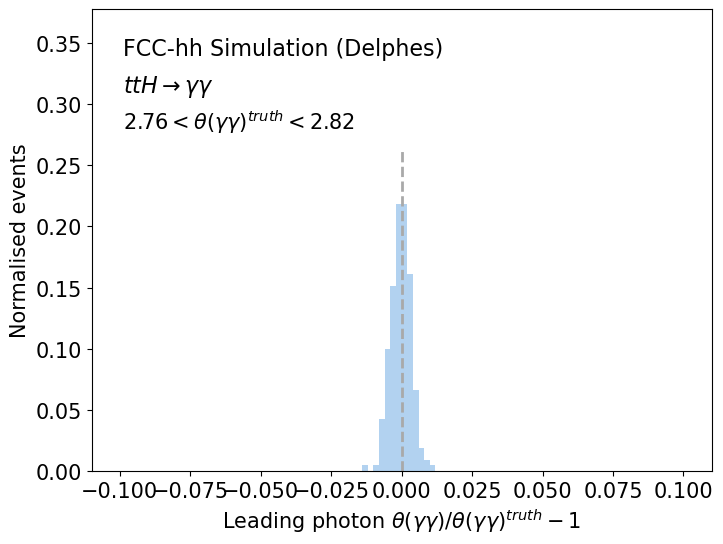

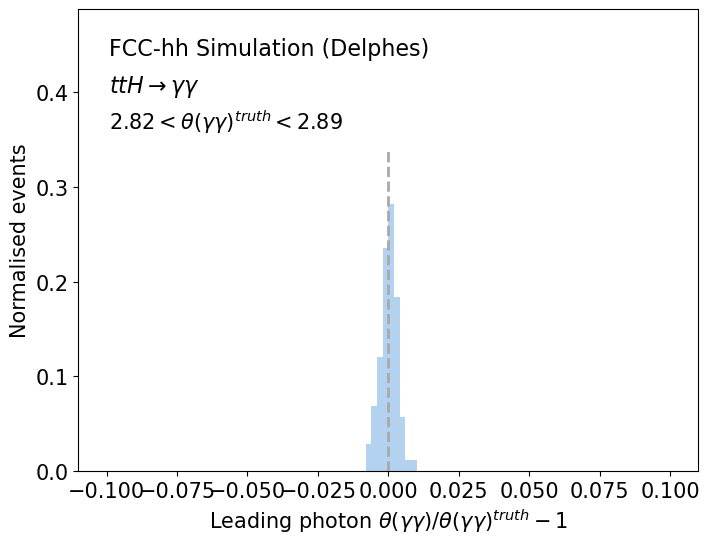

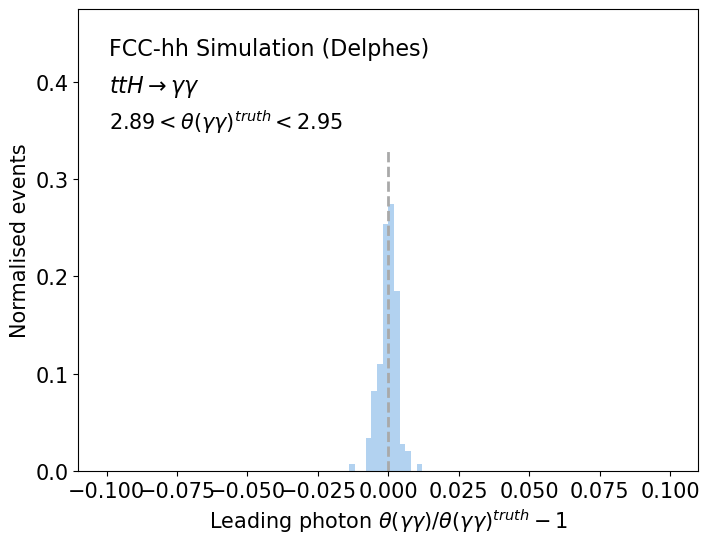

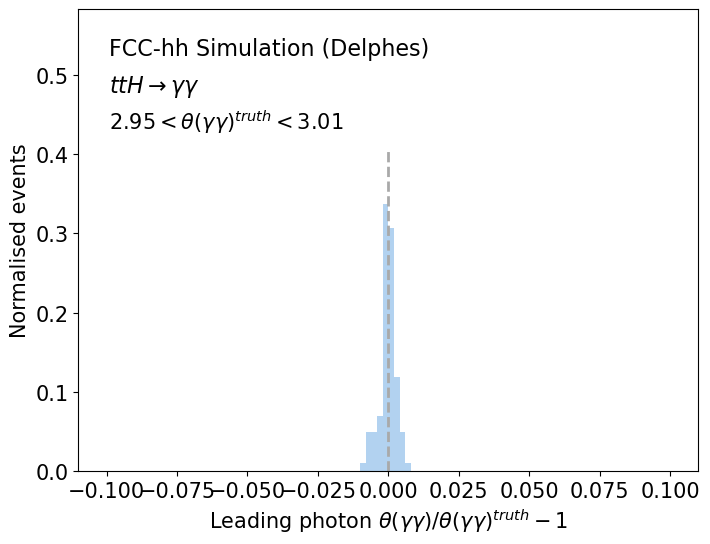

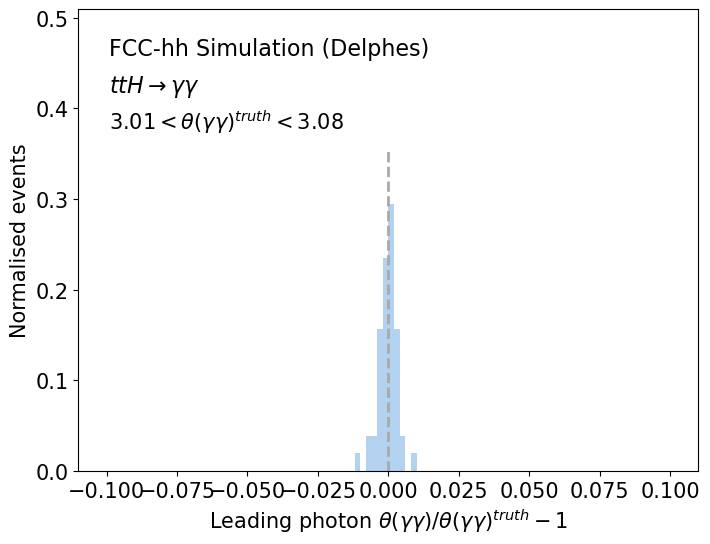

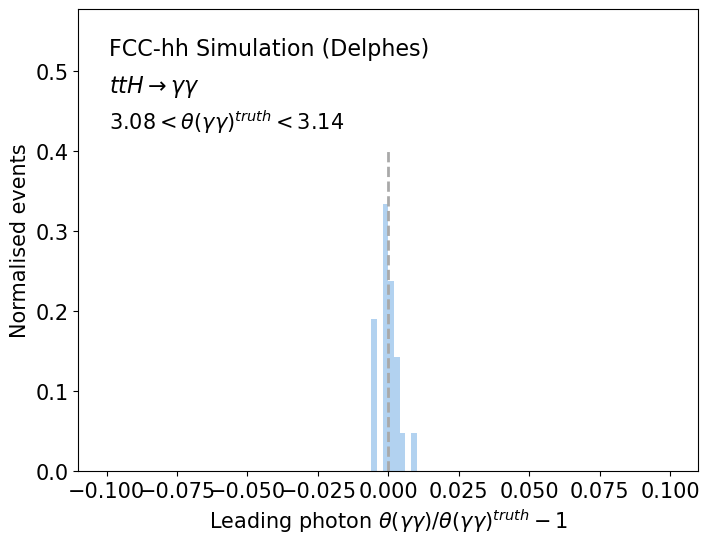

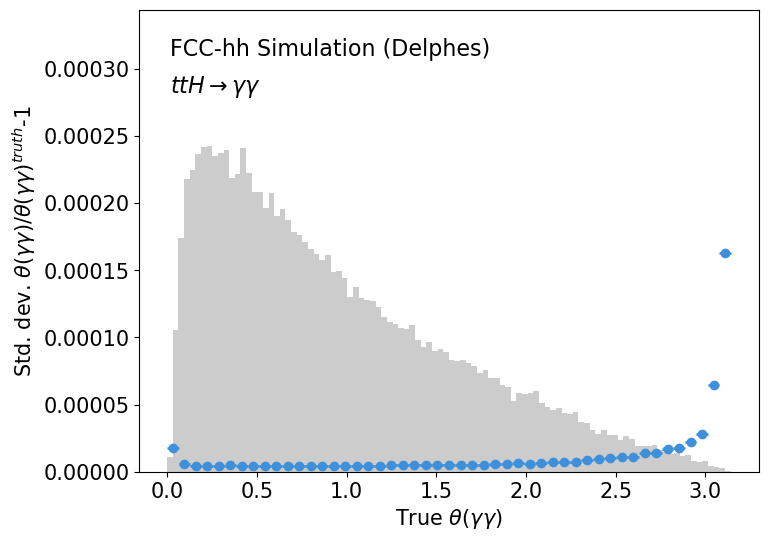

In [62]:
y = np.zeros(len(ANGLE_BINS)-1)
for jbin in range(1, len(ANGLE_BINS)) :
    j_low = "%.2f" % ANGLE_BINS[jbin-1]
    j_up = "%.2f" % ANGLE_BINS[jbin] 
        
    df_all = df1[df1['angle_bin']==jbin]
    observable = df_all['theta_y_y']/df_all['true_theta_y_y']-np.ones(len(df_all))
    resolution = np.std(observable)/(len(df_all)-1)
    y[jbin-1] = resolution
        
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(8,6)
    )
    ax.hist(observable, weights=df_all['weight']/df_all['weight'].sum(),
                bins=100, range=(-0.1,0.1), histtype='stepfilled', color=color_sequence[0], alpha=0.4)
    ax.axvline(0, ymin=0, ymax=0.7, color='darkgrey', ls='--', lw=2.)

    ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.82, process_label, transform=ax.transAxes, fontsize=16)
    ax.text(0.05, 0.74, str(j_low)+r"$<\theta(\gamma\gamma)^{truth}<$"+str(j_up), transform=ax.transAxes, fontsize=15)
    xlabel = r"Leading photon $\theta(\gamma\gamma)/\theta(\gamma\gamma)^{truth}-1$"
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'Normalised events')

    ymin,ymax = ax.get_ylim() 
    ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.65)
    
    plotname = "thetareco_over_thetatrue_angle_bin_"+str(jbin)
    plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
    plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
    plt.show()        

fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

ax.errorbar(x, y, xerr=xerr, color=color_sequence[0], marker='o', lw=2, ls='none')
ax.hist(df1['true_theta_y_y'], weights=df1['weight']/df1['weight'].sum()*1e-2, 
        bins=100, range=(0,3.14), histtype='stepfilled', color='grey', alpha=0.4)
        
ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, process_label, transform=ax.transAxes, fontsize=16)
xlabel = r"True $\theta(\gamma\gamma)$"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Std. dev. $\theta(\gamma\gamma)/\theta(\gamma\gamma)^{truth}$-1')

ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.35)
    
plotname = "thetareco_over_thetatrue_angle_bin"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()   

In [89]:
ANGLE_BINS = np.linspace(-1, 1, 41)
x = 0.5*(ANGLE_BINS[:-1] + ANGLE_BINS[1:])
xerr = 0.5*(ANGLE_BINS[1:] - ANGLE_BINS[:-1])

df1 = df[process_key][sel_key].copy()

df1['angle_bin'] = np.digitize(df1['true_cos_theta_y_y'], ANGLE_BINS)

In [88]:
df1['true_cos_theta_y_y'].min()

-0.9999732979201492

<Axes: >

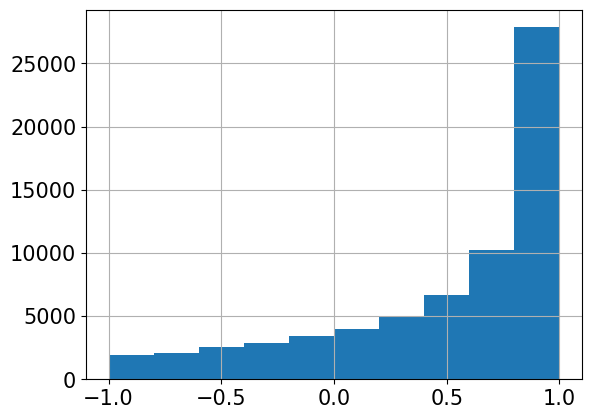

In [94]:
df1['true_cos_theta_y_y'].hist()

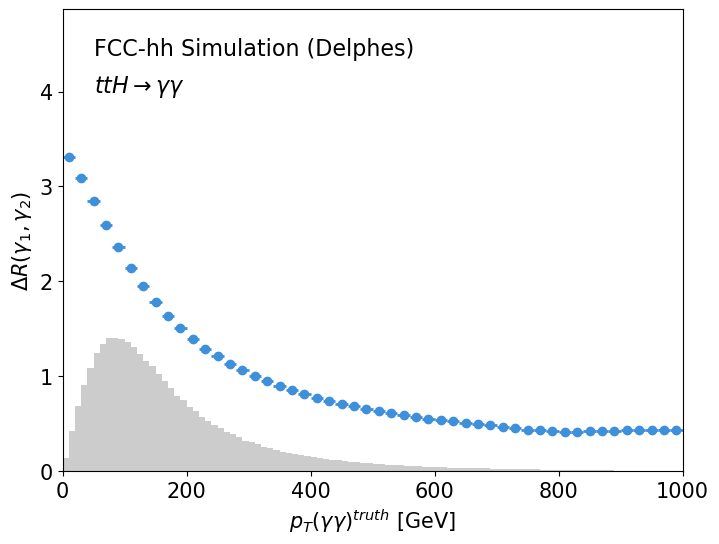

In [12]:
df1 = df['ttHyy']['nocuts'].copy()
PT_BINS = np.linspace(0, 1000., 51)
df1['pT_bin'] = np.digitize(np.abs(df1['true_pT_yy']), PT_BINS)

x = 0.5*(PT_BINS[:-1] + PT_BINS[1:])
xerr = 0.5*(PT_BINS[1:] - PT_BINS[:-1])
y = np.zeros(len(PT_BINS)-1)
yerr = np.zeros(len(PT_BINS)-1)

for ibin in range(1, len(PT_BINS)) :
    i_low = PT_BINS[ibin-1]
    i_up = PT_BINS[ibin]
        
    df_all = df1[df1['pT_bin']==ibin]
    observable = df_all['DR_y_y']
    mean = np.mean(observable)
    error = np.std(observable)/(len(df_all)-1)
    y[ibin-1] = mean
    yerr[ibin-1] = error
    
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)
ax.errorbar(x, y, xerr=xerr, yerr=yerr, color=color_sequence[0], ls='none', lw=2, marker='o')
ax.hist(df1['true_pT_yy'], weights=df1["weight"]/df1["weight"].sum()*30,
        bins=100, range=(0,1000), histtype='stepfilled', color='grey', alpha=0.4)

ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, r"$ttH\rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=16)
xlabel = "$p_T (\gamma\gamma)^{truth}$ [GeV]"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'$\Delta R(\gamma_1, \gamma_2)$')

ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs(ymax-ymin)*0.4)
ax.set_xlim(PT_BINS[0], PT_BINS[-1])

    
plotname = "DR_y_y_as_a_function_of_true_pT_yy"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show() 